## Notebook Description: Análisis de Aditivos Alimenticios y sus Efectos en la Digestibilidad, Producción de Metano y Amonio.

<p align="justify">
Este cuaderno de Colab tiene como objetivo principal evaluar el impacto de diferentes tratamientos experimentales (aditivos alimenticios) en la digestibilidad de la materia seca verdadera (TDDM, por sus siglas en inglés), la intensidad de metano (CH$_4$), la concentración de amonio (NH$_4^+$) y el pH en un sistema de fermentación. Para ello, se carga un conjunto de datos experimental y se preprocessa, ordenando los tratamientos. La metodología central incluye la definición de una función personalizada en R que realiza análisis estadísticos univariados (ANOVA) para cada variable de interés en función del tratamiento. Esta función incorpora pruebas de normalidad (Shapiro-Wilk), homogeneidad de varianzas (Bartlett) y comparaciones múltiples post-hoc (Tukey HSD), además de generar visualizaciones mediante diagramas de caja con indicación de los grupos estadísticamente diferentes. El análisis se estructura en la evaluación de cuatro lotes (batches) experimentales. Los resultados principales incluyen los valores F y p de las pruebas ANOVA, los resultados de las pruebas de supuestos, los grupos de significancia de Tukey y las representaciones gráficas que permiten identificar los efectos significativos de los aditivos en las variables estudiadas. Finalmente, se presentan tablas con los promedios de las variables clave por tratamiento para cada lote, consolidando los hallazgos experimentales.
</p>

### Tratamientos experimentales

Tratamientos experimentales utilizados para evaluar aditivos alimenticios comerciales bajo diferentes estrategias de inclusión del aditivo.

| Grupo | Tto | Sustrato / Aditivo | Forraje (%) | Forraje (mg) | Concentrado (%) | Concentrado (mg) | Aditivo (cantidad o volumen por jeringa) | Comentario |
|---|---|---|---:|---:|---:|---:|---|---|
| **1 - Controles** | T0 | Premezcla balanceado Control | 0 | 0 | 100 | 500 | N/A | Premezcla Balanceado Control sin aditivo |
| **1 - Controles** | T1 | Pasto kikuyo | 100 | 500 | 0 | 0 | N/A | **Forraje solo** – Control |
| **1 - Controles** | T2 | Pasto kikuyo (70%) + Premezcla Balanceado Control (30%) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada 70:30 forraje:concentrado (Control) |
| **2 - Premezcla con el Aditivo** | T3 | Agolin (Premezcla B) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada**. Usar premezcla preparada en el laboratorio: 75 mg de premezcla control balanceada sin aditivo + 75 mg de premezcla con el respectivo aditivo |
| **2 - Premezcla con el Aditivo** | T4 | Bovaer 10 (Premezcla C) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T5 | Fator P (Premezcla D) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T6 | Anavrin (Premezcla E) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T7 | Monotec 200 (Premezcla F) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T8 | Nutreset (Premezcla G) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T9 | Bovaer 10 + Monotec 200 (Premezcla H) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T10 | Agolin (Premezcla B) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×**. Usar premezcla respectiva a cada aditivo, preparada por Grupo Bios |
| **2 - Premezcla con el Aditivo** | T11 | Bovaer 10 (Premezcla C) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T12 | Fator P (Premezcla D) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T13 | Anavrin (Premezcla E) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T14 | Monotec 200 (Premezcla F) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T15 | Nutreset (Premezcla G) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T16 | Bovaer 10 + Monotec 200 (Premezcla H) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T17 | Pasto + Premezcla Balanceado Control + Agolin | 70 | 350 | 30 | 150 | 0.03 mg | Premezcla Balanceado Control sin aditivo. Adicionar el aditivo directamente en la jeringa a **1× o dosis recomendada** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T18 | Pasto + Premezcla Balanceado Control + Bovaer 10 | 70 | 350 | 30 | 150 | 0.375 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T19 | Pasto + Premezcla Balanceado Control + Fator P | 70 | 350 | 30 | 150 | 0.150 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T20 | Pasto + Premezcla Balanceado Control + Anavrin | 70 | 350 | 30 | 150 | 0.075 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T21 | Pasto + Premezcla Balanceado Control + Monotec 200 | 70 | 350 | 30 | 150 | 0.080 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T22 | Pasto + Premezcla Balanceado Control + Nutreset | 70 | 350 | 30 | 150 | 0.750 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T23 | Pasto + Premezcla Balanceado Control + Bovaer 10 + Monotec 200 | 70 | 350 | 30 | 150 | 0.375 mg Bovaer + 0.080 mg Monotec | Aditivos directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T24 | Pasto + Premezcla Balanceado Control + TN-A | 70 | 350 | 30 | 150 | 25 µL | Aditivo líquido directamente en la jeringa |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T25 | Pasto + Premezcla Balanceado Control + TN-B | 70 | 350 | 30 | 150 | 10 µL | Aditivo líquido directamente en la jeringa |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T26 | Pasto + Premezcla Balanceado Control + Agolin | 70 | 350 | 30 | 150 | 0.06 mg | Premezcla Balanceado Control sin aditivo. Adicionar el aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T27 | Pasto + Premezcla Balanceado Control + Bovaer 10 | 70 | 350 | 30 | 150 | 0.75 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T28 | Pasto + Premezcla Balanceado Control + Fator P | 70 | 350 | 30 | 150 | 0.30 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T29 | Pasto + Premezcla Balanceado Control + Anavrin | 70 | 350 | 30 | 150 | 0.15 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T30 | Pasto + Premezcla Balanceado Control + Monotec 200 | 70 | 350 | 30 | 150 | 0.16 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T31 | Pasto + Premezcla Balanceado Control + Nutreset | 70 | 350 | 30 | 150 | 1.5 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T32 | Pasto + Premezcla Balanceado Control + Bovaer 10 + Monotec 200 | 70 | 350 | 30 | 150 | 0.75 mg Bovaer + 0.16 mg Monotec | Aditivos directamente en la jeringa a **2×** |
| **Controles adicionales** | T33 | Pasto + Premezcla Balanceado Control + Alga Roja | — | — | — | — | 5.0 | El aditivo se agrega a la premezcla en **1%** |
| **Controles adicionales** | T34 | Pasto + Premezcla Balanceado Control + Alga Roja | — | — | — | — | 7.5 | El aditivo se agrega a la premezcla en **1.5%** |
| **Controles adicionales** | T35 | Pasto + Premezcla Balanceado Control + Alga Roja | — | — | — | — | 10 | El aditivo se agrega a la premezcla en **2%** |

**Nota:** Triple no se incluyó en la premezcla porque es una emulsión líquida con compuestos volátiles. Se evaluará directamente en la jeringa en dos concentraciones: **TN-A: 25 µL/jeringa** y **TN-B: 10 µL/jeringa**.

# 1.0 Install packages and import libraries

In [262]:
install.packages(c("dplyr", "ggplot2", "emmeans","agricolae", "lme4","lmerTest","pbkrtest", "multcomp", "car", "multcompView"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [267]:
library(ggplot2)
library(dplyr)
library(agricolae)
library(tibble)
library(pbkrtest)
library(multcomp)
library(lme4)
library(lmerTest)
library(emmeans)
library(scales)

# 2.0 Data load

In [270]:
url_df <- "https://raw.githubusercontent.com/maurope/lmf/main/data/2026_09_11_R_bios_diets_anaylisis_for_alejandra/Additives_Bios_AM.csv"
df <- read.csv(url_df)

In [271]:
head(df)

,X.,Treatment,Additive,Batch,Run,Replication,Syrange_No,Sample_weight_g,DM_Incubated_mg,Digested_feed_mg,⋯,CH4_percentage_in_gas_8h,CH4_percentage_in_gas_24h,CH4_ml_g_DM_incubated_24h,CH4_ml_g_DMD_24h,CH4_g_g_DM_incubated_24h,CH4_g_g_DMD_24h,pH,NH4_ppm,BLANK_24H_promedio_corrida_ppm,Amonio_corregido_ppm
,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,T0,CTRL_PREM,95,1,1,3,0.5006,447.1,359.9,⋯,14.8,15.0,42.3,52.6,23.5,29.2,7.39,360.7,419.25,-58.55
2,2,T0,CTRL_PREM,95,1,2,4,0.5001,446.6,370.8,⋯,15.9,15.6,46.2,55.7,25.7,30.9,7.29,455.1,419.25,35.85
3,3,T0,CTRL_PREM,95,1,3,5,0.5002,446.7,351.8,⋯,16.0,15.9,42.3,53.7,23.5,29.8,7.21,404.6,419.25,-14.65
4,4,T0,CTRL_PREM,96,2,1,3,0.5003,446.8,330.8,⋯,15.3,15.7,43.5,58.8,24.2,32.6,7.57,357.6,363.40,-5.80
5,5,T0,CTRL_PREM,96,2,2,4,0.5000,446.6,350.9,⋯,16.4,16.0,44.9,57.2,24.9,31.7,7.40,292.2,363.40,-71.20
6,6,T0,CTRL_PREM,96,2,3,5,0.5001,446.6,351.1,⋯,16.4,16.1,44.9,57.1,24.9,31.7,7.43,359.6,363.40,-3.80


In [272]:
df$Treatment <- factor(
  df$Treatment,
  levels = paste0("T", sort(as.numeric(gsub("T", "", unique(df$Treatment)))))
) # Sorting treatments numerically for ordered visualization in box plots

df <- df[order(df$Treatment), ]

# 3.0 Summary

In [273]:
nrow(df)  # number of rows
ncol(df)  # number of columns

[1] 333

[1] 24

In [274]:
names(df) # Columns names

[1] "X."                             "Treatment"                     
 [3] "Additive"                       "Batch"                         
 [5] "Run"                            "Replication"                   
 [7] "Syrange_No"                     "Sample_weight_g"               
 [9] "DM_Incubated_mg"                "Digested_feed_mg"              
[11] "CH4_24h_ml"                     "Gas_ml_g_DM_Incubated_24h"     
[13] "TDDM_percentage"                "Part_Fact"                     
[15] "CH4_percentage_in_gas_8h"       "CH4_percentage_in_gas_24h"     
[17] "CH4_ml_g_DM_incubated_24h"      "CH4_ml_g_DMD_24h"              
[19] "CH4_g_g_DM_incubated_24h"       "CH4_g_g_DMD_24h"               
[21] "pH"                             "NH4_ppm"                       
[23] "BLANK_24H_promedio_corrida_ppm" "Amonio_corregido_ppm"

In [275]:
glimpse(df)

Rows: 333
Columns: 24
$ X.                             <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, …
$ Treatment                      <fct> T0, T0, T0, T0, T0, T0, T0, T0, T0, T1,…
$ Additive                       <chr> "CTRL_PREM", "CTRL_PREM", "CTRL_PREM", …
$ Batch                          <int> 95, 95, 95, 96, 96, 96, 97, 97, 97, 95,…
$ Run                            <int> 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, …
$ Replication                    <int> 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, …
$ Syrange_No                     <int> 3, 4, 5, 3, 4, 5, 3, 4, 5, 6, 7, 8, 6, …
$ Sample_weight_g                <dbl> 0.5006, 0.5001, 0.5002, 0.5003, 0.5000,…
$ DM_Incubated_mg                <dbl> 447.1, 446.6, 446.7, 446.8, 446.6, 446.…
$ Digested_feed_mg               <dbl> 359.9, 370.8, 351.8, 330.8, 350.9, 351.…
$ CH4_24h_ml                     <dbl> 18.9, 20.7, 18.9, 19.5, 20.1, 20.1, 19.…
$ Gas_ml_g_DM_Incubated_24h      <dbl> 282.7, 296.4, 266.2, 277.8, 281.3, 279.…
$ TDDM_percentage 

### Descripción de las variables

La siguiente tabla describe las variables incluidas en el conjunto de datos experimental. El conjunto contiene **333 observaciones y 24 variables**, correspondientes a la identificación experimental, tratamientos, condiciones de incubación, producción de gases, digestibilidad y variables químicas.

| Variable | Tipo de dato | Descripción |
|---|---|---|
| **X** | Integer | Identificador numérico de la observación o registro dentro del conjunto de datos. |
| **Treatment** | Factor | Identificador del tratamiento experimental aplicado (T0–T35). |
| **Additive** | Character | Código del aditivo o condición experimental utilizada en cada tratamiento. |
| **Batch** | Integer | Identificador del lote experimental o batch en el que se realizó la medición. |
| **Run** | Integer | Identificador de la corrida experimental dentro del batch. |
| **Replication** | Integer | Número de réplica experimental dentro de cada corrida. |
| **Syrange_No** | Integer | Número o identificador de la jeringa utilizada para la incubación. |
| **Sample_weight_g** | Double | Peso de la muestra de alimento utilizada para el análisis, expresado en gramos (g). |
| **DM_Incubated_mg** | Double | Cantidad de materia seca (DM, dry matter) incubada, expresada en miligramos (mg). |
| **Digested_feed_mg** | Double | Cantidad de alimento digerido durante la incubación, expresada en miligramos (mg). |
| **CH4_24h_ml** | Double | Volumen de metano (CH₄) producido durante 24 horas de incubación, expresado en mililitros (mL). |
| **Gas_ml_g_DM_Incubated_24h** | Double | Producción de gas total durante 24 horas, normalizada por gramo de materia seca incubada (mL/g DM). |
| **TDDM_percentage** | Double | Digestibilidad verdadera de la materia seca (TDDM, true dry matter digestibility), expresada como porcentaje (%). |
| **Part_Fact** | Double | Factor de partición (partitioning factor), utilizado para relacionar la materia seca digerida con la producción de gas durante la fermentación. |
| **CH4_percentage_in_gas_8h** | Double | Proporción de metano (CH₄) en el gas producido después de 8 horas de incubación, expresada como porcentaje (%). |
| **CH4_percentage_in_gas_24h** | Double | Proporción de metano (CH₄) en el gas producido después de 24 horas de incubación, expresada como porcentaje (%). |
| **CH4_ml_g_DM_incubated_24h** | Double | Producción de metano durante 24 horas normalizada por gramo de materia seca incubada (mL CH₄/g DM incubada). |
| **CH4_ml_g_DMD_24h** | Double | Producción de metano durante 24 horas normalizada por gramo de materia seca digerida (mL CH₄/g DMD). |
| **CH4_g_g_DM_incubated_24h** | Double | Producción de metano durante 24 horas expresada en gramos de CH₄ por gramo de materia seca incubada (g CH₄/g DM incubada). |
| **CH4_g_g_DMD_24h** | Double | Producción de metano durante 24 horas expresada en gramos de CH₄ por gramo de materia seca digerida (g CH₄/g DMD). |
| **pH** | Double | Valor de pH medido en el medio de incubación al finalizar el periodo experimental. |
| **NH4_ppm** | Double | Concentración de amonio (NH₄⁺) medida en la muestra, expresada en partes por millón (ppm). |
| **BLANK_24H_promedio_corrida_ppm** | Double | Concentración promedio de amonio correspondiente al blanco de 24 horas de la corrida experimental, expresada en ppm. |
| **Amonio_corregido_ppm** | Double | Concentración de amonio corregida respecto al valor promedio del blanco de la correspondiente corrida, expresada en ppm. |

**Tipos de datos utilizados:**

- **Integer:** valores numéricos enteros utilizados principalmente para identificadores y réplicas.
- **Factor:** variable categórica con niveles definidos, como los tratamientos experimentales.
- **Character:** variable de texto utilizada para códigos o identificadores.
- **Double:** variable numérica continua utilizada para las mediciones experimentales.

# 4.0 Batch assignment

In [578]:
list_batch_1  <- c("T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9", "T10", "T11", "T12", "T13", "T14", "T15", "T16")
batch_1 <- df %>% dplyr::filter(Treatment %in% list_batch_1)
batch_1$Treatment <- factor(batch_1$Treatment, levels = list_batch_1)


list_batch_2  <- c("T2", "T17", "T18", "T19", "T20", "T21", "T22", "T23", "T24", "T25", "T26", "T27", "T28", "T29", "T30", "T31", "T32")
batch_2 <- df %>% dplyr::filter(Treatment %in% list_batch_2)
batch_2$Treatment <- factor(batch_2$Treatment, levels = list_batch_2)

list_batch_3  <- c("T2", "T17", "T18", "T19", "T20", "T21", "T22", "T23", "T24", "T25")
batch_3 <- df %>% dplyr::filter(Treatment %in% list_batch_3)
batch_3$Treatment <- factor(batch_3$Treatment, levels = list_batch_3)

list_batch_4  <- c("T2", "T26", "T27", "T28", "T29", "T30", "T31", "T32")
batch_4 <- df %>% dplyr::filter(Treatment %in% list_batch_4)
batch_4$Treatment <- factor(batch_4$Treatment, levels = list_batch_4)

# 5.0  Data Analysis

### 5.0.1 FUNCTION CREATION

In [2338]:
plot_anova_treatment <- function(
    data,
    variable,
    title = NULL,
    y_label = NULL,
    save_path = NULL,   # output file path, e.g. "boxplot.png" (NULL = don't save)
    plot_width = 16,     # width in inches
    plot_height = 8,     # height in inches
    plot_dpi = 300       # resolution
) {

  # ----------------------------------------------------------
  # 1. Check required packages
  # ----------------------------------------------------------

  required_packages <- c(
    "lme4",
    "lmerTest",
    "multcompView",  # needed for cld() to compute the letters
    "multcomp",      # multcomp BEFORE emmeans (load order matters for cld())
    "emmeans",
    "dplyr",
    "ggplot2",
    "scales",
    "car"            # needed for the homogeneity of variance test (Levene)
  )

  missing_packages <- required_packages[
    !sapply(required_packages, requireNamespace, quietly = TRUE)
  ]

  if (length(missing_packages) > 0) {
    stop(
      paste(
        "Missing packages:",
        paste(missing_packages, collapse = ", "),
        "\nInstall them with install.packages()."
      )
    )
  }

  suppressMessages({
    library(multcompView)
    library(multcomp)
    library(emmeans)
  })


  # ----------------------------------------------------------
  # 2. Create formula
  # ----------------------------------------------------------

  formula_model <- as.formula(
    paste(variable, "~ Treatment + (1 | Batch)")
  )


  # ----------------------------------------------------------
  # 3. Mixed model
  # ----------------------------------------------------------

  model <- lmerTest::lmer(
    formula_model,
    data = data,
    REML = TRUE
  )


  # ----------------------------------------------------------
  # 4. ANOVA - Satterthwaite
  # ----------------------------------------------------------

  anova_result <- anova(
    model,
    ddf = "Satterthwaite"
  )


  # ----------------------------------------------------------
  # 5. F value and p-value
  # ----------------------------------------------------------

  F_value <- anova_result$`F value`[1]

  p_value <- anova_result$`Pr(>F)`[1]


  # ----------------------------------------------------------
  # 6. Shapiro-Wilk test
  # ----------------------------------------------------------

  shapiro_result <- shapiro.test(
    residuals(model)
  )


  # ----------------------------------------------------------
  # 6.1 Homogeneity of variances (Levene)
  # ----------------------------------------------------------

  levene_formula <- as.formula(
    paste(variable, "~ Treatment")
  )

  levene_result <- car::leveneTest(
    levene_formula,
    data = data
  )


  # ----------------------------------------------------------
  # 6.2 Random effect significance test (likelihood ratio test)
  # ----------------------------------------------------------

  ranova_result <- lmerTest::ranova(model)


  # ----------------------------------------------------------
  # 7. Estimated marginal means
  # ----------------------------------------------------------

  emm <- emmeans::emmeans(
    model,
    ~ Treatment,
    lmer.df = "satterthwaite"
  )


  # ----------------------------------------------------------
  # 8. Tukey pairwise comparisons
  # ----------------------------------------------------------

  tukey_result <- pairs(
    emm,
    adjust = "tukey"
  )


  # ----------------------------------------------------------
  # 9. Tukey compact letter display
  # ----------------------------------------------------------

  tukey_groups <- tryCatch(
    multcomp::cld(
      emm,
      adjust = "tukey",
      Letters = letters,
      sort = FALSE
    ),
    error = function(e) {
      emmeans:::cld.emmGrid(
        emm,
        adjust = "tukey",
        Letters = letters,
        sort = FALSE
      )
    }
  )


  # ----------------------------------------------------------
  # 10. Tukey dataframe (raw mean + letter; no adjusted mean)
  # ----------------------------------------------------------

  # Raw observed mean per treatment (from the original data)
  raw_mean_vec <- tapply(
    data[[variable]],
    as.character(data$Treatment),
    mean,
    na.rm = TRUE
  )

  letters_df <- as.data.frame(tukey_groups) %>%
    dplyr::select(
      Treatment,
      emmean,
      .group
    ) %>%
    dplyr::rename(
      adj_mean = emmean,
      letter = .group
    )

  # adj_mean is kept internally (it comes from the model, it's the basis
  # of the Tukey test) but is not shown or exported in the final table,
  # only raw_mean + letter
  letters_df$raw_mean <- raw_mean_vec[as.character(letters_df$Treatment)]

  letters_df <- letters_df %>%
    dplyr::select(
      Treatment,
      raw_mean,
      adj_mean,
      letter
    )


  # ----------------------------------------------------------
  # 11. Remove spaces from Tukey letters
  # ----------------------------------------------------------

  letters_df$letter <- gsub(
    " ",
    "",
    letters_df$letter
  )


  # ----------------------------------------------------------
  # 12. Sort treatments numerically
  # ----------------------------------------------------------

  treatment_names <- unique(
    as.character(data$Treatment)
  )

  treatment_numbers <- suppressWarnings(
    as.numeric(
      sub(
        "^T",
        "",
        treatment_names
      )
    )
  )

  if (all(!is.na(treatment_numbers))) {

    treatment_order <- paste0(
      "T",
      sort(treatment_numbers)
    )

  } else {

    treatment_order <- sort(treatment_names)

  }


  # ----------------------------------------------------------
  # 13. Tukey colors
  # ----------------------------------------------------------

  all_letters <- sort(
    unique(
      unlist(
        strsplit(
          letters_df$letter,
          ""
        )
      )
    )
  )

  all_letters <- all_letters[
    all_letters != " "
  ]

  tukey_colors <- scales::hue_pal()(
    length(all_letters)
  )

  names(tukey_colors) <- all_letters


  # ----------------------------------------------------------
  # 14. Box quantiles (Q1/Q3) per treatment
  #     -> same limits drawn by geom_boxplot(), so that
  #        the color fill is clipped to ONLY inside the box
  # ----------------------------------------------------------

  box_q1 <- tapply(
    data[[variable]],
    as.character(data$Treatment),
    function(x) quantile(x, 0.25, na.rm = TRUE)
  )

  box_q3 <- tapply(
    data[[variable]],
    as.character(data$Treatment),
    function(x) quantile(x, 0.75, na.rm = TRUE)
  )


  # ----------------------------------------------------------
  # 15. Create color segments
  # ----------------------------------------------------------

  color_segments <- letters_df %>%
    dplyr::mutate(
      letters_list = strsplit(
        letter,
        ""
      )
    ) %>%
    dplyr::rowwise() %>%
    dplyr::mutate(
      n_letters = length(letters_list)
    ) %>%
    dplyr::ungroup()


  # ----------------------------------------------------------
  # 16. Add Tukey information to original data
  # ----------------------------------------------------------

  df_plot <- data %>%
    dplyr::left_join(
      letters_df %>%
        dplyr::select(
          Treatment,
          letter
        ),
      by = "Treatment"
    )


  # ----------------------------------------------------------
  # 17. Treatment factors
  # ----------------------------------------------------------

  df_plot$Treatment <- factor(
    df_plot$Treatment,
    levels = treatment_order
  )

  letters_df$Treatment <- factor(
    letters_df$Treatment,
    levels = treatment_order
  )


  # ----------------------------------------------------------
  # 18. Calculate plot limits
  # ----------------------------------------------------------

  y_max <- max(
    df_plot[[variable]],
    na.rm = TRUE
  )

  y_min <- min(
    df_plot[[variable]],
    na.rm = TRUE
  )

  y_range <- y_max - y_min

  if (y_range == 0) {
    y_range <- 1
  }


  # ----------------------------------------------------------
  # 19. Position of Tukey letters
  # ----------------------------------------------------------

  letters_df <- letters_df %>%
    dplyr::mutate(
      y_position = y_max + y_range * 0.10
    )


  # ----------------------------------------------------------
  # 20. Create color rectangles (clipped to Q1-Q3 of each box)
  # ----------------------------------------------------------

  box_width <- 0.75

  segment_data <- list()

  for (i in seq_len(nrow(color_segments))) {

    treatment <- color_segments$Treatment[i]

    letters_i <- color_segments$letters_list[[i]]

    n <- length(letters_i)

    if (n == 0) next

    segment_width <- box_width / n

    treatment_key <- as.character(treatment)
    seg_ymin <- box_q1[[treatment_key]]
    seg_ymax <- box_q3[[treatment_key]]

    for (j in seq_along(letters_i)) {

      segment_data[[length(segment_data) + 1]] <- data.frame(

        Treatment = treatment,

        xmin = as.numeric(treatment) -
          box_width / 2 +
          (j - 1) * segment_width,

        xmax = as.numeric(treatment) -
          box_width / 2 +
          j * segment_width,

        ymin = seg_ymin,

        ymax = seg_ymax,

        letter = letters_i[j],

        color = tukey_colors[letters_i[j]]
      )
    }
  }

  segment_df <- dplyr::bind_rows(
    segment_data
  )


  # ----------------------------------------------------------
  # 21. Titles
  # ----------------------------------------------------------

  if (is.null(title)) {

    title <- paste(
      variable,
      "per Treatment"
    )

  }

  if (is.null(y_label)) {

    y_label <- variable

  }


  # ----------------------------------------------------------
  # 22. Create plot
  # ----------------------------------------------------------
  options(repr.plot.width = 15, repr.plot.height = 7, repr.plot.res = 150)
  p <- ggplot(
    df_plot,
    aes(
      x = Treatment,
      y = .data[[variable]]
    )
  ) +

    geom_boxplot(
      outlier.shape = NA,
      fill = "white",
      color = "black",
      alpha = 0.75,
      na.rm = TRUE
    ) +

    geom_rect(
      data = segment_df,
      aes(
        xmin = xmin,
        xmax = xmax,
        ymin = ymin,
        ymax = ymax,
        fill = color
      ),
      inherit.aes = FALSE,
      alpha = 0.35
    ) +

    geom_boxplot(
      outlier.shape = NA,
      fill = NA,
      color = "black",
      alpha = 1,
      na.rm = TRUE
    ) +

    geom_jitter(
      width = 0.15,
      alpha = 0.5,
      color = "lightcoral",
      na.rm = TRUE
    ) +

    geom_text(
      data = letters_df,
      aes(
        x = Treatment,
        y = y_position,
        label = letter
      ),
      inherit.aes = FALSE,
      size = 6,
      fontface = "bold"
    ) +

    scale_fill_identity(
      guide = "none"
    ) +

    labs(
      title = title,
      x = "Treatment",
      y = y_label,
      caption = paste(
        "Treatments sharing at least one Tukey letter",
        "are not significantly different."
      )
    ) +

    annotate(
      "text",
      x = 0.5,
      y = y_min,
      label = paste0(
        "F = ",
        round(F_value, 2),
        "\np = ",
        format.pval(
          p_value,
          digits = 3,
          eps = 0.001
        )
      ),
      hjust = 0,
      vjust = 0,
      size = 5,
      fontface = "bold"
    ) +

    coord_cartesian(
      ylim = c(
        y_min,
        y_max + y_range * 0.20
      )
    ) +

    theme_classic() +

    theme(


      plot.title = element_text(
        size = 25,
        face = "bold",
        hjust = 0.5
      ),

      axis.title.x = element_text(
        size = 20,
        face = "bold",
        margin = margin(t = 20)
      ),

      axis.title.y = element_text(
        size = 20,
        face = "bold",
        margin = margin(r = 20)
      ),

      axis.text.x = element_text(
        size = 15
      ),

      axis.text.y = element_text(
        size = 15
      ),

      plot.caption = element_text(
        size = 13,
        hjust = 0.5
      )
    )


  # ----------------------------------------------------------
  # 22.1 Save the plot to a file (optional)
  # ----------------------------------------------------------

  if (!is.null(save_path)) {

    ggplot2::ggsave(
      filename = save_path,
      plot = p,
      width = plot_width,
      height = plot_height,
      dpi = plot_dpi
    )

    cat(
      "\nPlot saved to:",
      save_path,
      "\n"
    )

  }


  # ----------------------------------------------------------
  # 23. Print results (only the essentials, formatted for readability)
  # ----------------------------------------------------------

  cat("\n")
  cat("============================================================\n")
  cat("ANALYSIS:", title, "\n")
  cat("============================================================\n")

  # --- Full ANOVA table, organized and readable ---
  anova_clean <- data.frame(
    Effect      = rownames(anova_result),
    SumSq       = round(anova_result$`Sum Sq`, 4),
    MeanSq      = round(anova_result$`Mean Sq`, 4),
    NumDF       = round(anova_result$NumDF, 2),
    DenDF       = round(anova_result$DenDF, 2),
    F_value     = round(anova_result$`F value`, 3),
    p_value     = format.pval(anova_result$`Pr(>F)`, digits = 3, eps = 0.001),
    row.names   = NULL
  )

  cat("\n--- ANOVA (Satterthwaite) - Fixed Effects ---\n\n")
  print(anova_clean, right = FALSE)
  cat(
    ifelse(
      anova_result$`Pr(>F)`[1] > 0.05,
      "  -> Treatment effect is not significant (p > 0.05)\n",
      "  -> Treatment effect is significant (p <= 0.05)\n"
    )
  )

  # --- Random effects variance components ---
  varcorr <- as.data.frame(VarCorr(model))

  varcorr_clean <- data.frame(
    Group     = varcorr$grp,
    Variance  = round(varcorr$vcov, 4),
    Std_Dev   = round(varcorr$sdcor, 4),
    row.names = NULL
  )

  cat("\n--- RANDOM EFFECTS (Variance Components) ---\n\n")
  print(varcorr_clean, right = FALSE)

  # --- Random effect significance (likelihood ratio test) ---
  ranova_clean <- data.frame(
    Term       = rownames(ranova_result)[-1],
    LRT        = round(ranova_result$LRT[-1], 3),
    Df         = ranova_result$Df[-1],
    p_value    = format.pval(ranova_result$`Pr(>Chisq)`[-1], digits = 3, eps = 0.001),
    row.names  = NULL
  )

  cat("\n--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---\n\n")
  print(ranova_clean, right = FALSE)
  cat(
    ifelse(
      ranova_result$`Pr(>Chisq)`[-1] > 0.05,
      "  -> Random effect (Batch) is not significant (p > 0.05)\n",
      "  -> Random effect (Batch) is significant (p <= 0.05)\n"
    )
  )

  # --- Shapiro-Wilk (normality of residuals) ---
  cat("\n--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---\n\n")
  cat(
    sprintf(
      "  W = %.4f   p = %s\n",
      shapiro_result$statistic,
      format.pval(shapiro_result$p.value, digits = 3, eps = 0.001)
    )
  )
  cat(
    ifelse(
      shapiro_result$p.value > 0.05,
      "  -> Normality is not rejected (p > 0.05)\n",
      "  -> Normality is rejected (p <= 0.05)\n"
    )
  )

  # --- Homogeneity of variances (Levene) ---
  cat("\n--- HOMOGENEITY OF VARIANCES (Levene) ---\n\n")
  cat(
    sprintf(
      "  F(%d, %d) = %.4f   p = %s\n",
      levene_result$Df[1],
      levene_result$Df[2],
      levene_result$`F value`[1],
      format.pval(levene_result$`Pr(>F)`[1], digits = 3, eps = 0.001)
    )
  )
  cat(
    ifelse(
      levene_result$`Pr(>F)`[1] > 0.05,
      "  -> Homogeneity of variances is not rejected (p > 0.05)\n",
      "  -> Homogeneity of variances is rejected (p <= 0.05)\n"
    )
  )

  # --- Tukey groups (without adjusted mean) ---
  tukey_display <- letters_df %>%
    dplyr::select(
      Treatment,
      raw_mean,
      letter
    ) %>%
    dplyr::mutate(
      raw_mean = round(raw_mean, 3)
    ) %>%
    dplyr::rename(
      Mean = raw_mean,
      Tukey_Group = letter
    )

  cat("\n--- TUKEY GROUPS ---\n\n")
  print(tukey_display, row.names = FALSE)

  cat("\n============================================================\n")
  cat("--- BOXPLOT ---\n")
  cat("============================================================\n")

  print(p)


  # ----------------------------------------------------------
  # 24. Return results
  # ----------------------------------------------------------

  return(
    list(
      model = model,
      anova = anova_result,
      F_value = F_value,
      p_value = p_value,
      shapiro = shapiro_result,
      levene = levene_result,
      ranova = ranova_result,
      emmeans = emm,
      tukey = tukey_result,
      tukey_groups = letters_df,
      plot = p
    )
  )
}

## 5.1 TDDM %

### 5.1.1 Batch 1

In [2339]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: TDDM (%) per Treatment - Batch 1 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq  NumDF DenDF F_value p_value
1 Treatment 314.5837 22.4703 14    117   1.949   0.0279 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch     6.0452  2.4587 
2 Residual 11.5315  3.3958 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 32.806 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9437   p = <0.001
  -> Normality is rejected (p <= 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(14, 119) = 0.3165   p = 0.991
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 66.822           a
        T3 64.778           a
        T4 68.289           a
        T5 67.100           a
        T6 63

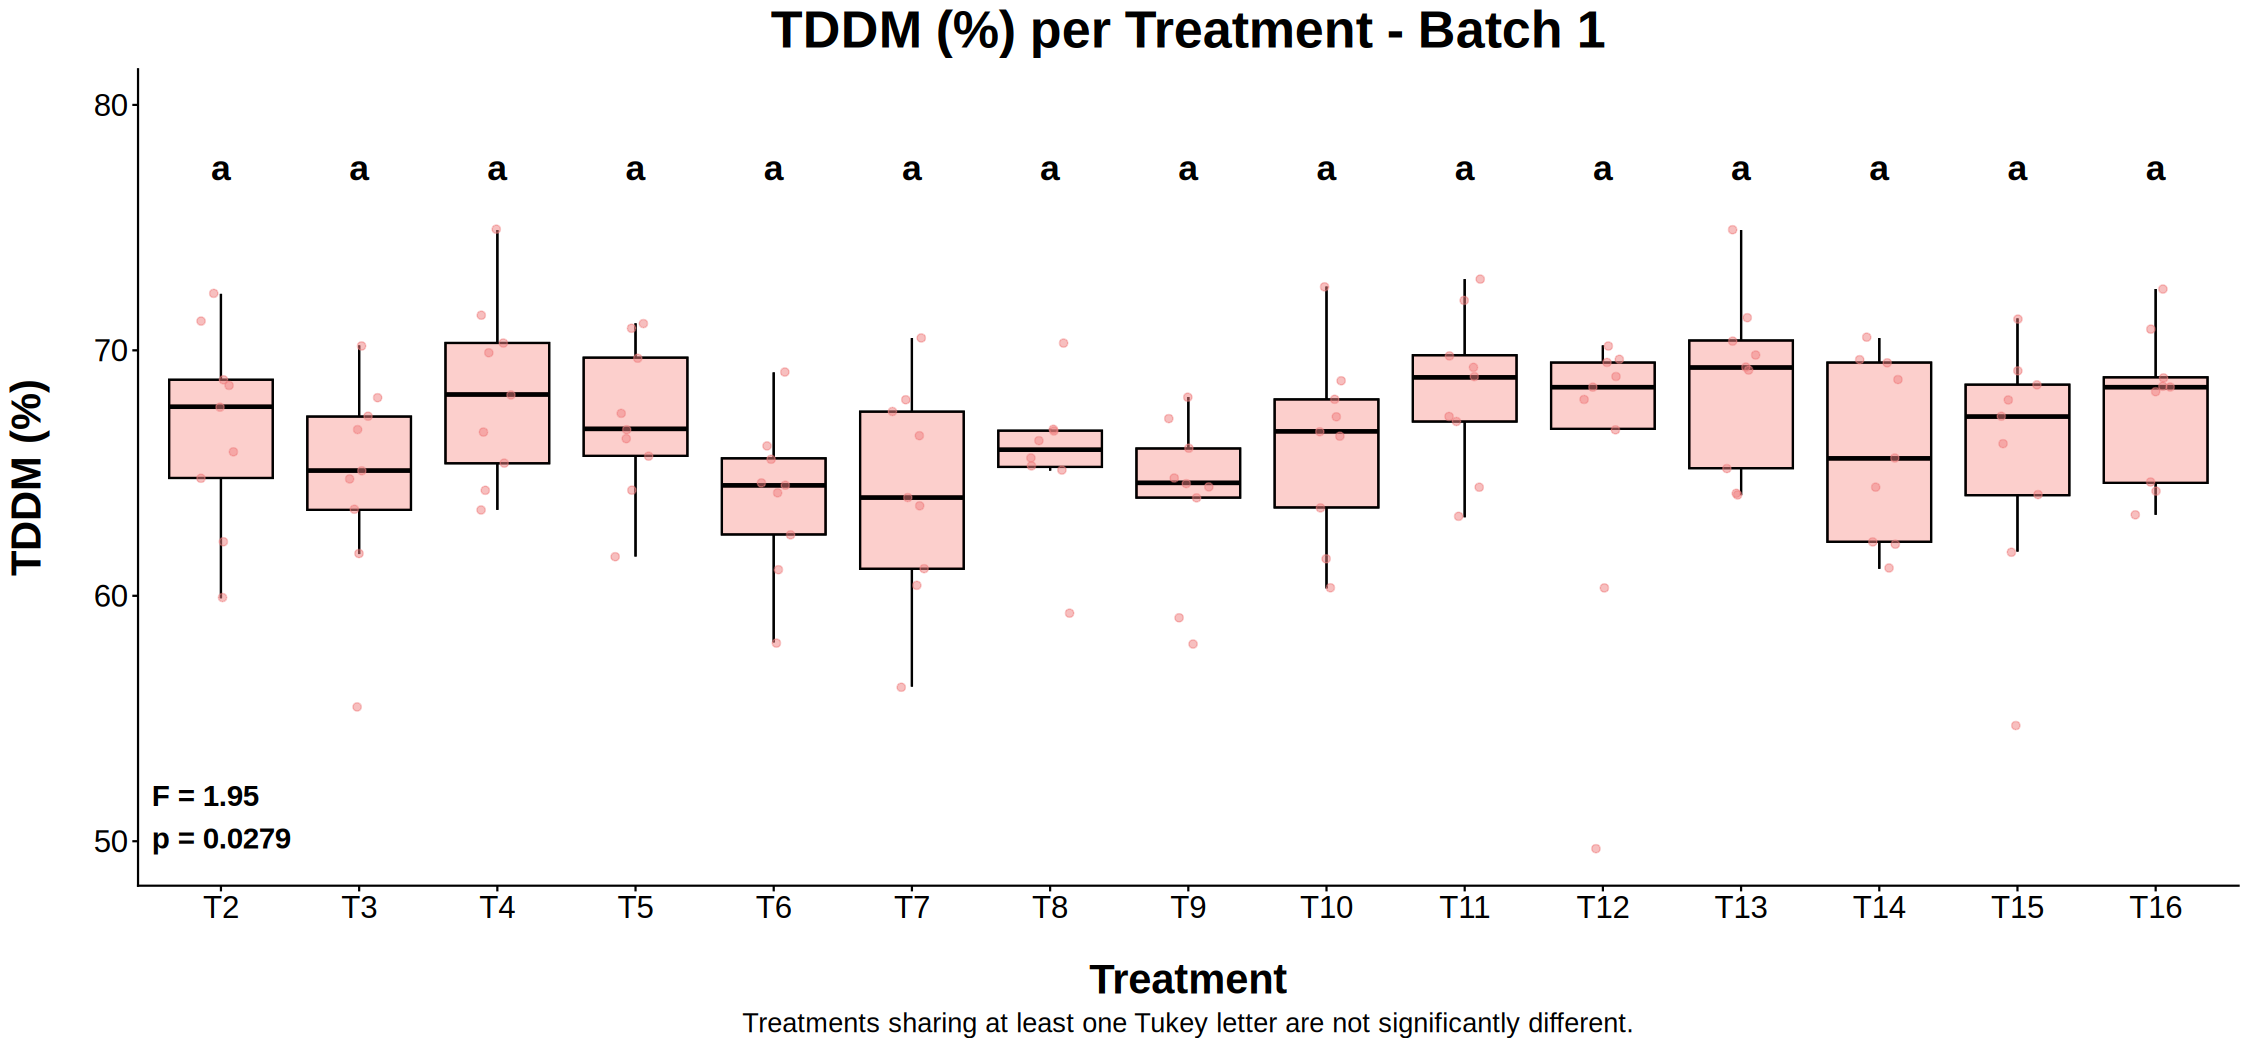

In [2340]:
result_batch_1 <- plot_anova_treatment(
  data = batch_1,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 1",
  y_label = "TDDM (%)"
)

### 5.1.2 Batch 2

In [2341]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: TDDM (%) per Treatment - Batch 2 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq  NumDF DenDF  F_value p_value
1 Treatment 441.4958 27.5935 16    130.02 3.67    <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    1.7571   1.3255 
2 Residual 7.5184   2.7420 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 16.194 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9896   p = 0.336
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(16, 132) = 0.9124   p = 0.557
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 66.822         abc
       T17 68.629         abc
       T18 68.522         abc
       T19 69.278          ab
       T2

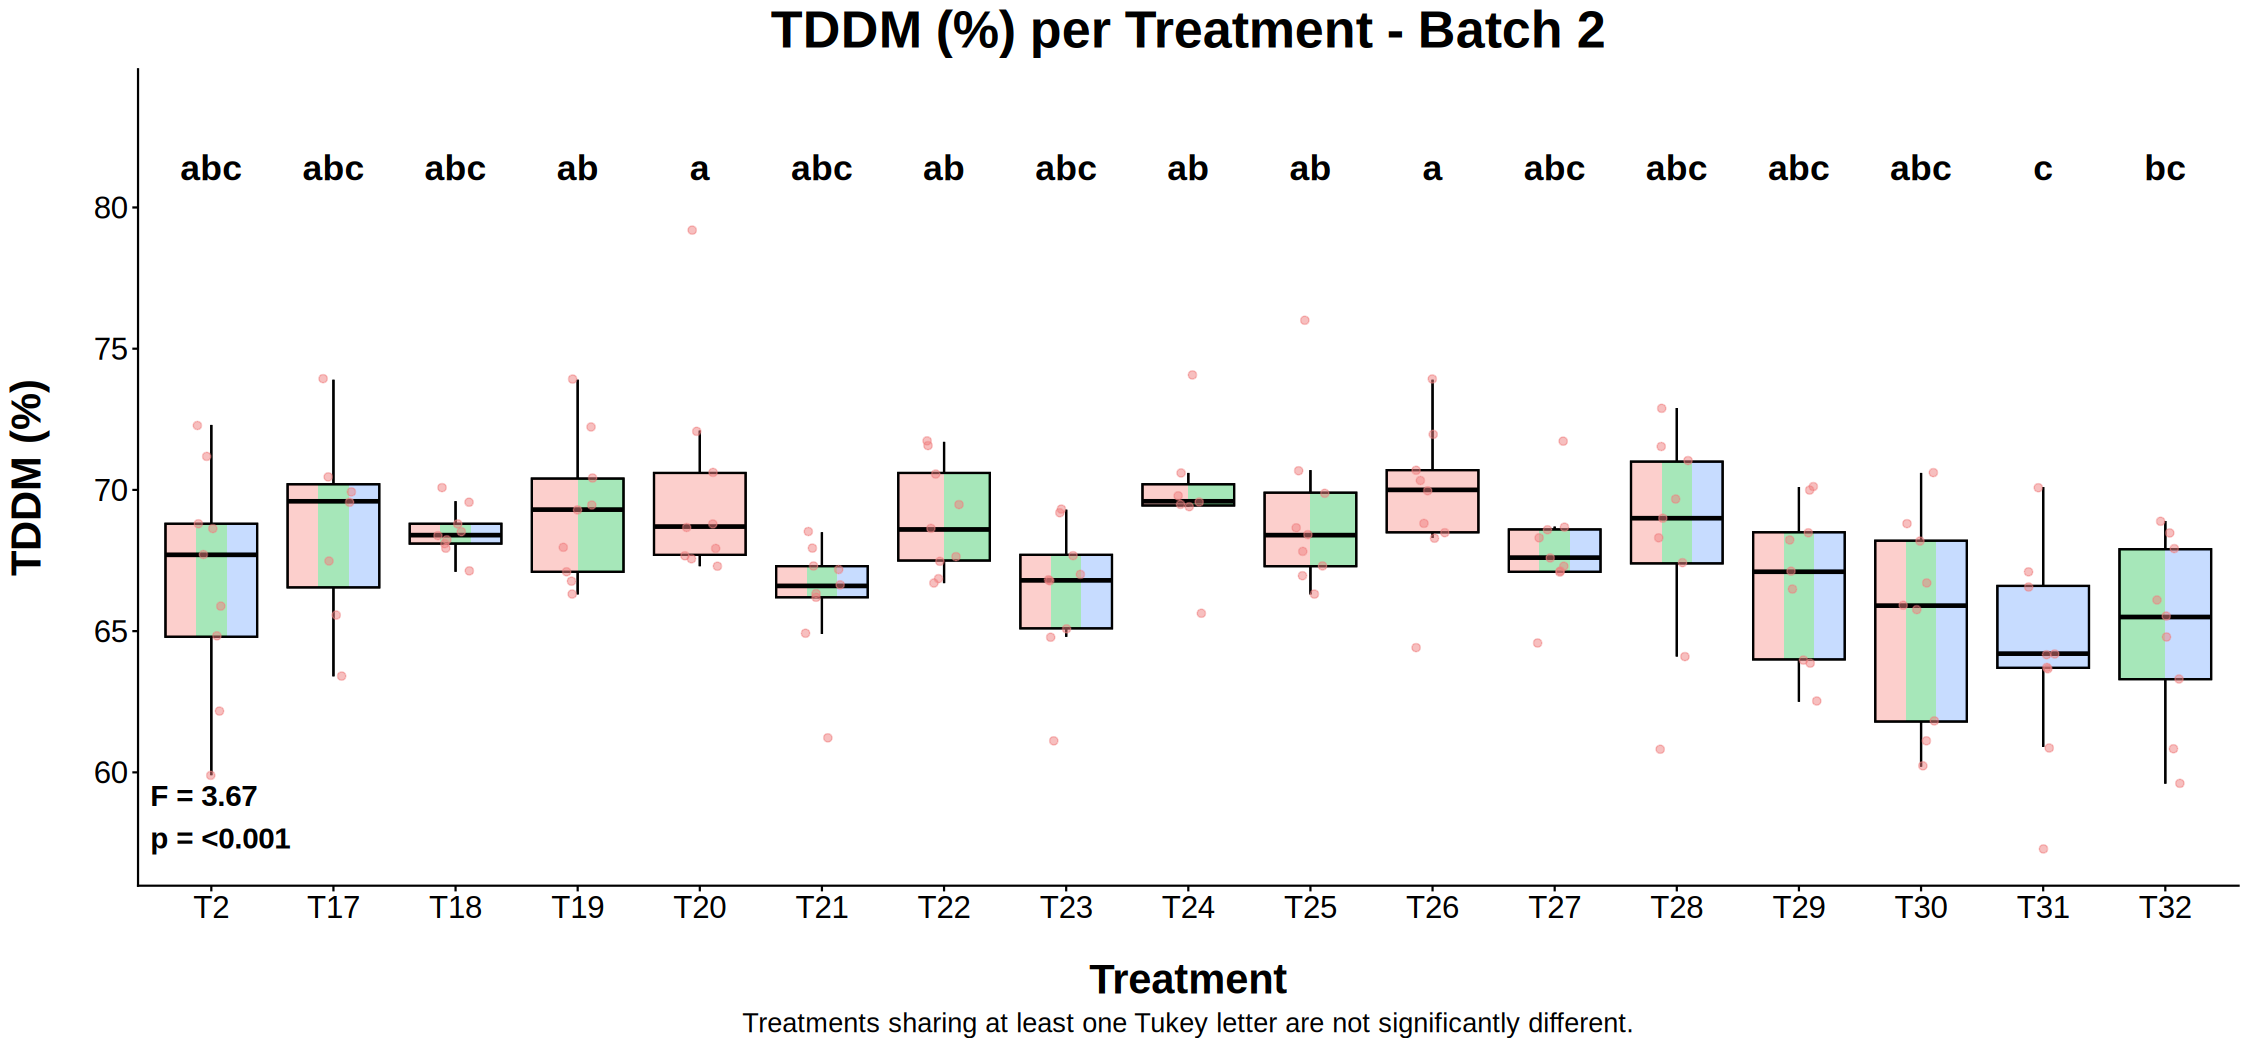

In [2342]:
result_batch_2 <- plot_anova_treatment(
  data = batch_2,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 2",
  y_label = "TDDM (%)"
)

### 5.1.3 Batch 3

In [2343]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: TDDM (%) per Treatment - Batch 3 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq  NumDF DenDF F_value p_value
1 Treatment 145.6911 16.1879 9     74.08 2.295   0.0248 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    1.1513   1.0730 
2 Residual 7.0547   2.6561 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT   Df p_value
1 (1 | Batch) 5.352 1  0.0207 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9746   p = 0.0879
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(9, 76) = 1.0043   p = 0.444
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 66.822           a
       T17 68.629           a
       T18 68.522           a
       T19 69.278           a
       T20 69.

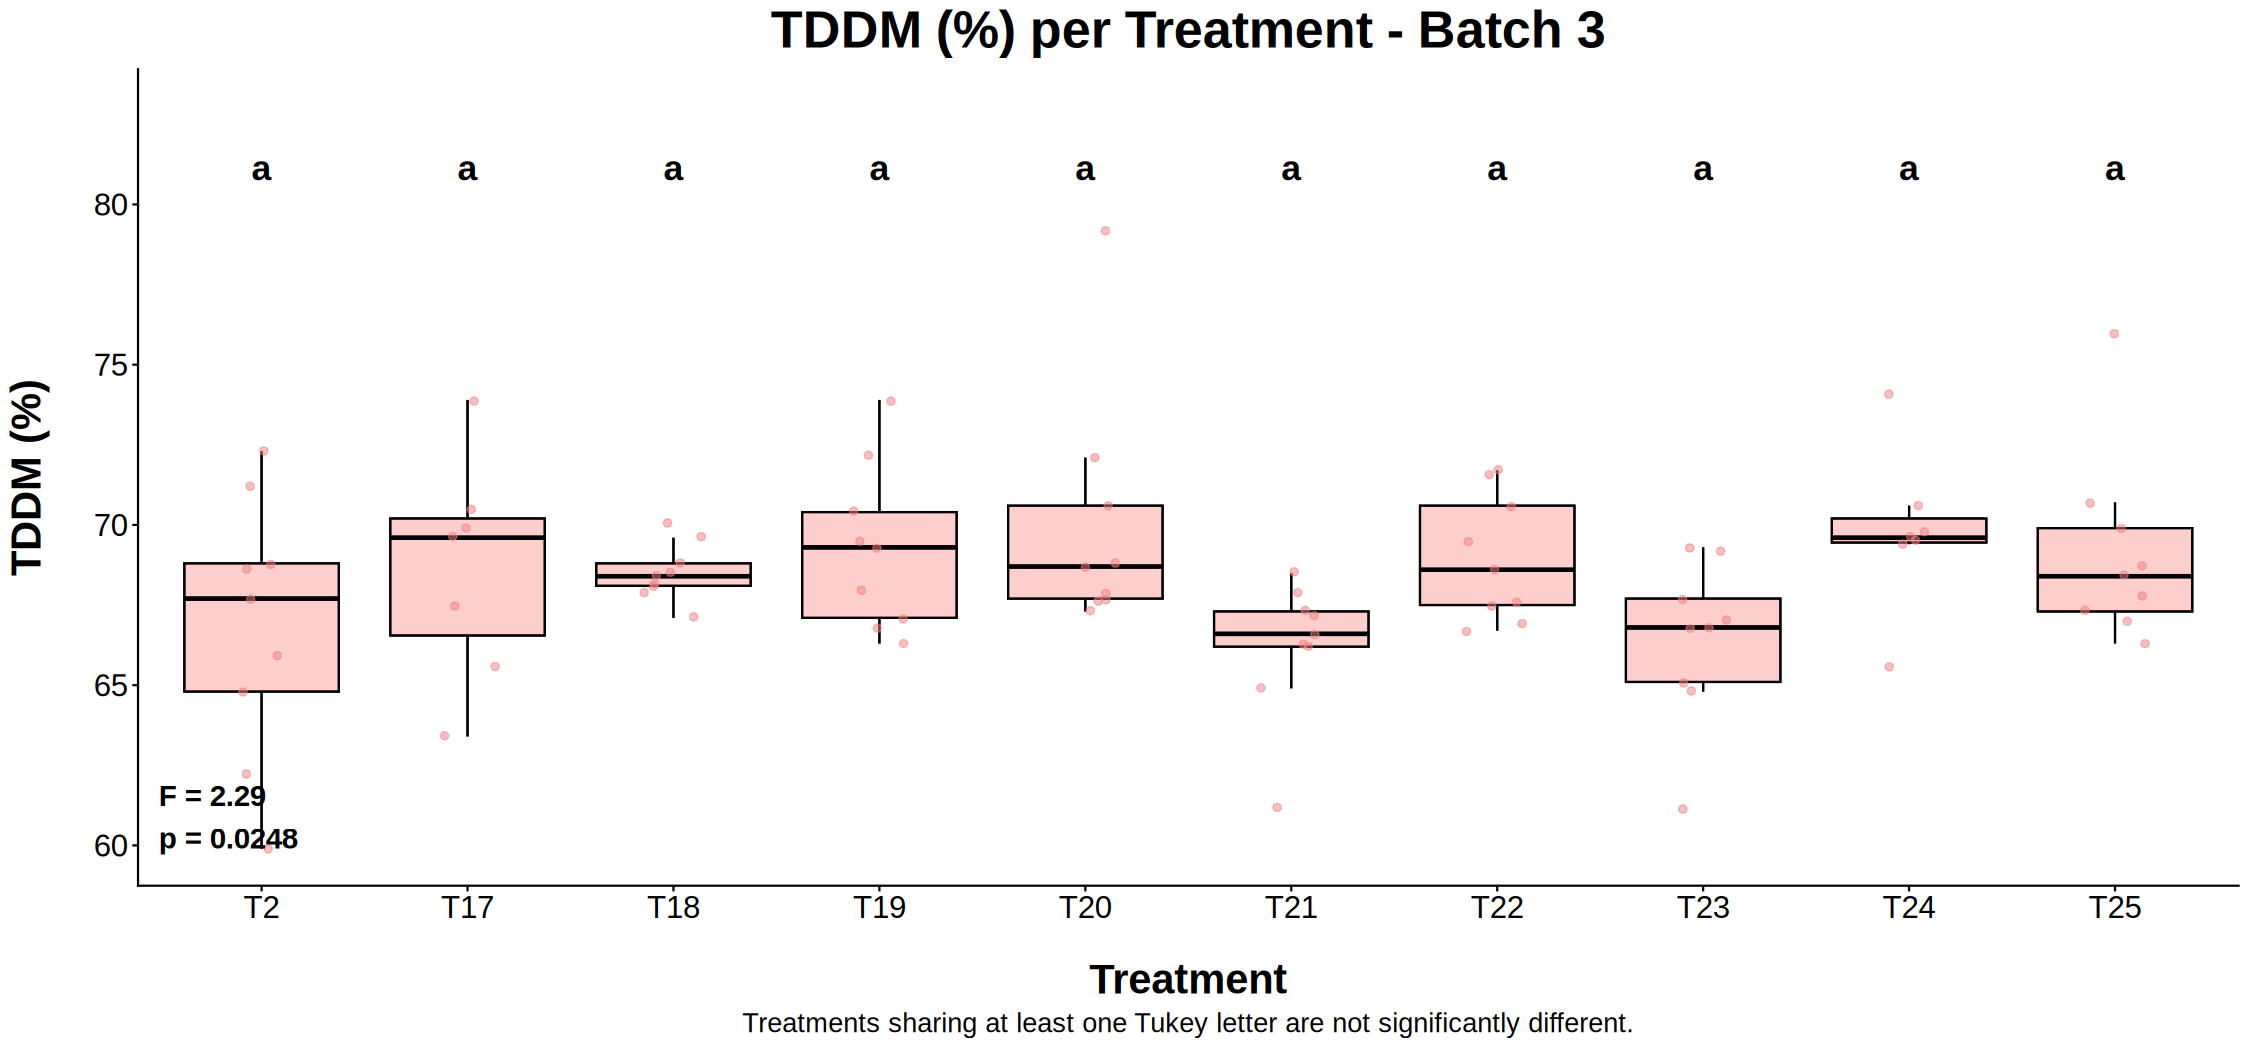

In [2344]:
result_batch_3 <- plot_anova_treatment(
  data = batch_3,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 3",
  y_label = "TDDM (%)"
)

### 5.1.4 Batch 4

In [2345]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: TDDM (%) per Treatment - Batch 4 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq NumDF DenDF F_value p_value
1 Treatment 209.0899 29.87  7     62    3.512   0.00309
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    3.1376   1.7713 
2 Residual 8.5061   2.9165 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 11.056 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9802   p = 0.316
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(7, 64) = 0.7188   p = 0.656
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 66.822          ab
       T26 69.656           a
       T27 67.889          ab
       T28 68.300          ab
       T29 66.7

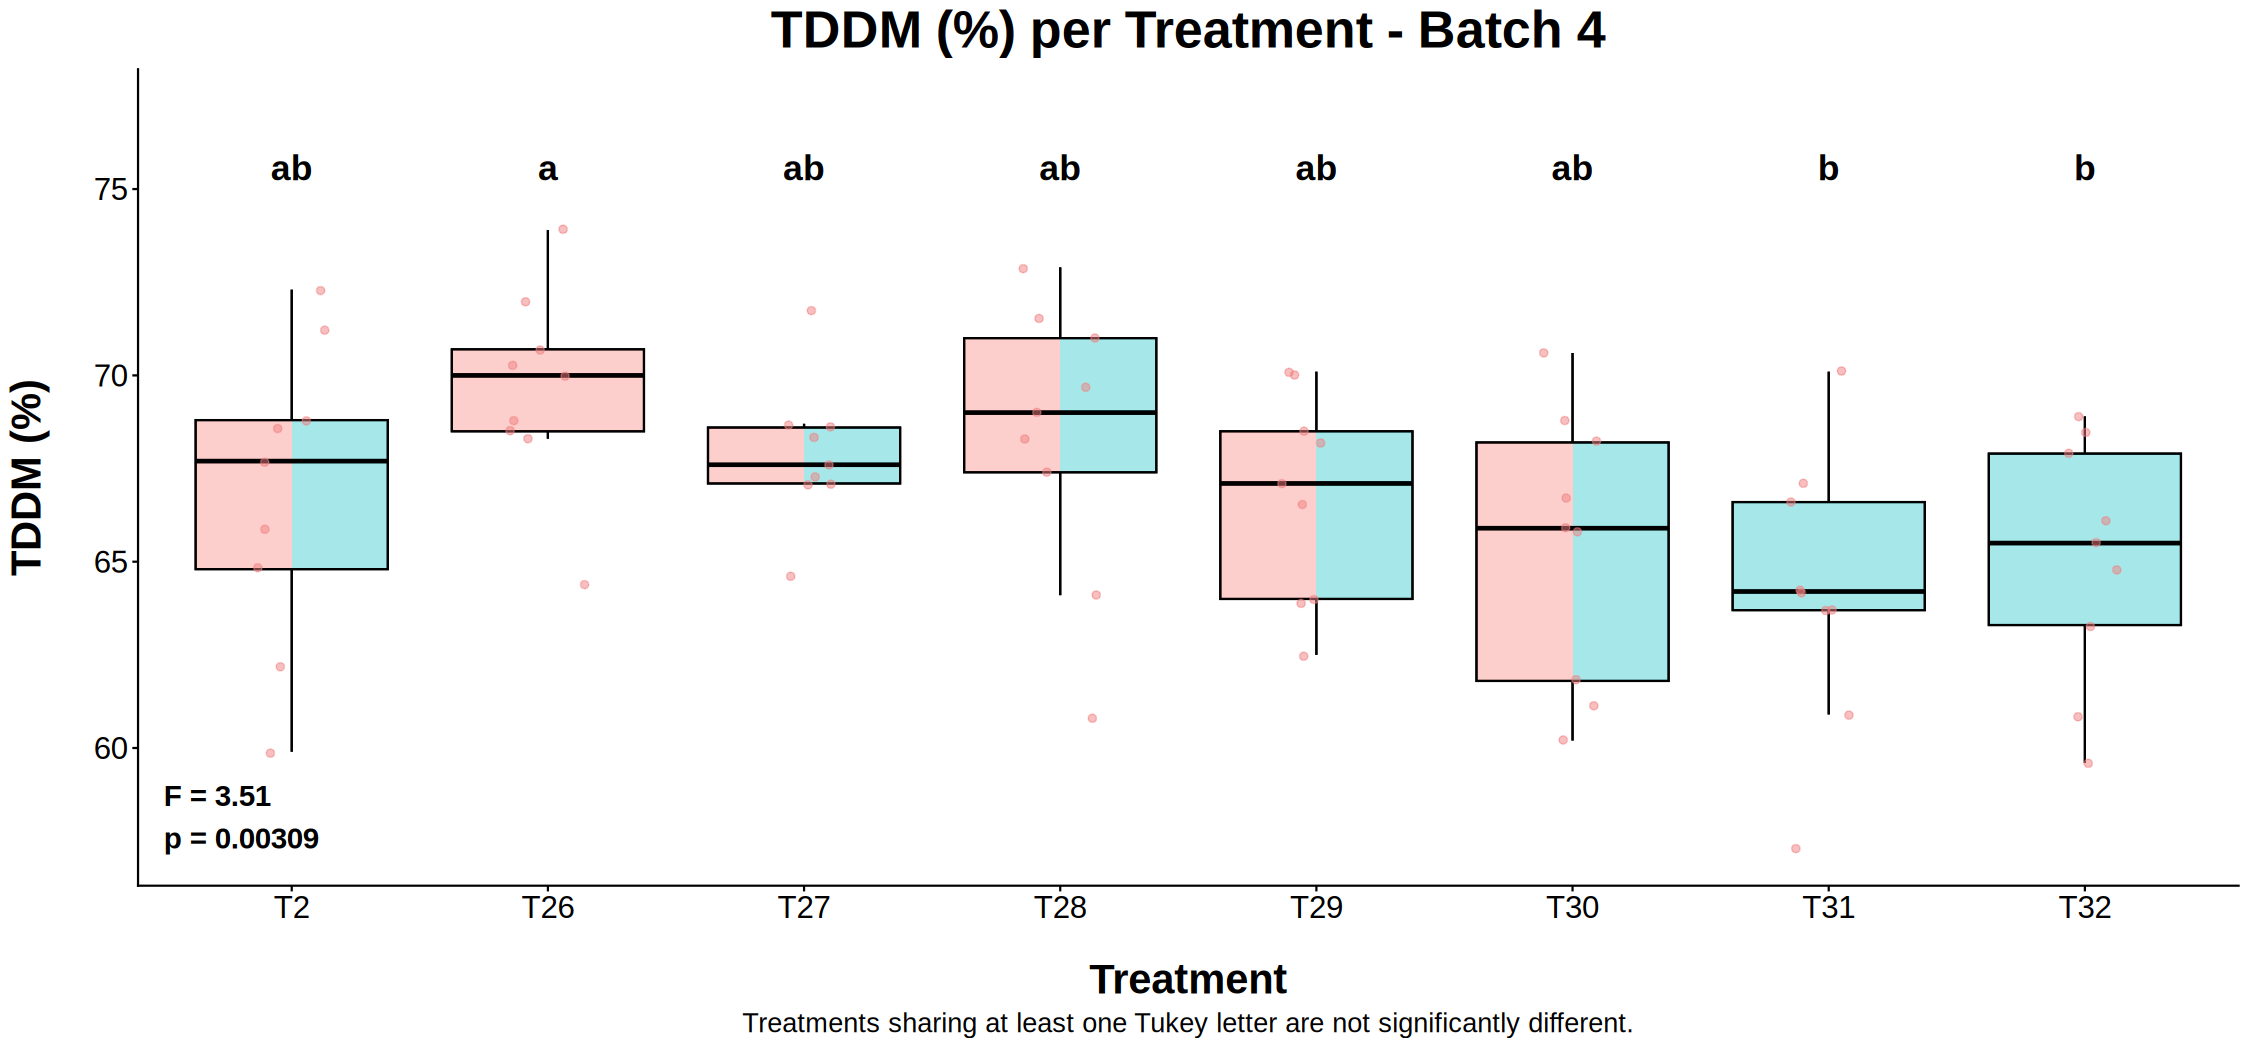

In [2346]:
result_batch_4 <- plot_anova_treatment(
  data = batch_4,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 4",
  y_label = "TDDM (%)"
)

## 5.2 Methane Intensity

### 5.2.1 Batch 1

In [2347]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Methane Intensity per Treatment - Batch 1 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF F_value p_value
1 Treatment 2427.438 173.3884 14    117   11.758  <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    18.6944  4.3237 
2 Residual 14.7469  3.8402 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 70.974 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.8982   p = <0.001
  -> Normality is rejected (p <= 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(14, 119) = 1.0320   p = 0.427
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 56.344          ab
        T3 56.656          ab
        T4 51.322           a
        T5 55.333          ab
  

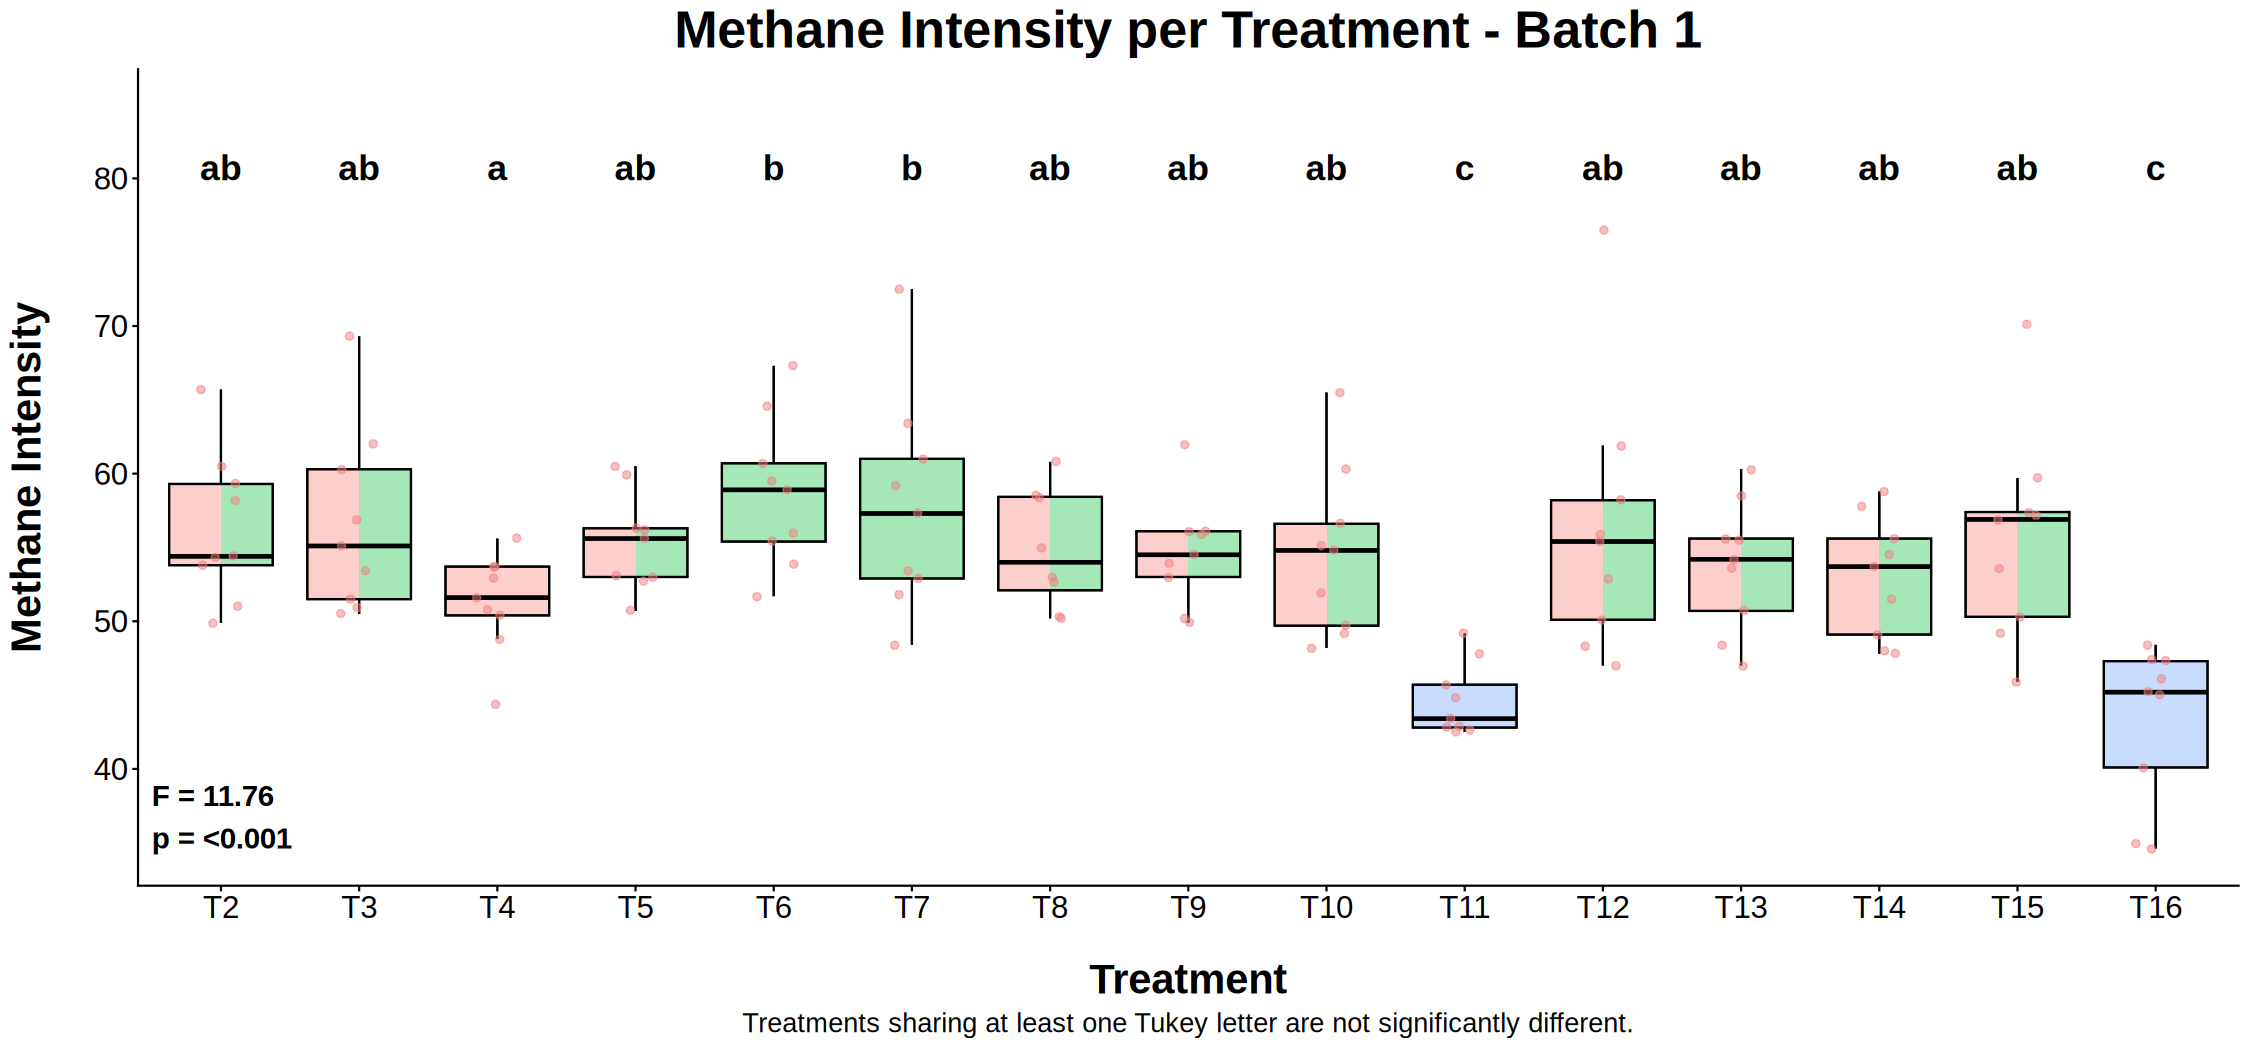

In [2348]:
result_batch_1_methane_intensity <- plot_anova_treatment(
  data = batch_1,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 1",
  y_label = "Methane Intensity"
)

### 5.2.2 Batch 2

In [2349]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Methane Intensity per Treatment - Batch 2 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF  F_value p_value
1 Treatment 8155.908 509.7442 16    130.01 18.935  <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    13.0371  3.6107 
2 Residual 26.9209  5.1885 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT   Df p_value
1 (1 | Batch) 34.88 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9926   p = 0.632
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(16, 132) = 2.5038   p = 0.00225
  -> Homogeneity of variances is rejected (p <= 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 56.344           a
       T17 49.214         abc
       T18 44.556          bd
       T19 49.067         abc
 

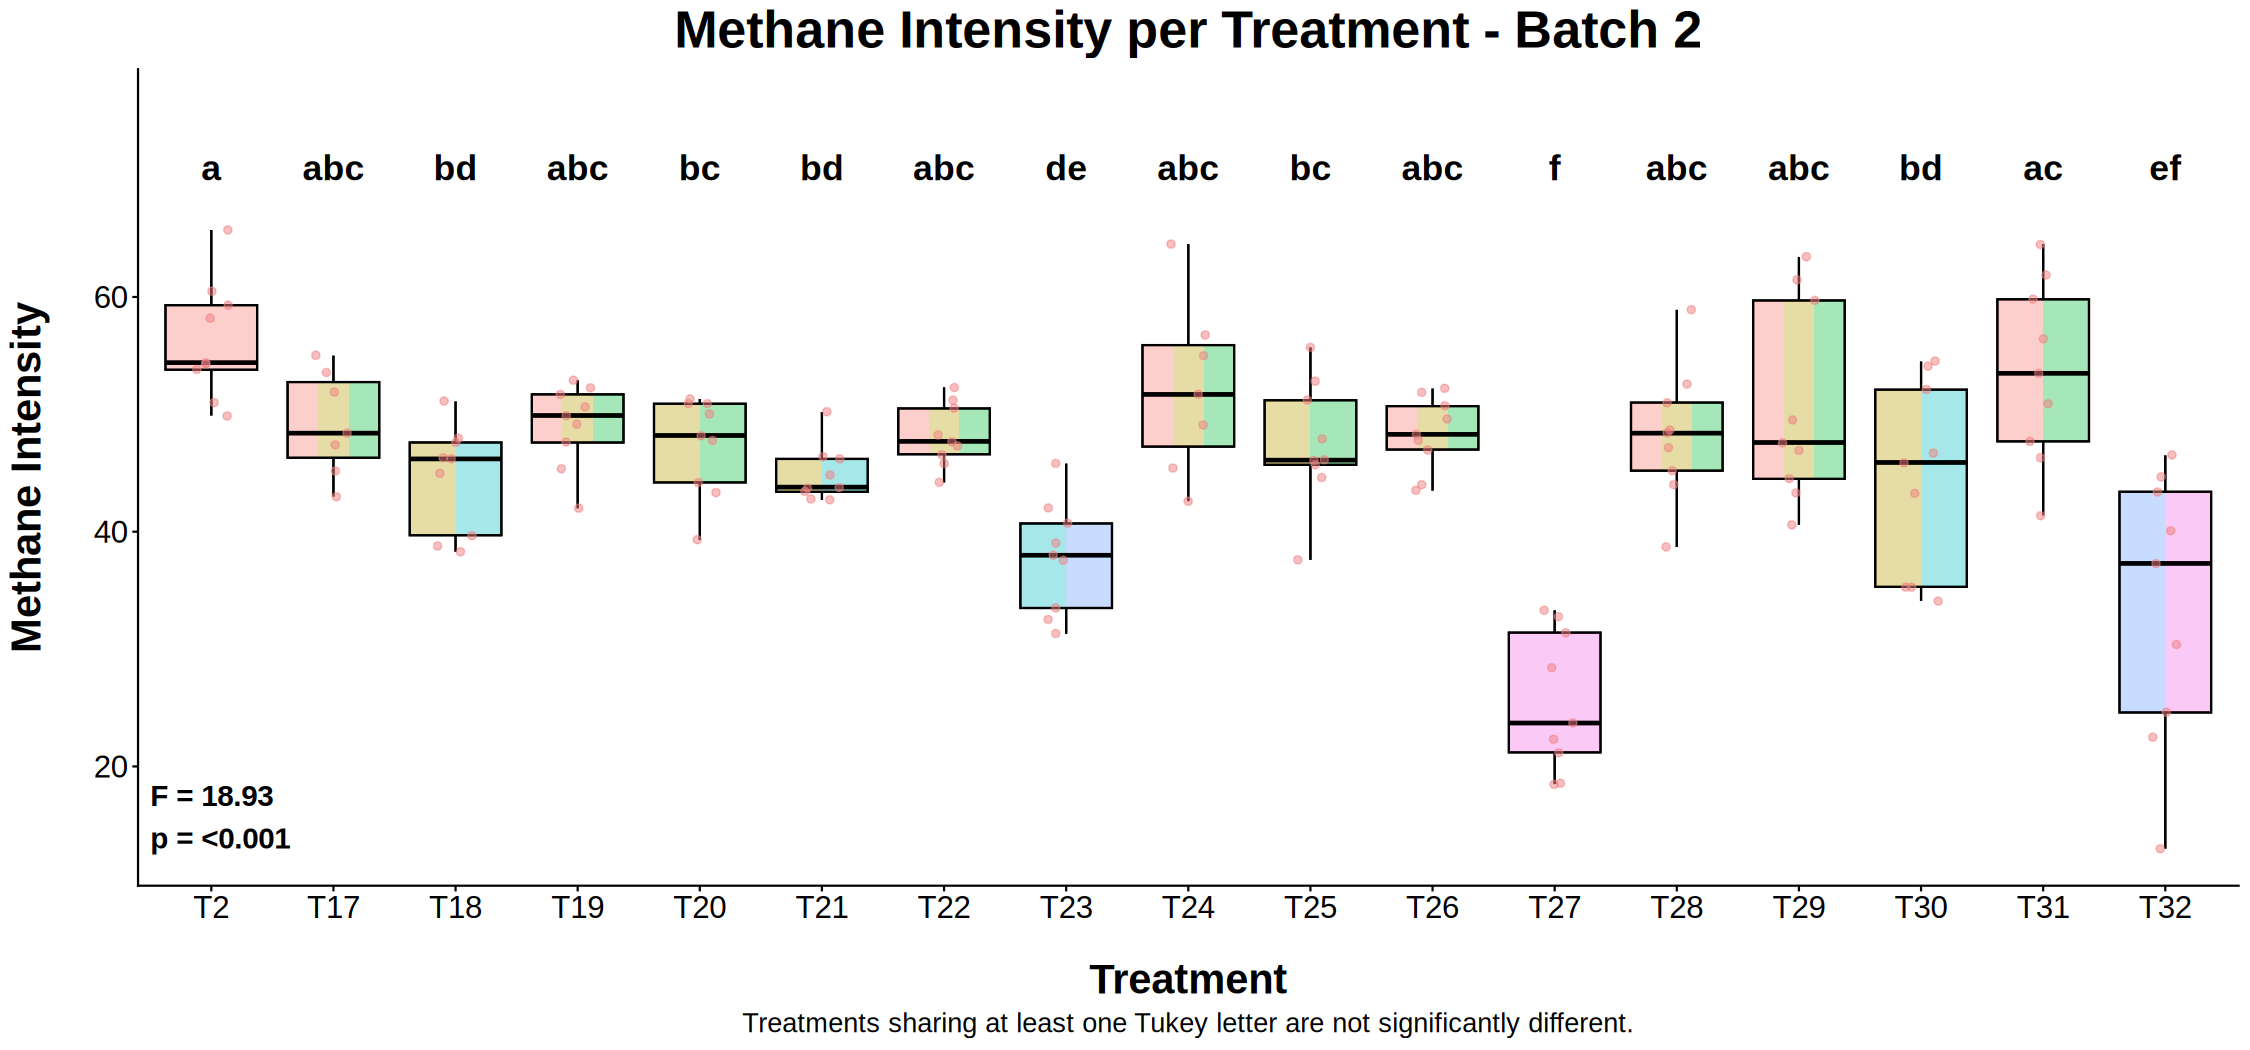

In [2350]:
result_batch_2_methane_intensity <- plot_anova_treatment(
  data = batch_2,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 2",
  y_label = "Methane Intensity"
)

### 5.2.3 Batch 3

In [2351]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Methane Intensity per Treatment - Batch 3 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF F_value p_value
1 Treatment 1925.978 213.9976 9     74.04 13.849  <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch     6.6569  2.5801 
2 Residual 15.4521  3.9309 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 16.461 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9626   p = 0.0137
  -> Normality is rejected (p <= 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(9, 76) = 1.0975   p = 0.375
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 56.344           a
       T17 49.214          bc
       T18 44.556           b
       T19 49.067          bc
    

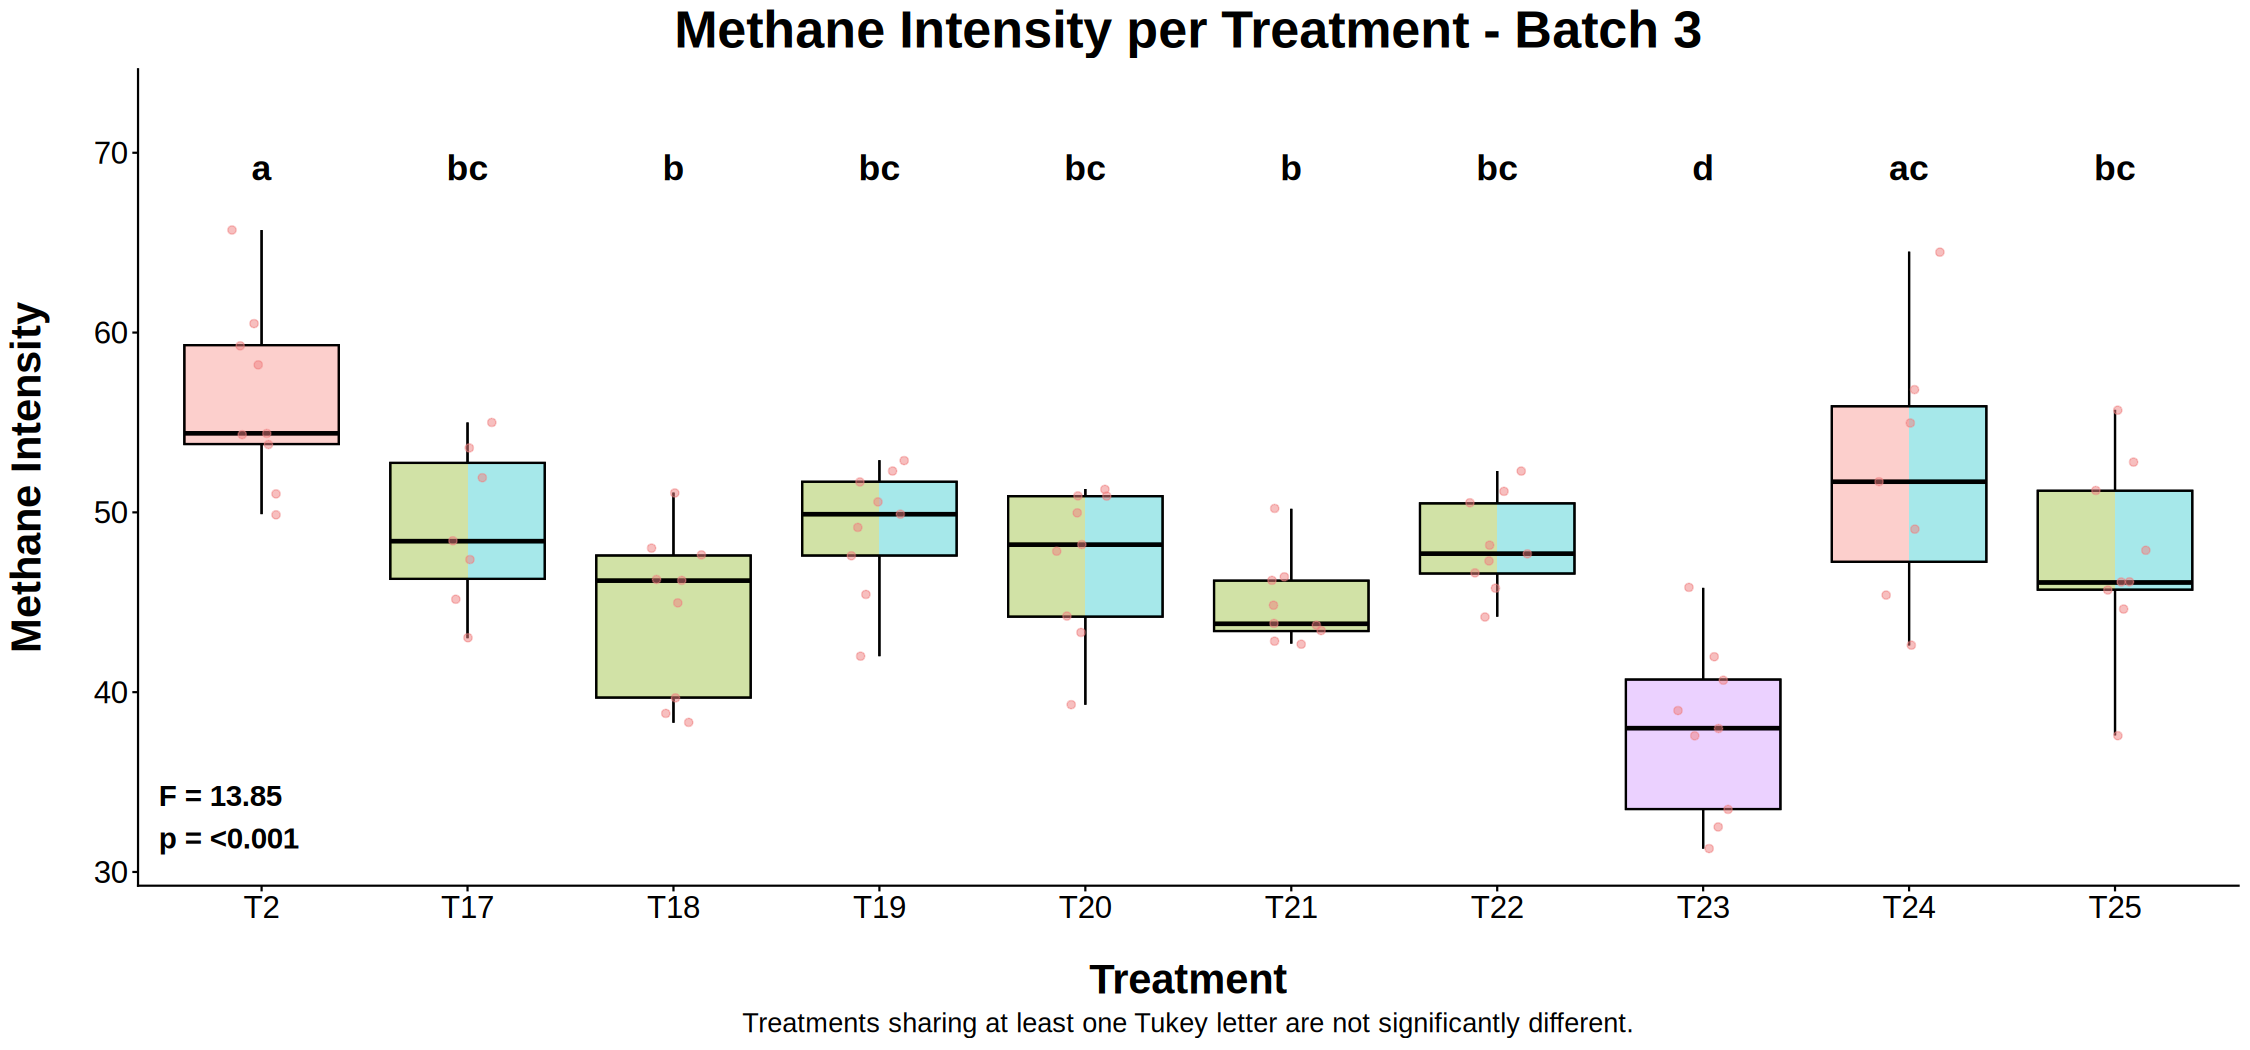

In [2352]:
result_batch_3_methane_intensity <- plot_anova_treatment(
  data = batch_3,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 3",
  y_label = "Methane Intensity"
)

### 5.2.4 Batch 4

In [2353]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Methane Intensity per Treatment - Batch 4 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF F_value p_value
1 Treatment 6884.804 983.5434 7     62    26.597  <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    23.6098  4.8590 
2 Residual 36.9797  6.0811 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 19.455 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9747   p = 0.156
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(7, 64) = 2.0057   p = 0.0679
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T2 56.344           a
       T26 48.333          ab
       T27 25.578           c
       T28 48.300          ab
 

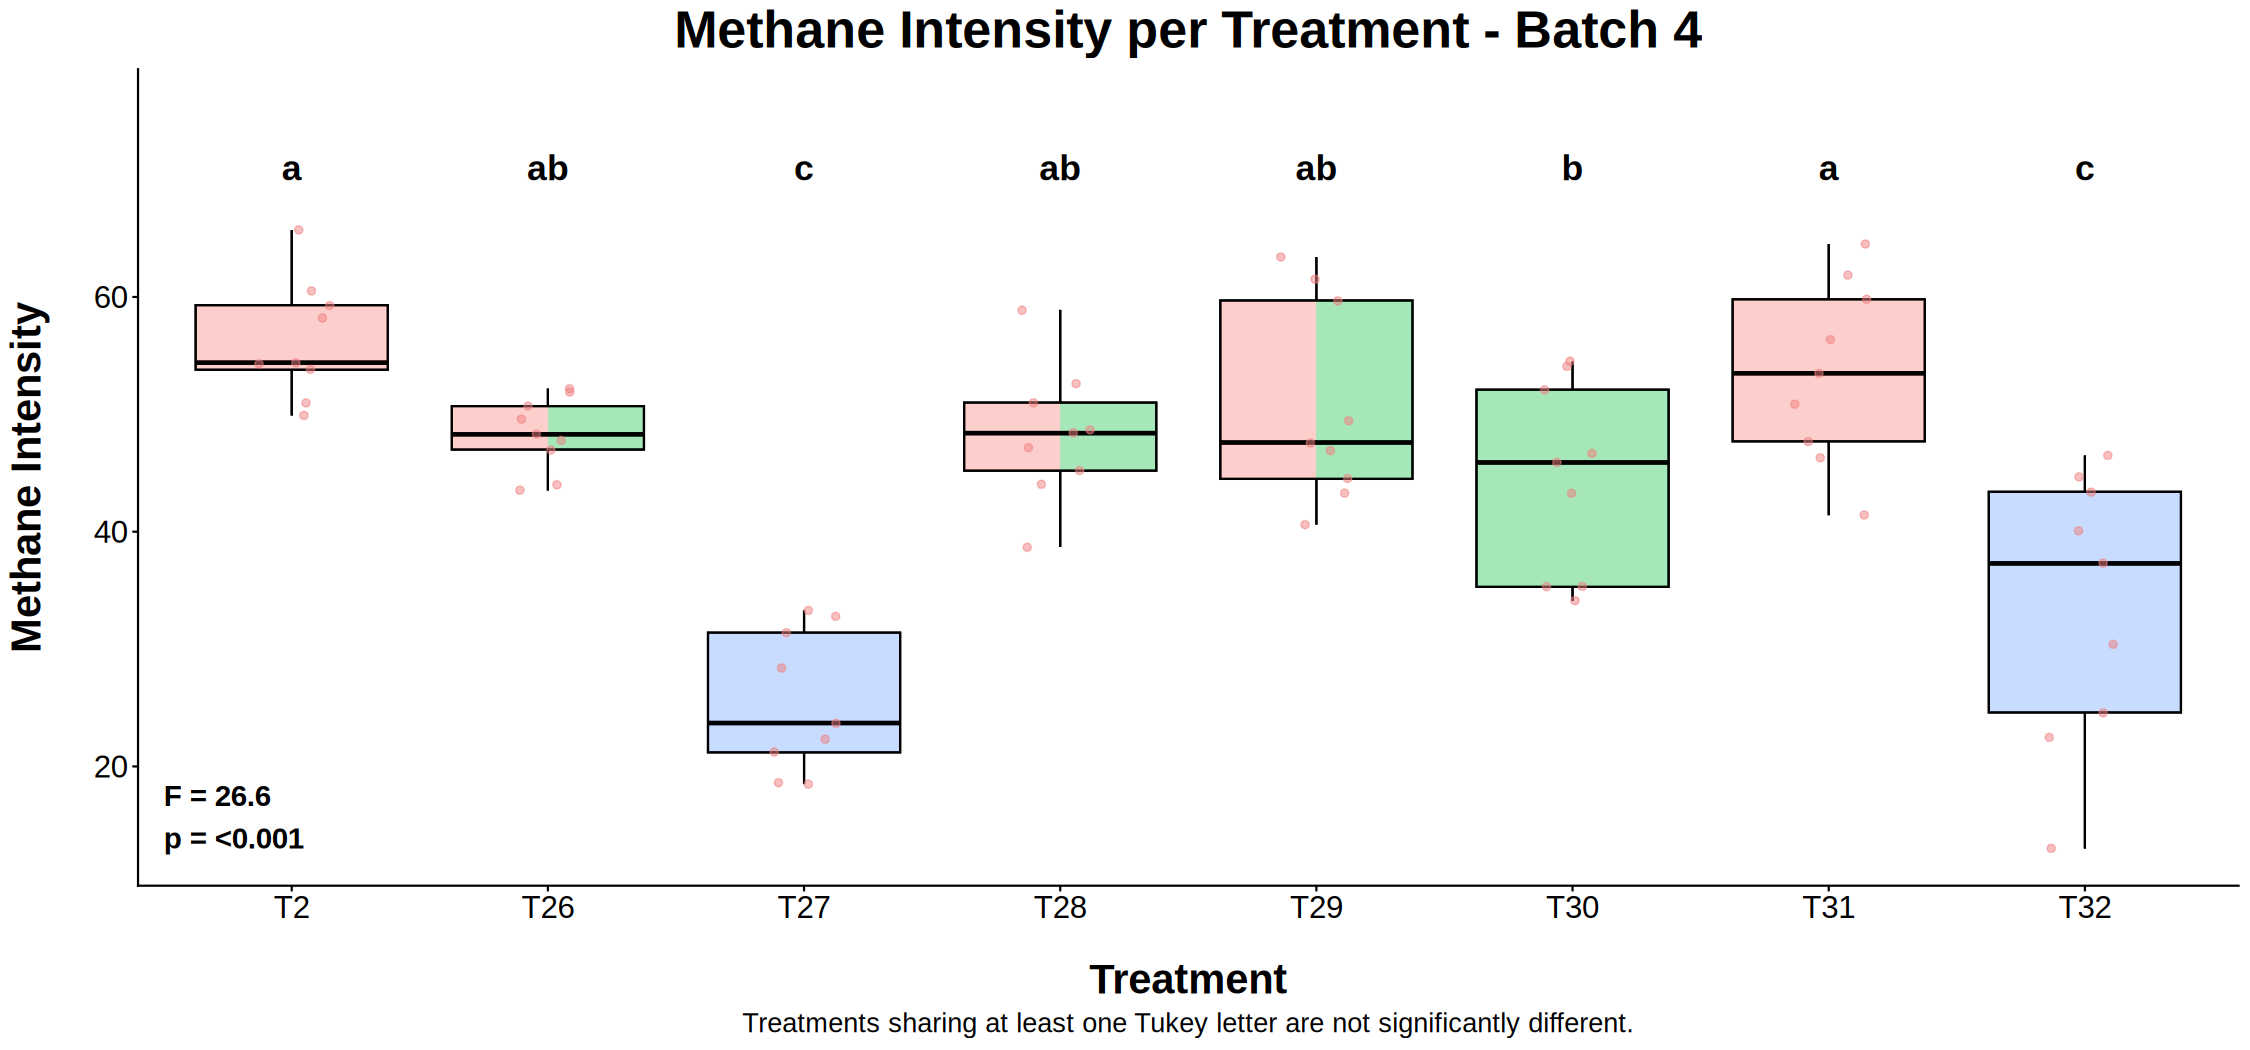

In [2354]:
result_batch_4_methane_intensity <- plot_anova_treatment(
  data = batch_4,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 4",
  y_label = "Methane Intensity"
)

## 5.3 Ammonium

### 5.3.1 Batch 1

In [2355]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Ammonium per Treatment - Batch 1 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF F_value p_value
1 Treatment 335252.6 23946.61 14    118   3.146   <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    4016.637 63.3769
2 Residual 7612.015 87.2469

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 33.595 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9927   p = 0.72
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(14, 120) = 1.7444   p = 0.0554
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment    Mean Tukey_Group
        T2 121.842           a
        T3 288.486           b
        T4 193.497          ab
        T5 106.864           a
    

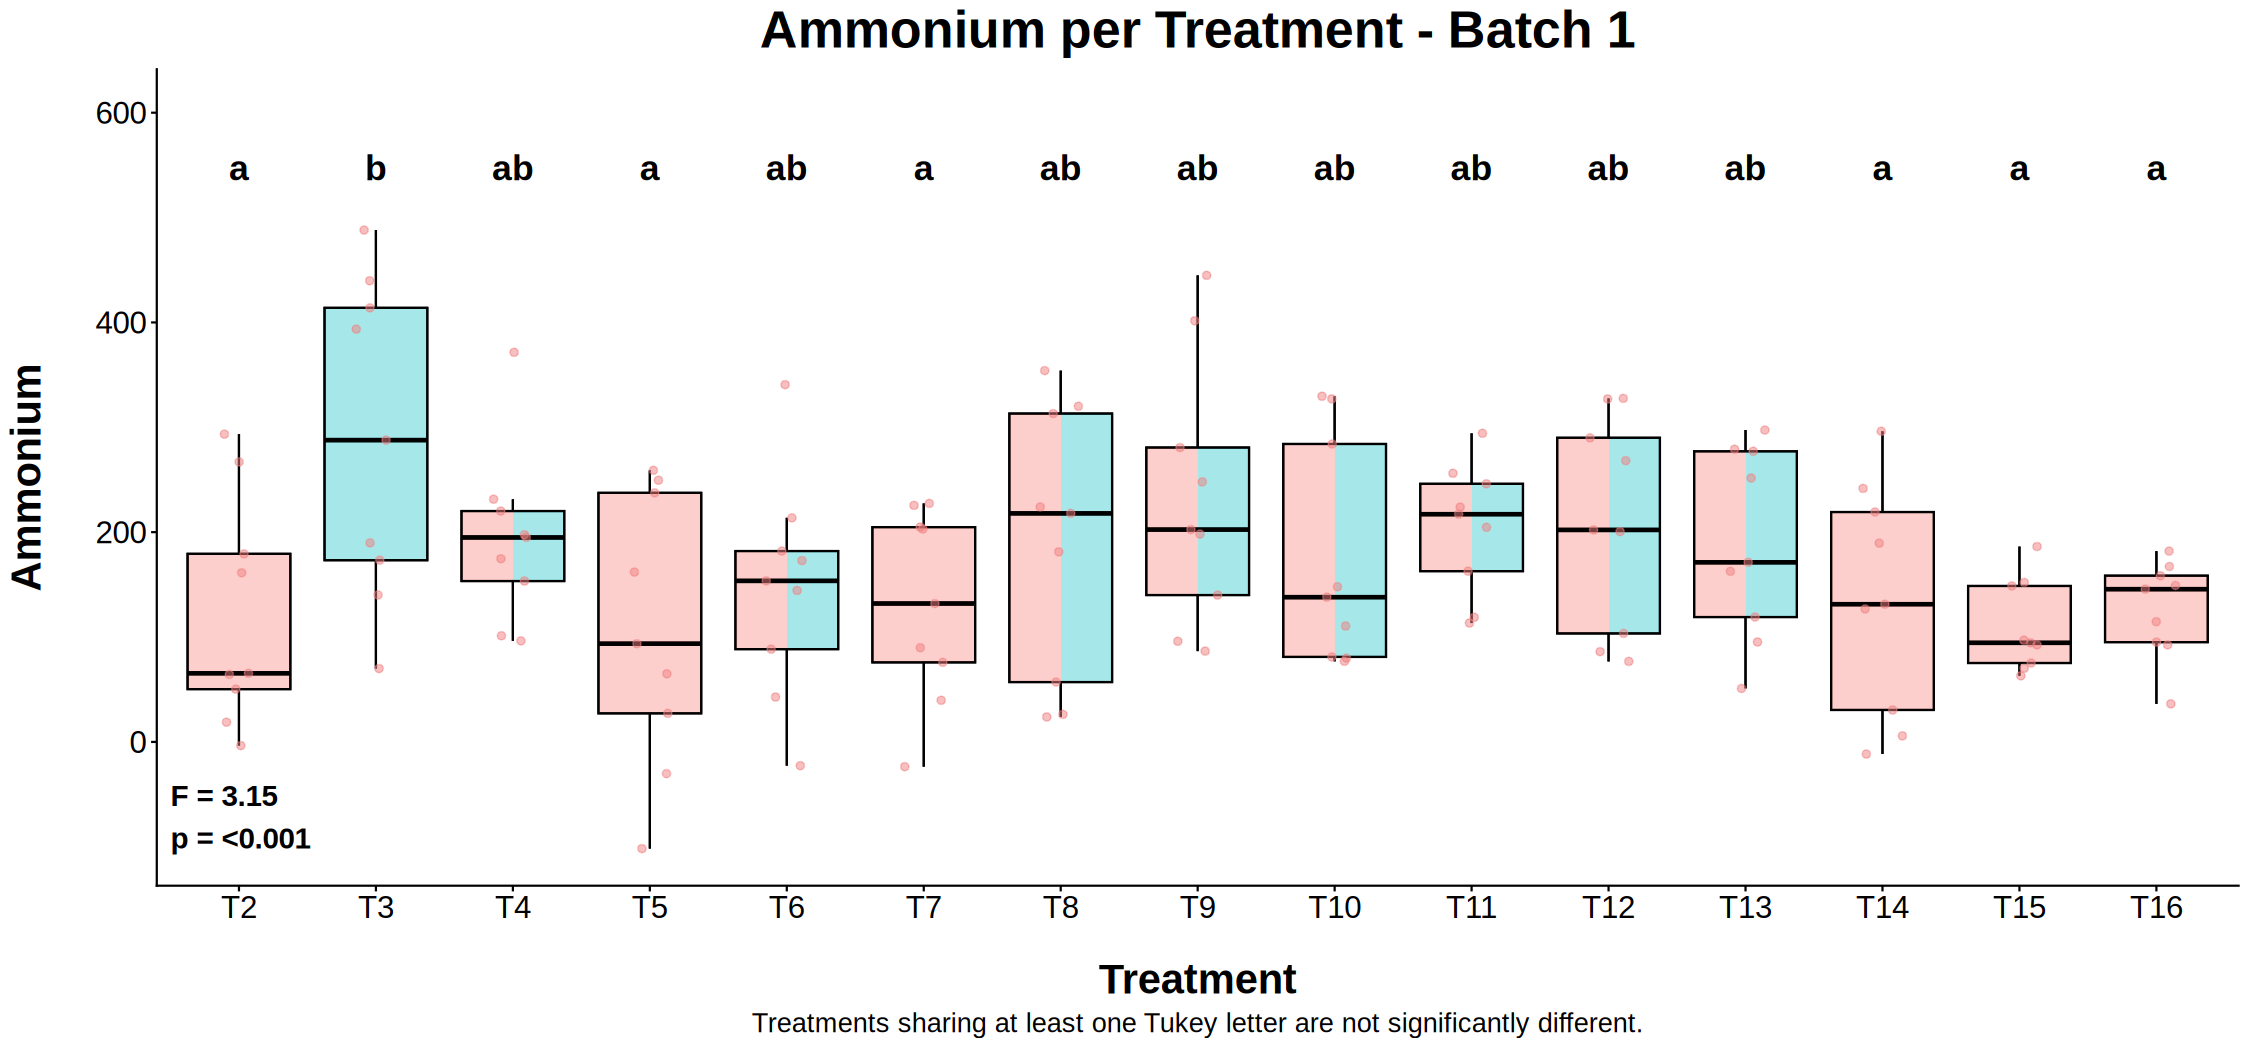

In [2356]:
result_batch_1_ammonium <- plot_anova_treatment(
  data = batch_1,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 1",
  y_label = "Ammonium"
)

### 5.3.2 Batch 2

In [2357]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Ammonium per Treatment - Batch 2 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq  NumDF DenDF F_value p_value
1 Treatment 307748.8 19234.3 16    132   2.952   <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance  Std_Dev 
1 Batch    12174.144 110.3365
2 Residual  6514.758  80.7141

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT     Df p_value
1 (1 | Batch) 107.133 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9843   p = 0.0841
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(16, 134) = 1.2020   p = 0.274
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment    Mean Tukey_Group
        T2 121.842          ab
       T17 111.275          ab
       T18 120.697          ab
       T19 127.453          

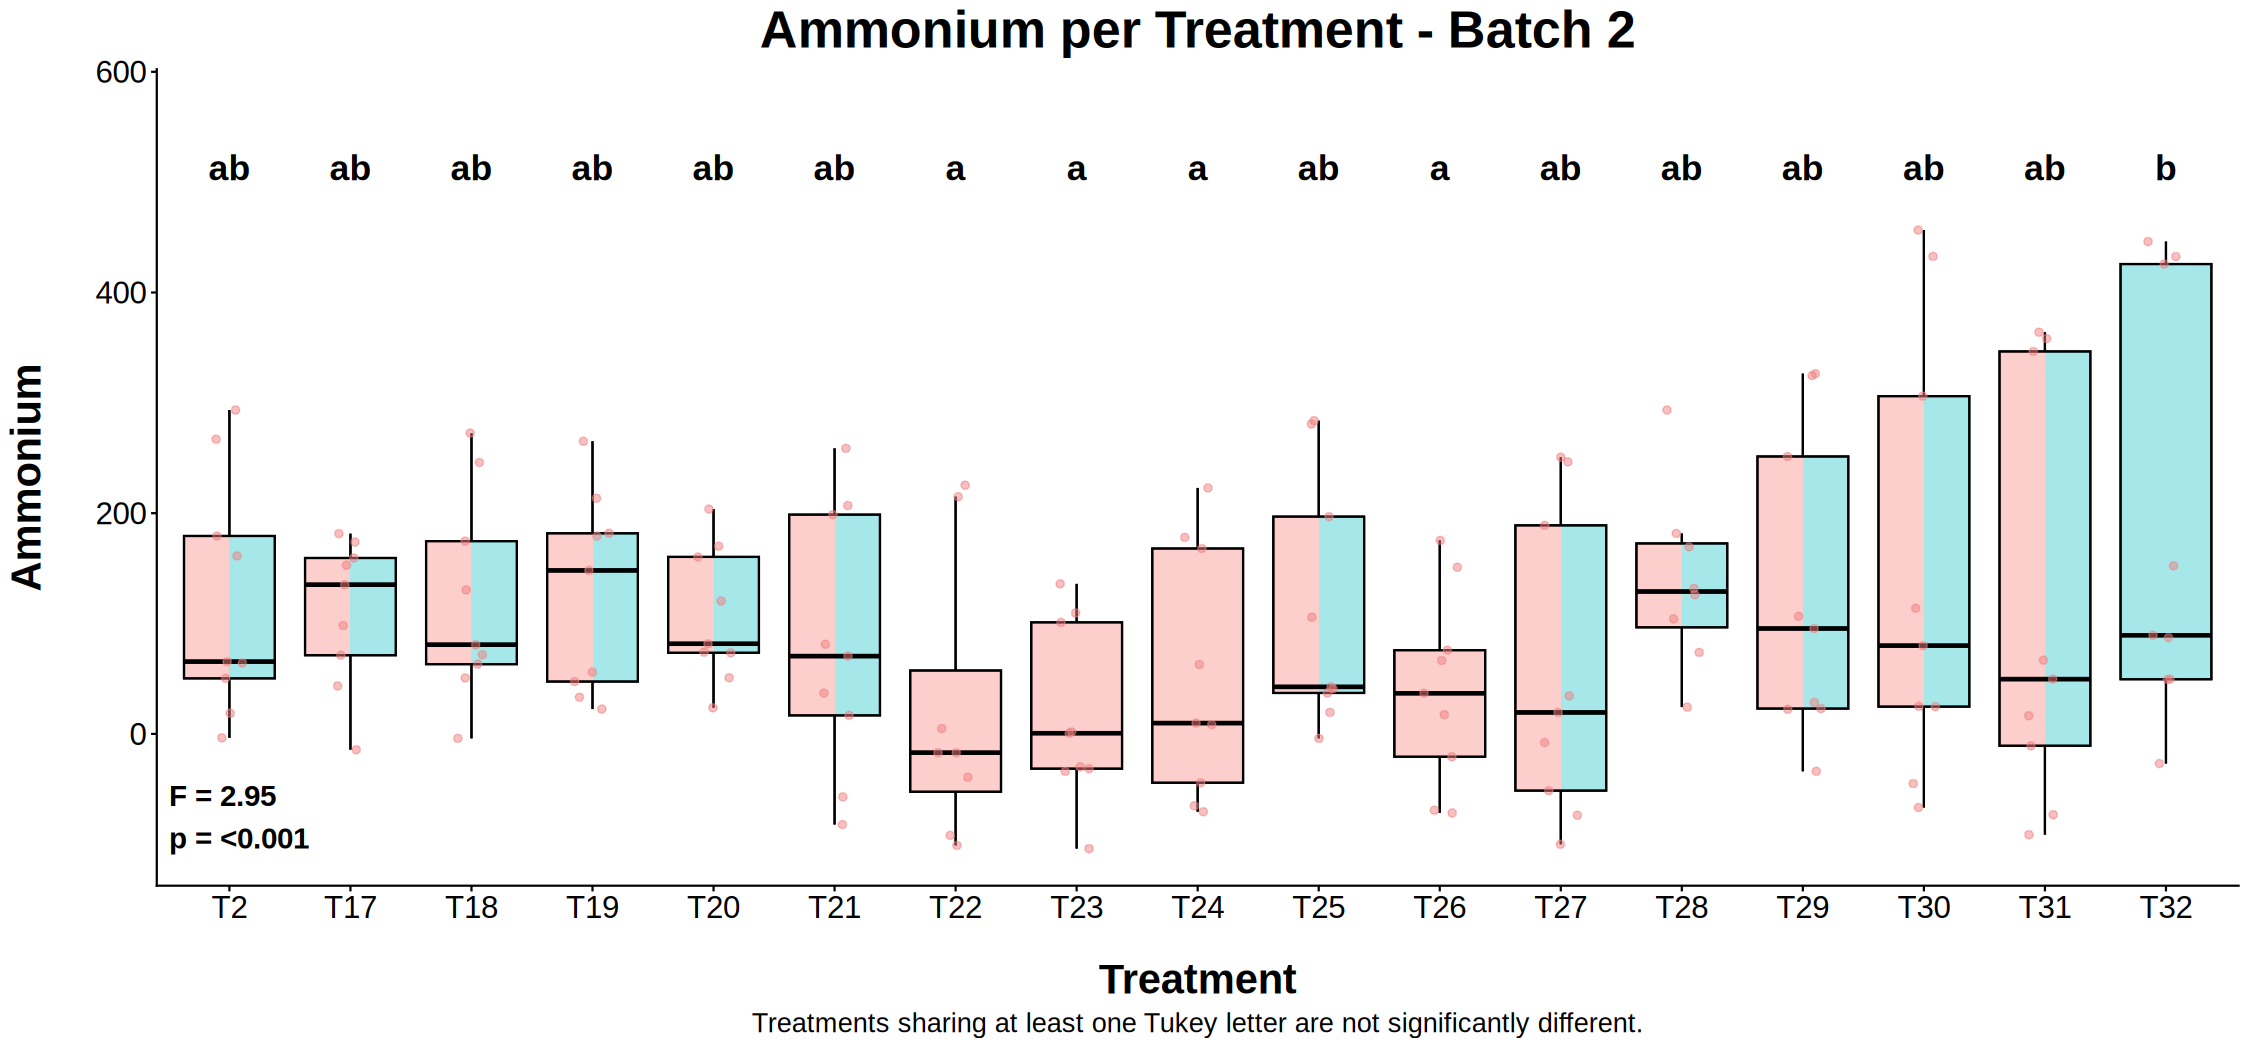

In [2358]:
result_batch_2_ammonium <- plot_anova_treatment(
  data = batch_2,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 2",
  y_label = "Ammonium"
)

### 5.3.3 Batch 3

In [2359]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Ammonium per Treatment - Batch 3 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF F_value p_value
1 Treatment 128429.2 14269.91 9     77    2.748   0.00772
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    6205.304 78.7738
2 Residual 5192.144 72.0565

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 42.952 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9735   p = 0.0653
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(9, 79) = 0.4607   p = 0.897
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment    Mean Tukey_Group
        T2 121.842          ab
       T17 111.275          ab
       T18 120.697          ab
       T19 127.453           a
     

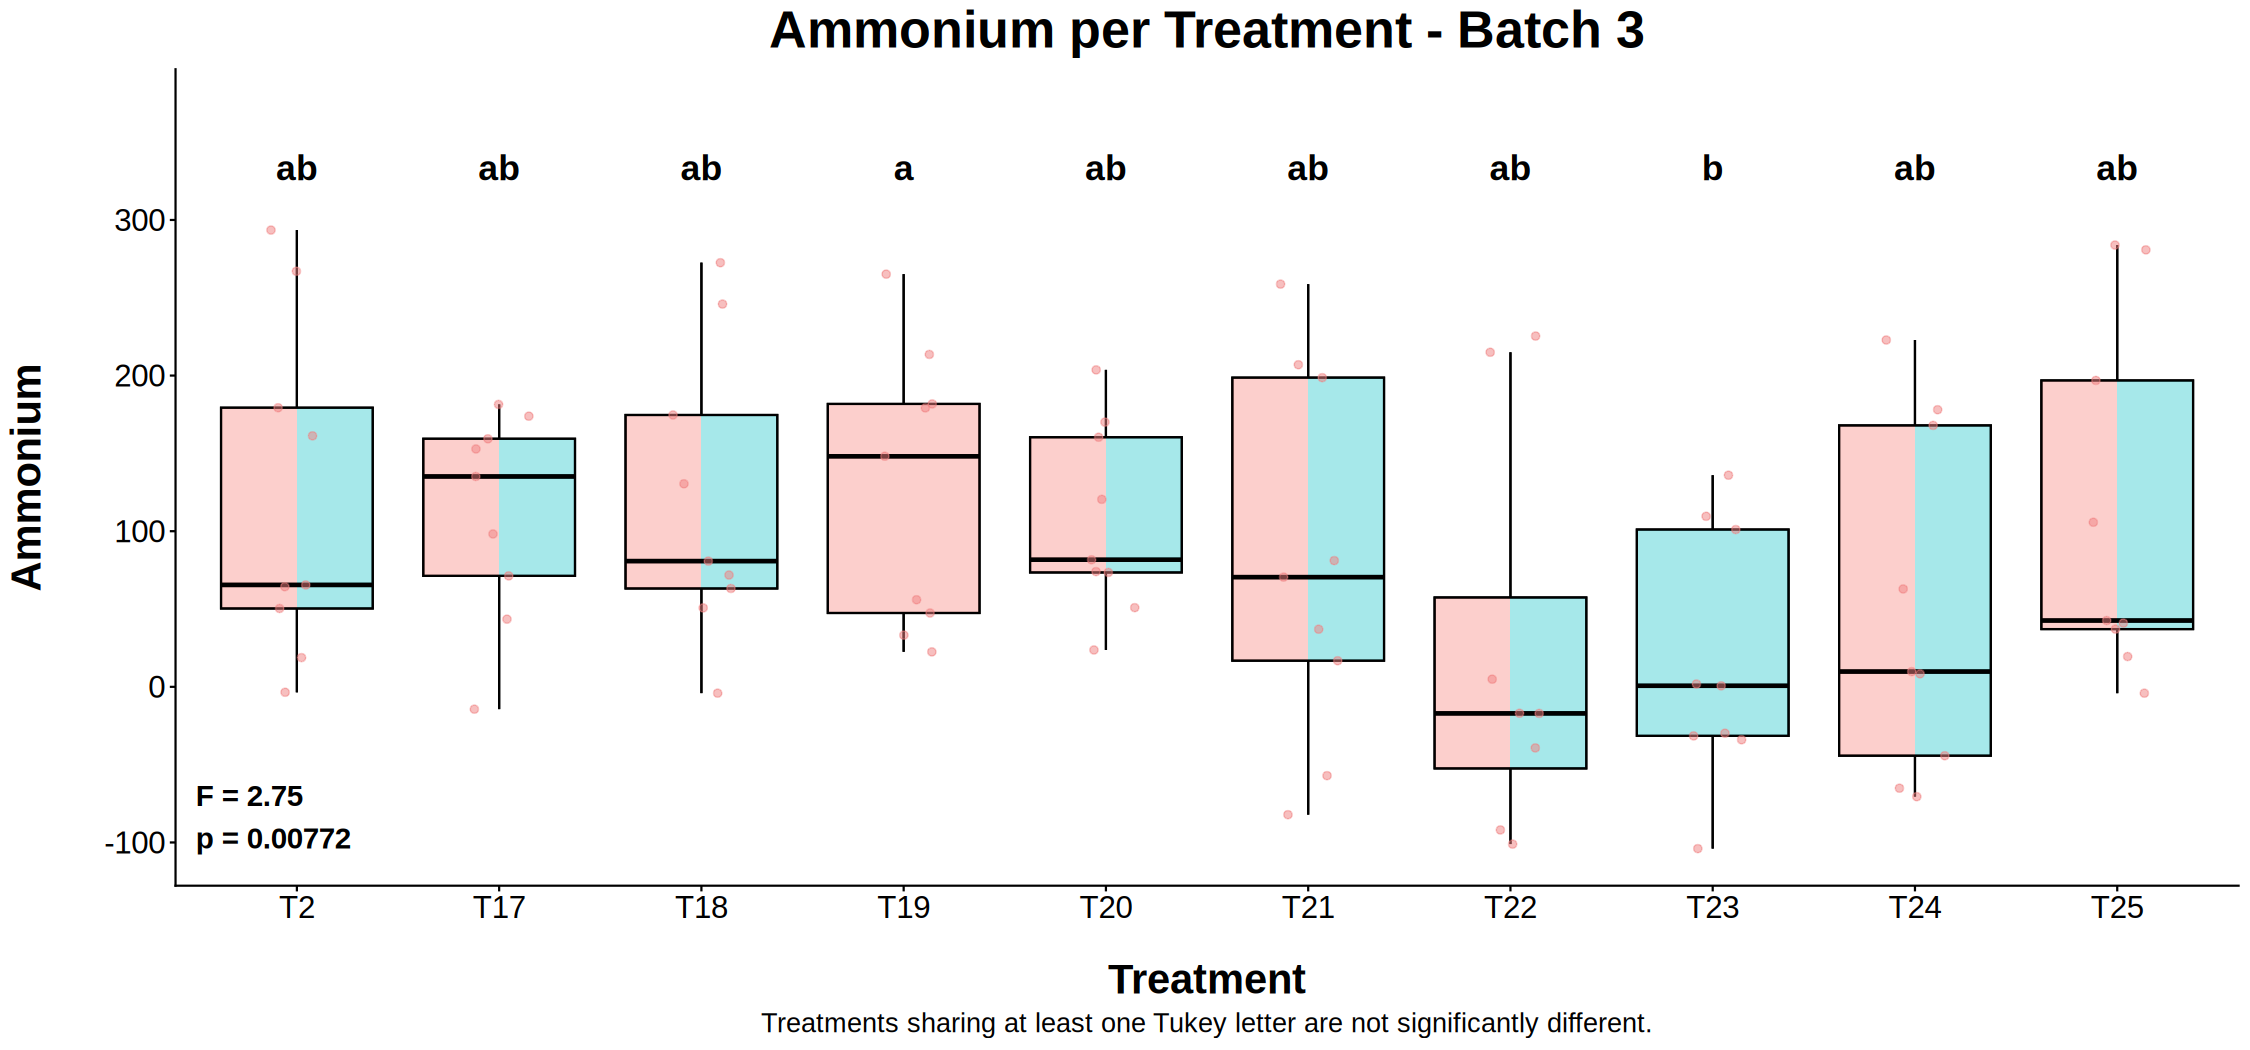

In [2360]:
result_batch_3_ammonium <- plot_anova_treatment(
  data = batch_3,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 3",
  y_label = "Ammonium"
)

### 5.3.4 Batch 4

In [2361]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Ammonium per Treatment - Batch 4 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF F_value p_value
1 Treatment 155115.6 22159.37 7     61    2.161   0.0503 
  -> Treatment effect is not significant (p > 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev 
1 Batch    16154.52 127.1004
2 Residual 10254.64 101.2652

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 41.344 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9768   p = 0.212
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(7, 63) = 1.0529   p = 0.404
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment    Mean Tukey_Group
        T2 121.842           a
       T26  40.164           a
       T27  56.353           a
       T28 138.125           a


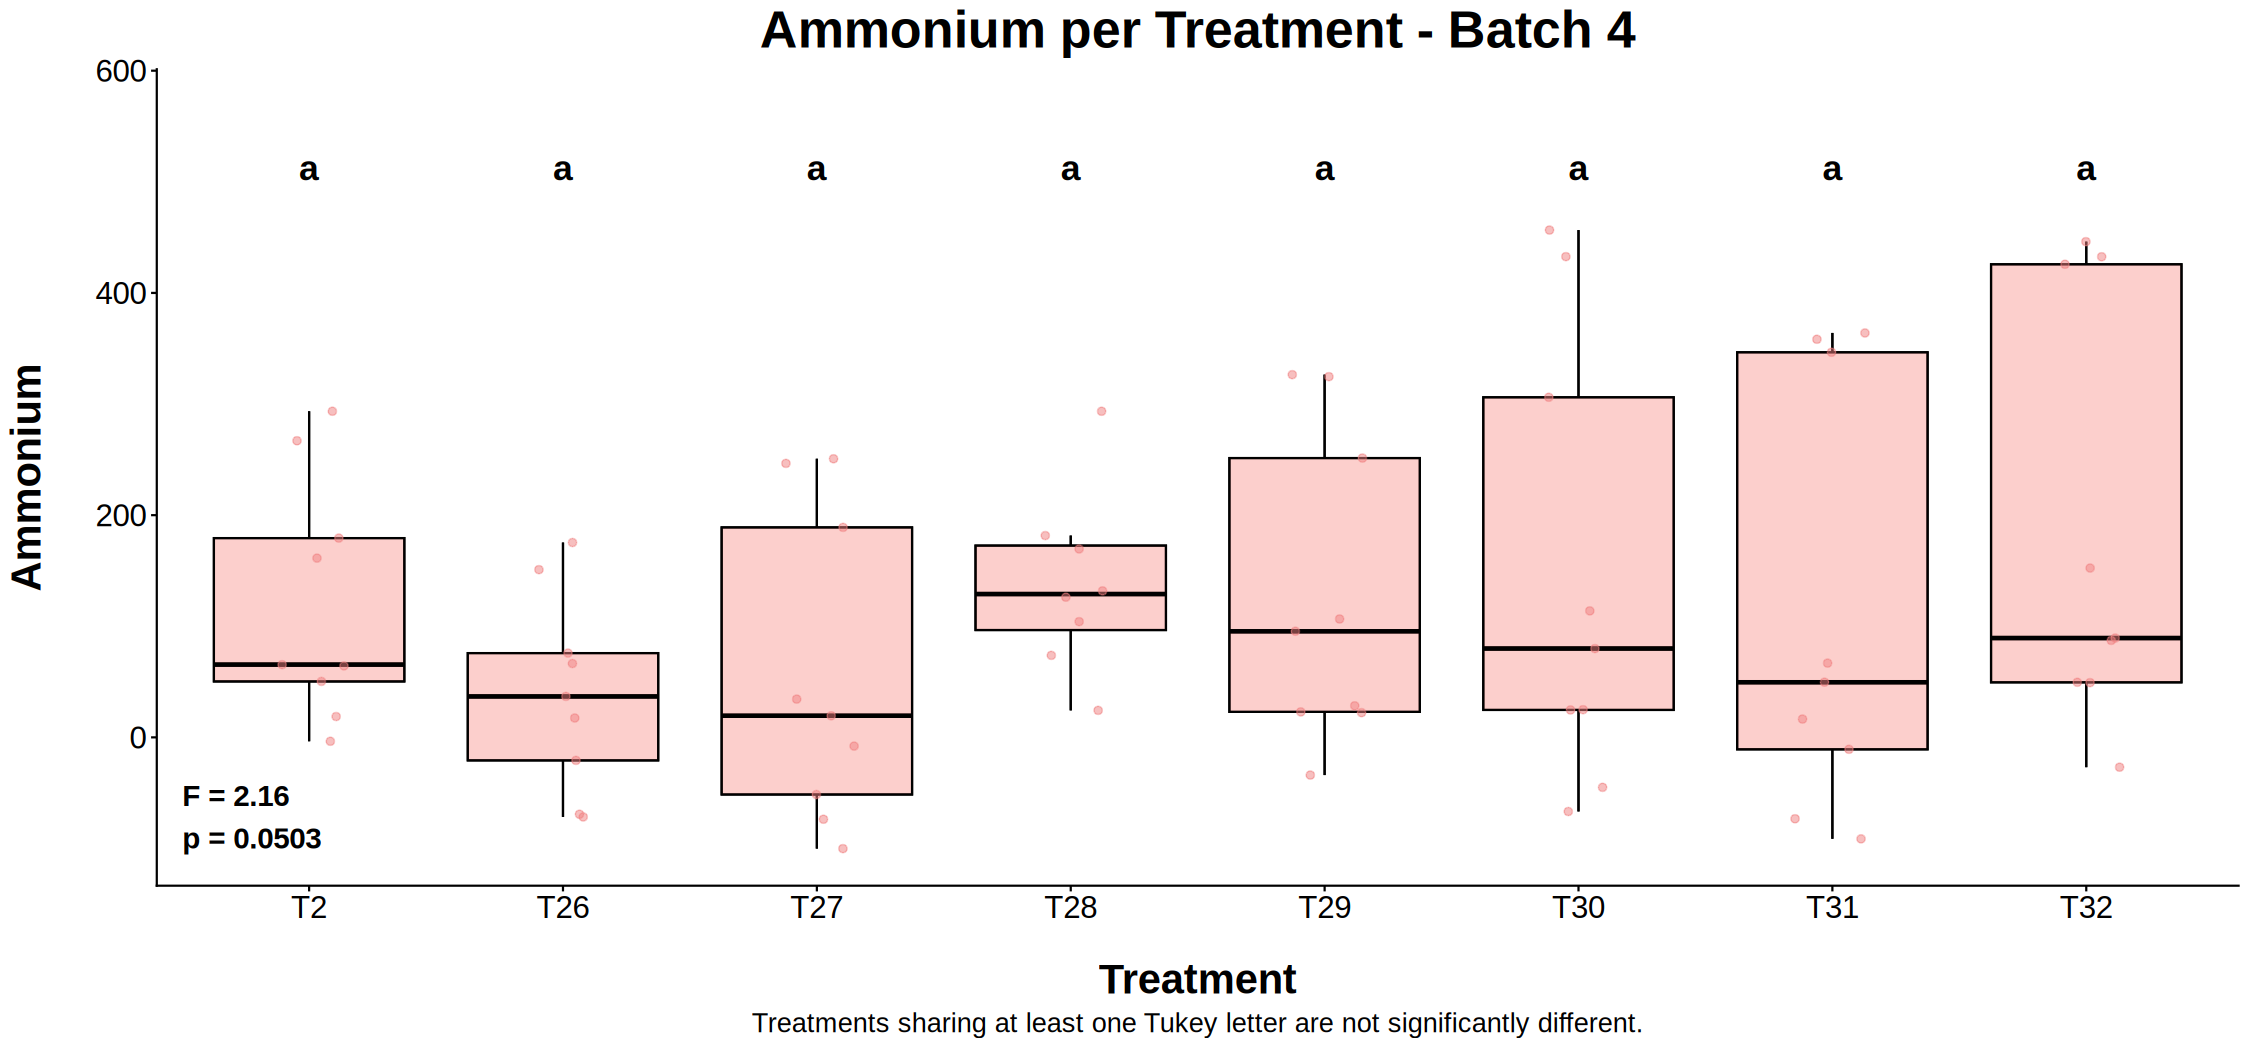

In [2362]:
result_batch_4_ammonium <- plot_anova_treatment(
  data = batch_4,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 4",
  y_label = "Ammonium"
)

## 5.4 pH

### 5.4.1 Batch 1

In [2363]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: pH per Treatment - Batch 1 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq  MeanSq NumDF DenDF F_value p_value
1 Treatment 0.0571 0.0041 14    118   0.674   0.796  
  -> Treatment effect is not significant (p > 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    0.0050   0.0710 
2 Residual 0.0061   0.0778 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 50.964 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9775   p = 0.0248
  -> Normality is rejected (p <= 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(14, 120) = 0.6307   p = 0.835
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment  Mean Tukey_Group
        T2 7.277           a
        T3 7.292           a
        T4 7.259           a
        T5 7.282           a
        T6 7.280           

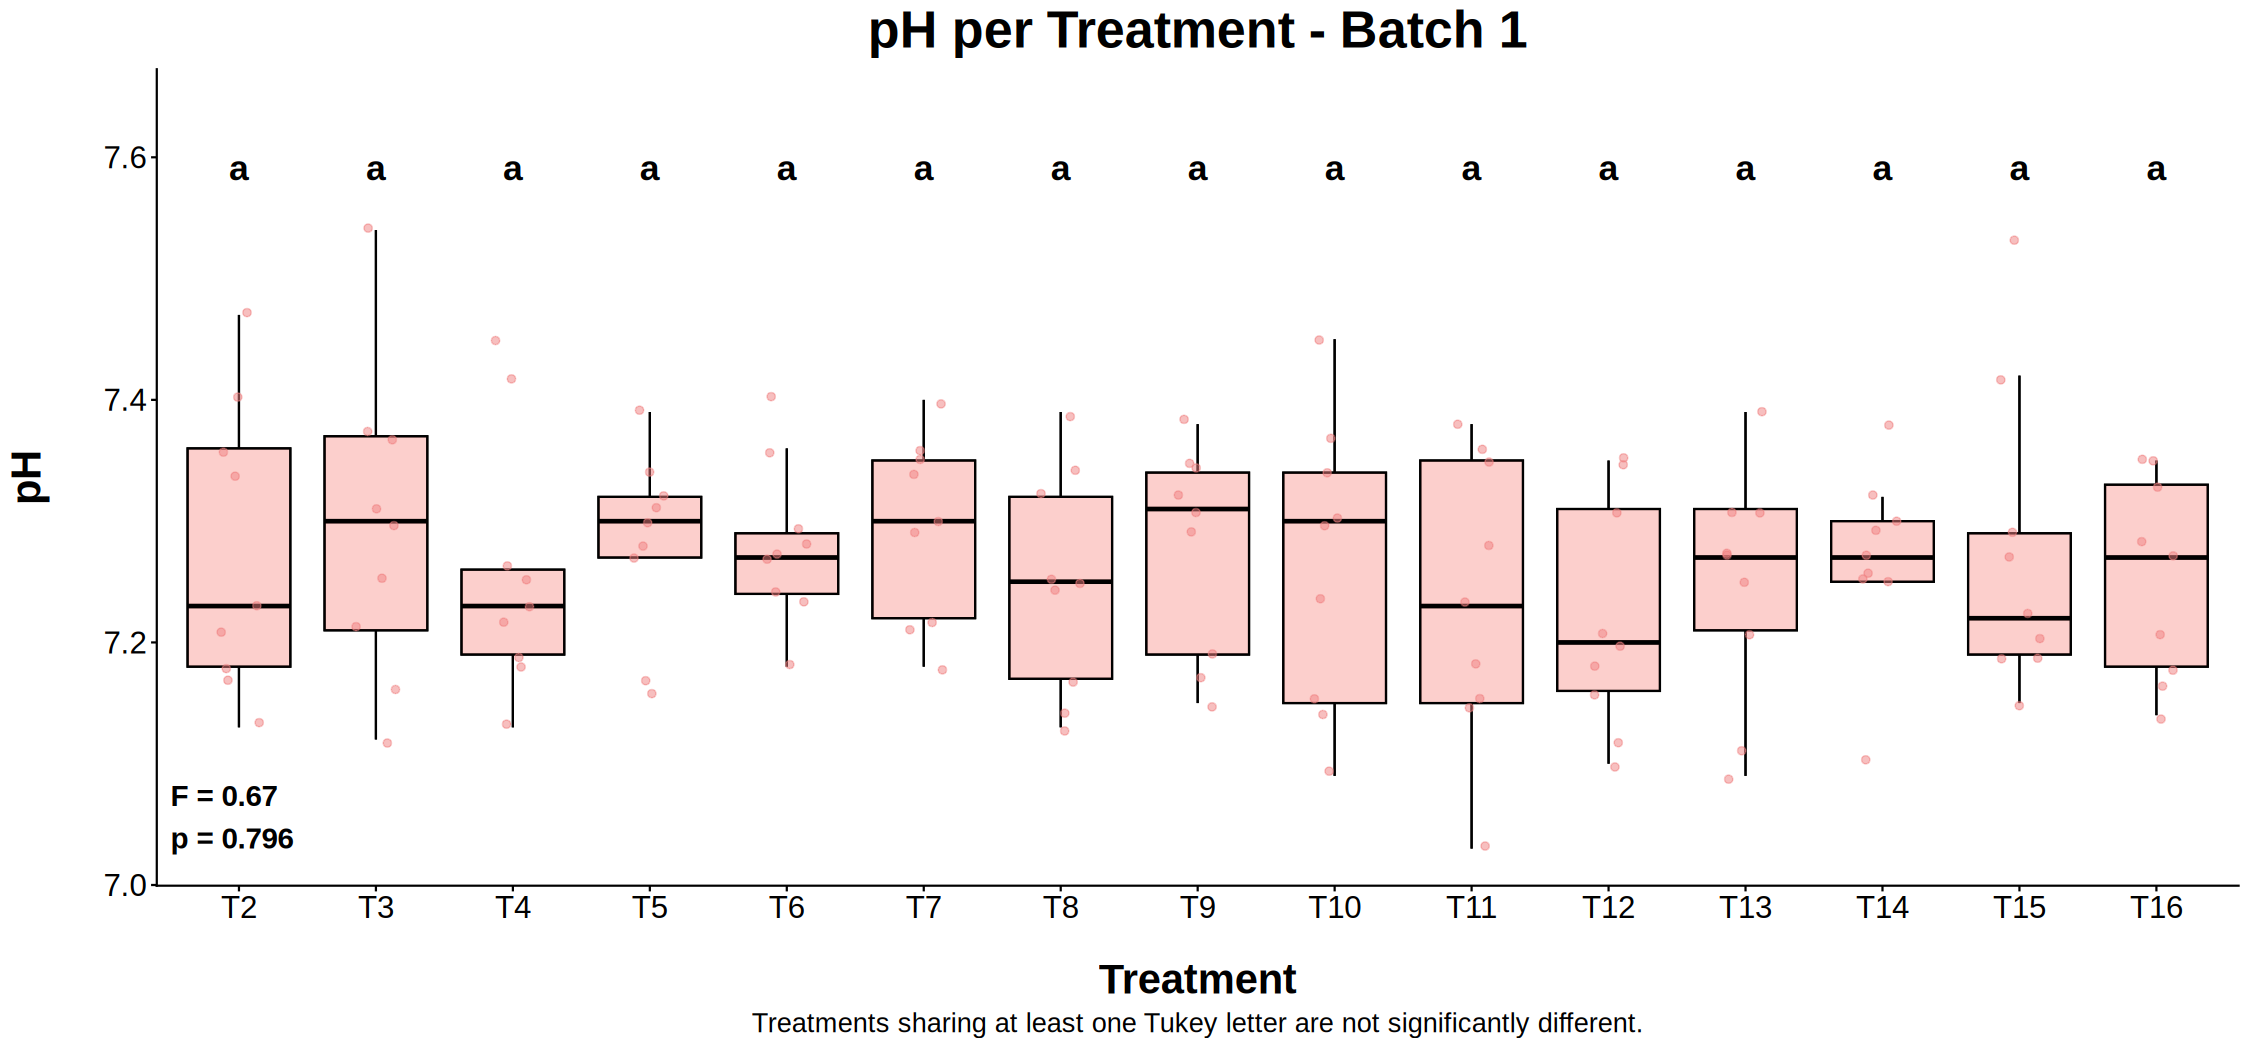

In [2364]:
result_batch_1_pH <- plot_anova_treatment(
  data = batch_1,
  variable = "pH",
  title = "pH per Treatment - Batch 1",
  y_label = "pH"
)

### 5.4.2 Batch 2

In [2365]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: pH per Treatment - Batch 2 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq  MeanSq NumDF DenDF F_value p_value
1 Treatment 0.3182 0.0199 16    134   2.681   0.00106
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    0.0124   0.1114 
2 Residual 0.0074   0.0861 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT     Df p_value
1 (1 | Batch) 101.683 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9927   p = 0.625
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(16, 136) = 1.8982   p = 0.0254
  -> Homogeneity of variances is rejected (p <= 0.05)

--- TUKEY GROUPS ---

 Treatment  Mean Tukey_Group
        T2 7.277          ab
       T17 7.284          ab
       T18 7.263          ab
       T19 7.194           a
       T20 7.187           a

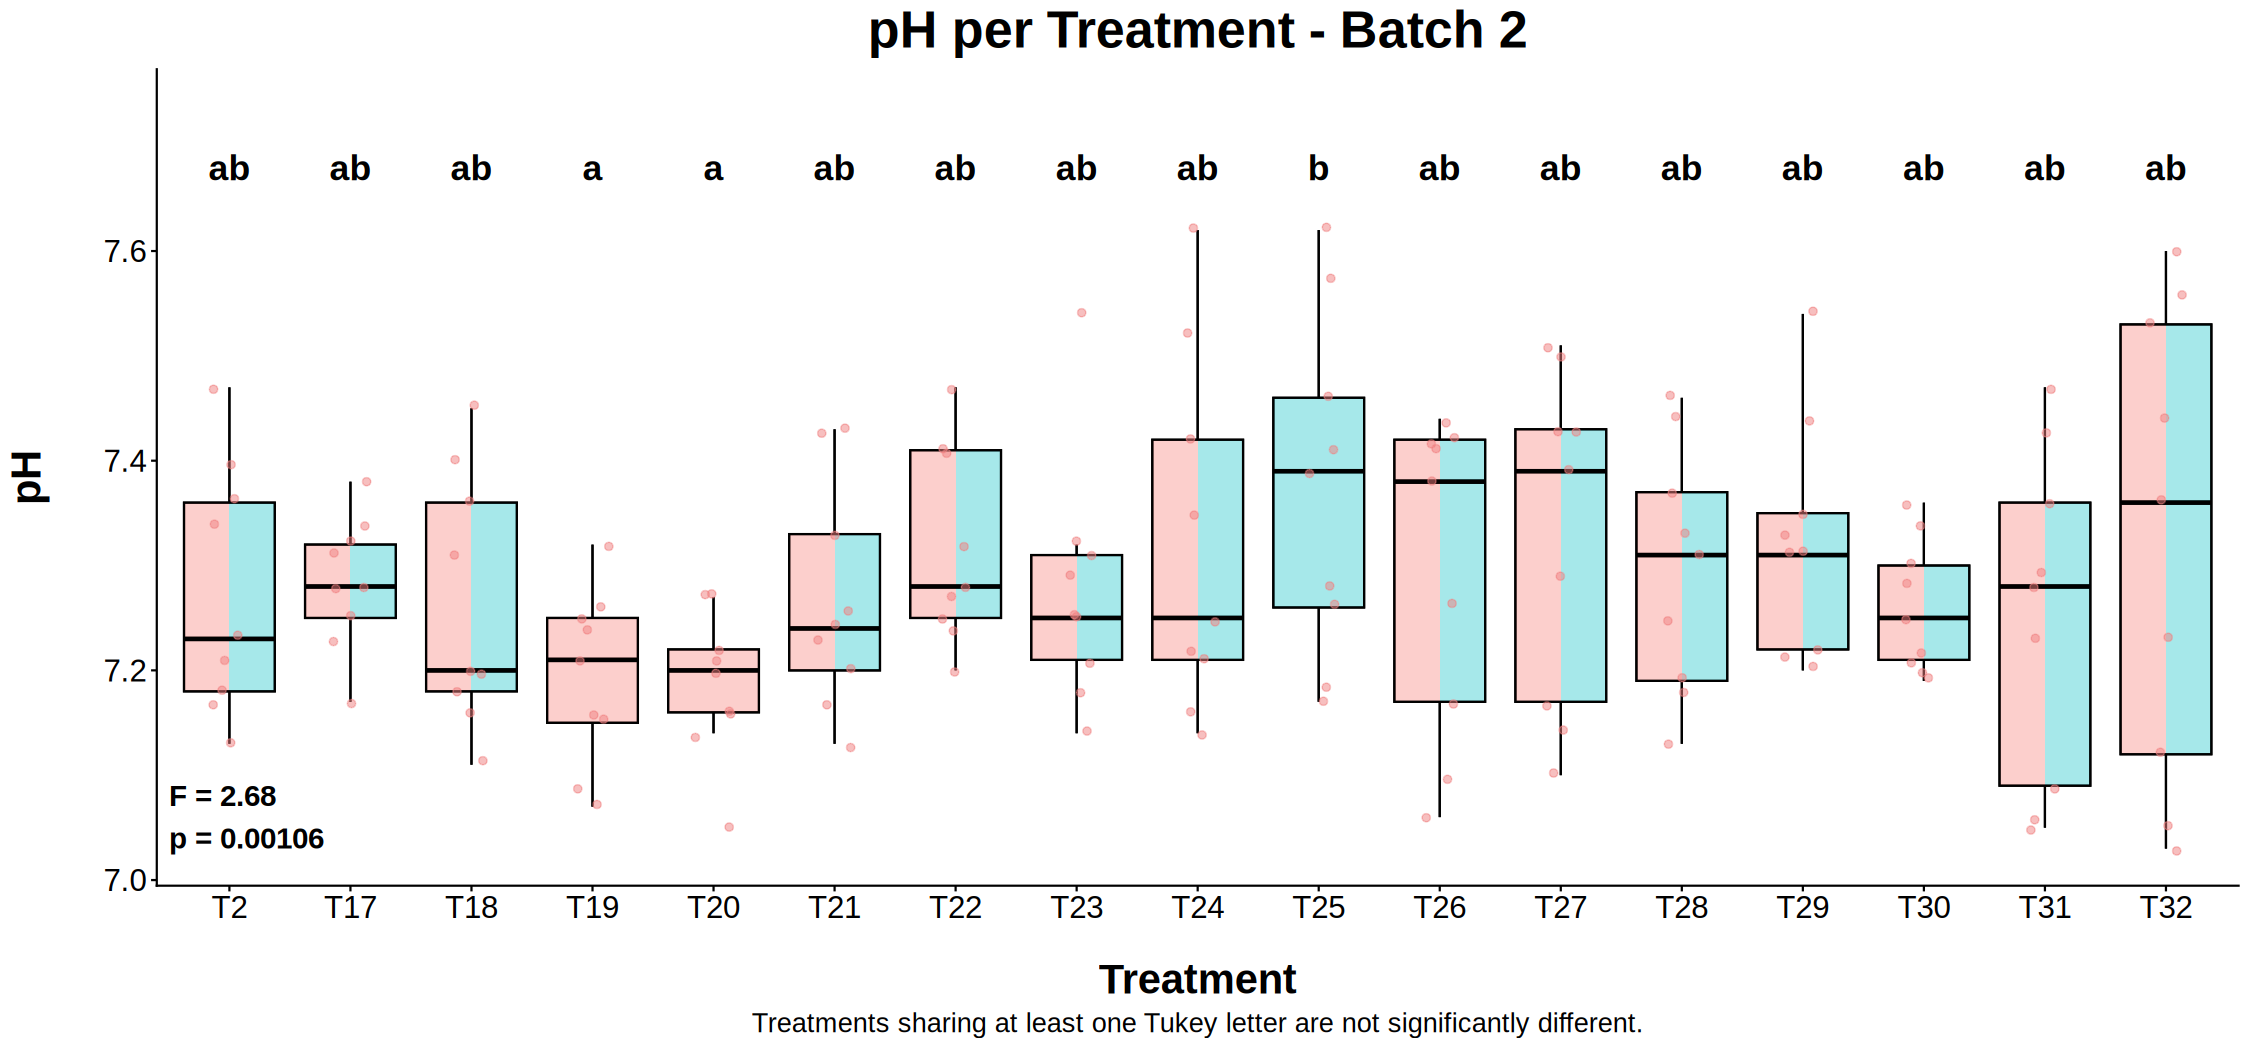

In [2366]:
result_batch_2_pH <- plot_anova_treatment(
  data = batch_2,
  variable = "pH",
  title = "pH per Treatment - Batch 2",
  y_label = "pH"
)

### 5.4.3 Batch 3

In [2367]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: pH per Treatment - Batch 3 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq  MeanSq NumDF DenDF F_value p_value
1 Treatment 0.2488 0.0276 9     78    3.972   <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    0.0083   0.0909 
2 Residual 0.0070   0.0834 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 43.717 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9842   p = 0.345
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(9, 80) = 1.3050   p = 0.248
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment  Mean Tukey_Group
        T2 7.277         abc
       T17 7.284         abc
       T18 7.263         abc
       T19 7.194          ab
       T20 7.187           a
 

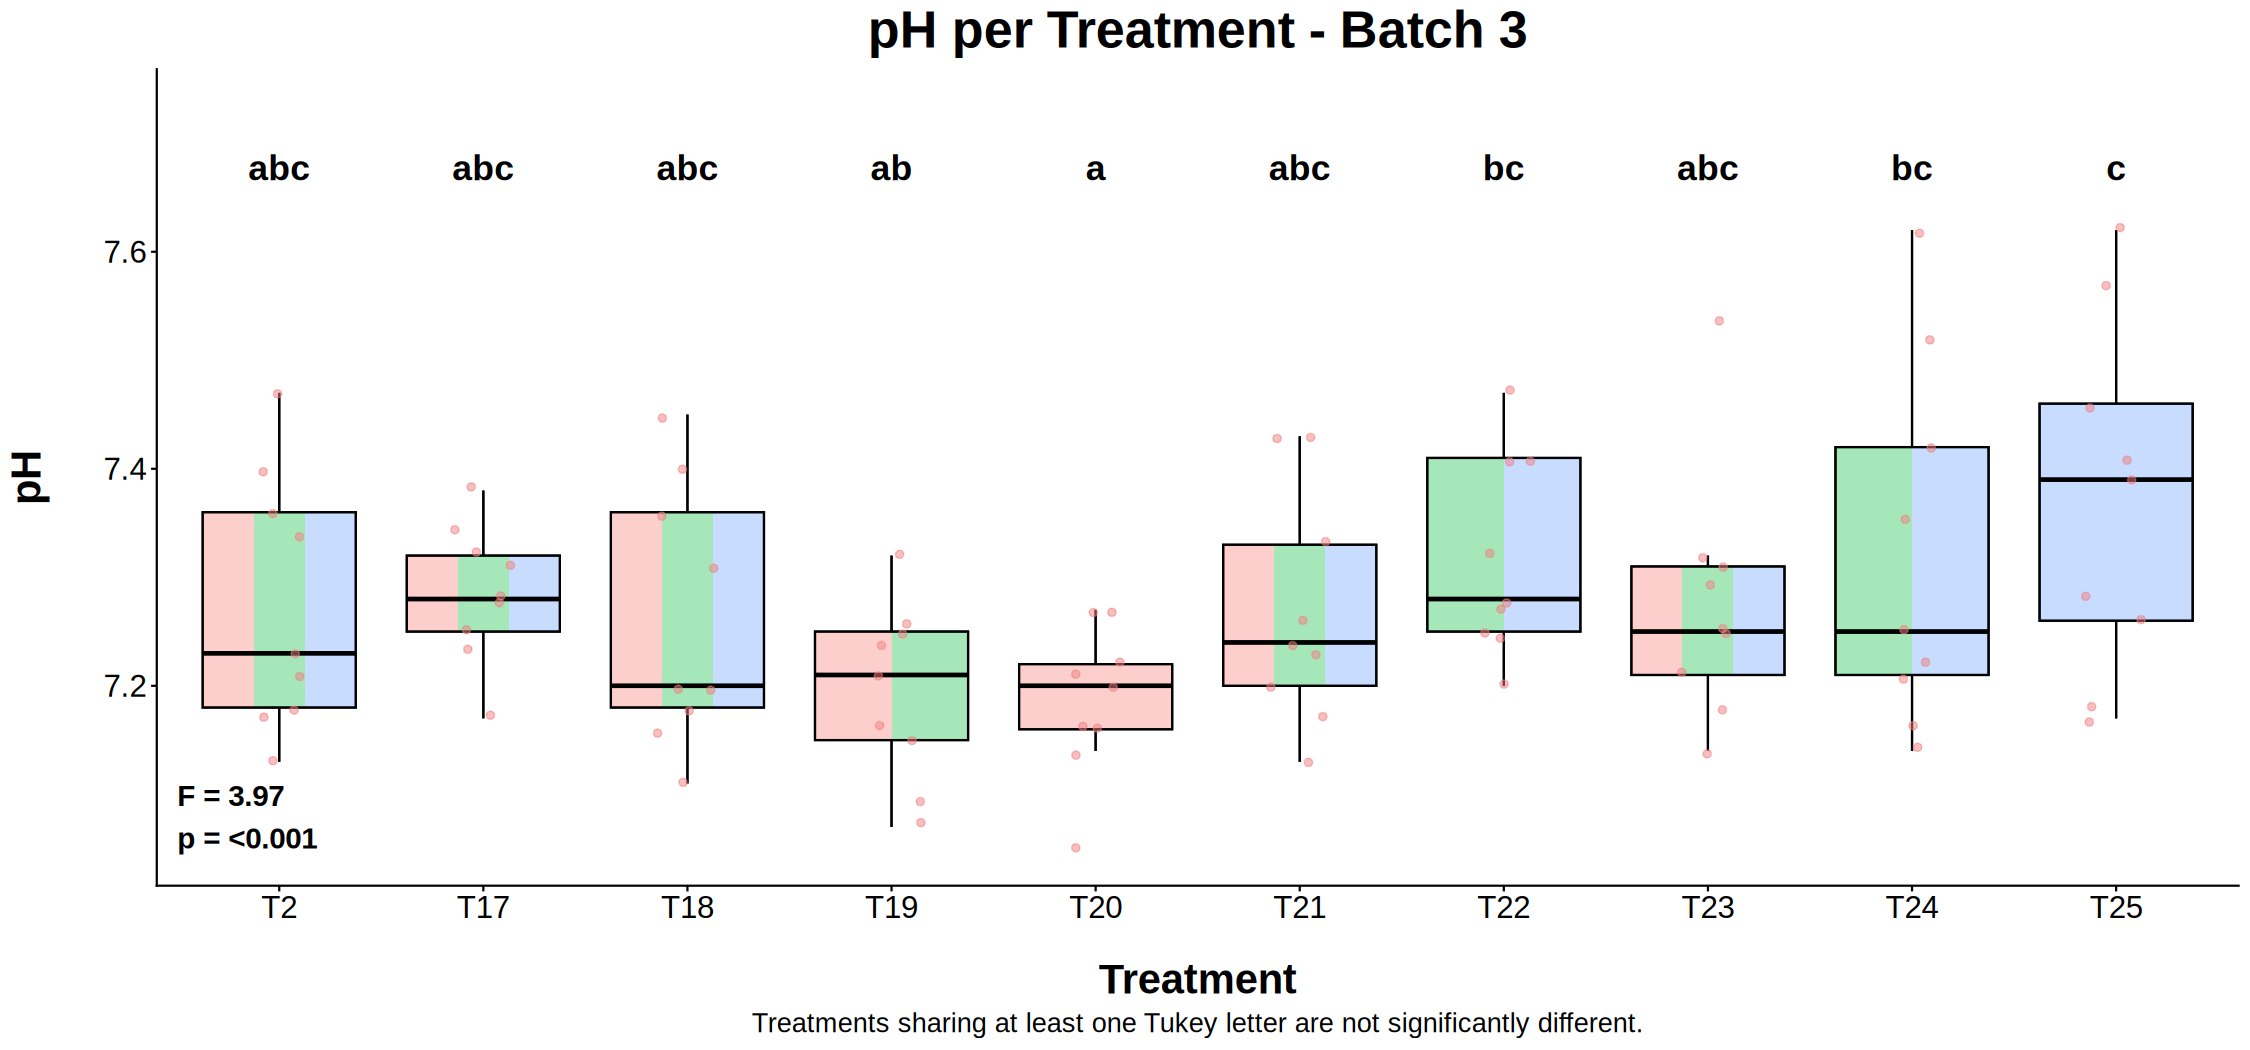

In [2368]:
result_batch_3_pH <- plot_anova_treatment(
  data = batch_3,
  variable = "pH",
  title = "pH per Treatment - Batch 3",
  y_label = "pH"
)

### 5.3.4  Batch 4

In [2369]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: pH per Treatment - Batch 4 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq  MeanSq NumDF DenDF F_value p_value
1 Treatment 0.0561 0.008  7     62    1.233   0.299  
  -> Treatment effect is not significant (p > 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    0.0192   0.1384 
2 Residual 0.0065   0.0806 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 66.137 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9882   p = 0.739
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(7, 64) = 2.0046   p = 0.0681
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment  Mean Tukey_Group
        T2 7.277           a
       T26 7.296           a
       T27 7.329           a
       T28 7.296           a
       T29 7.323          

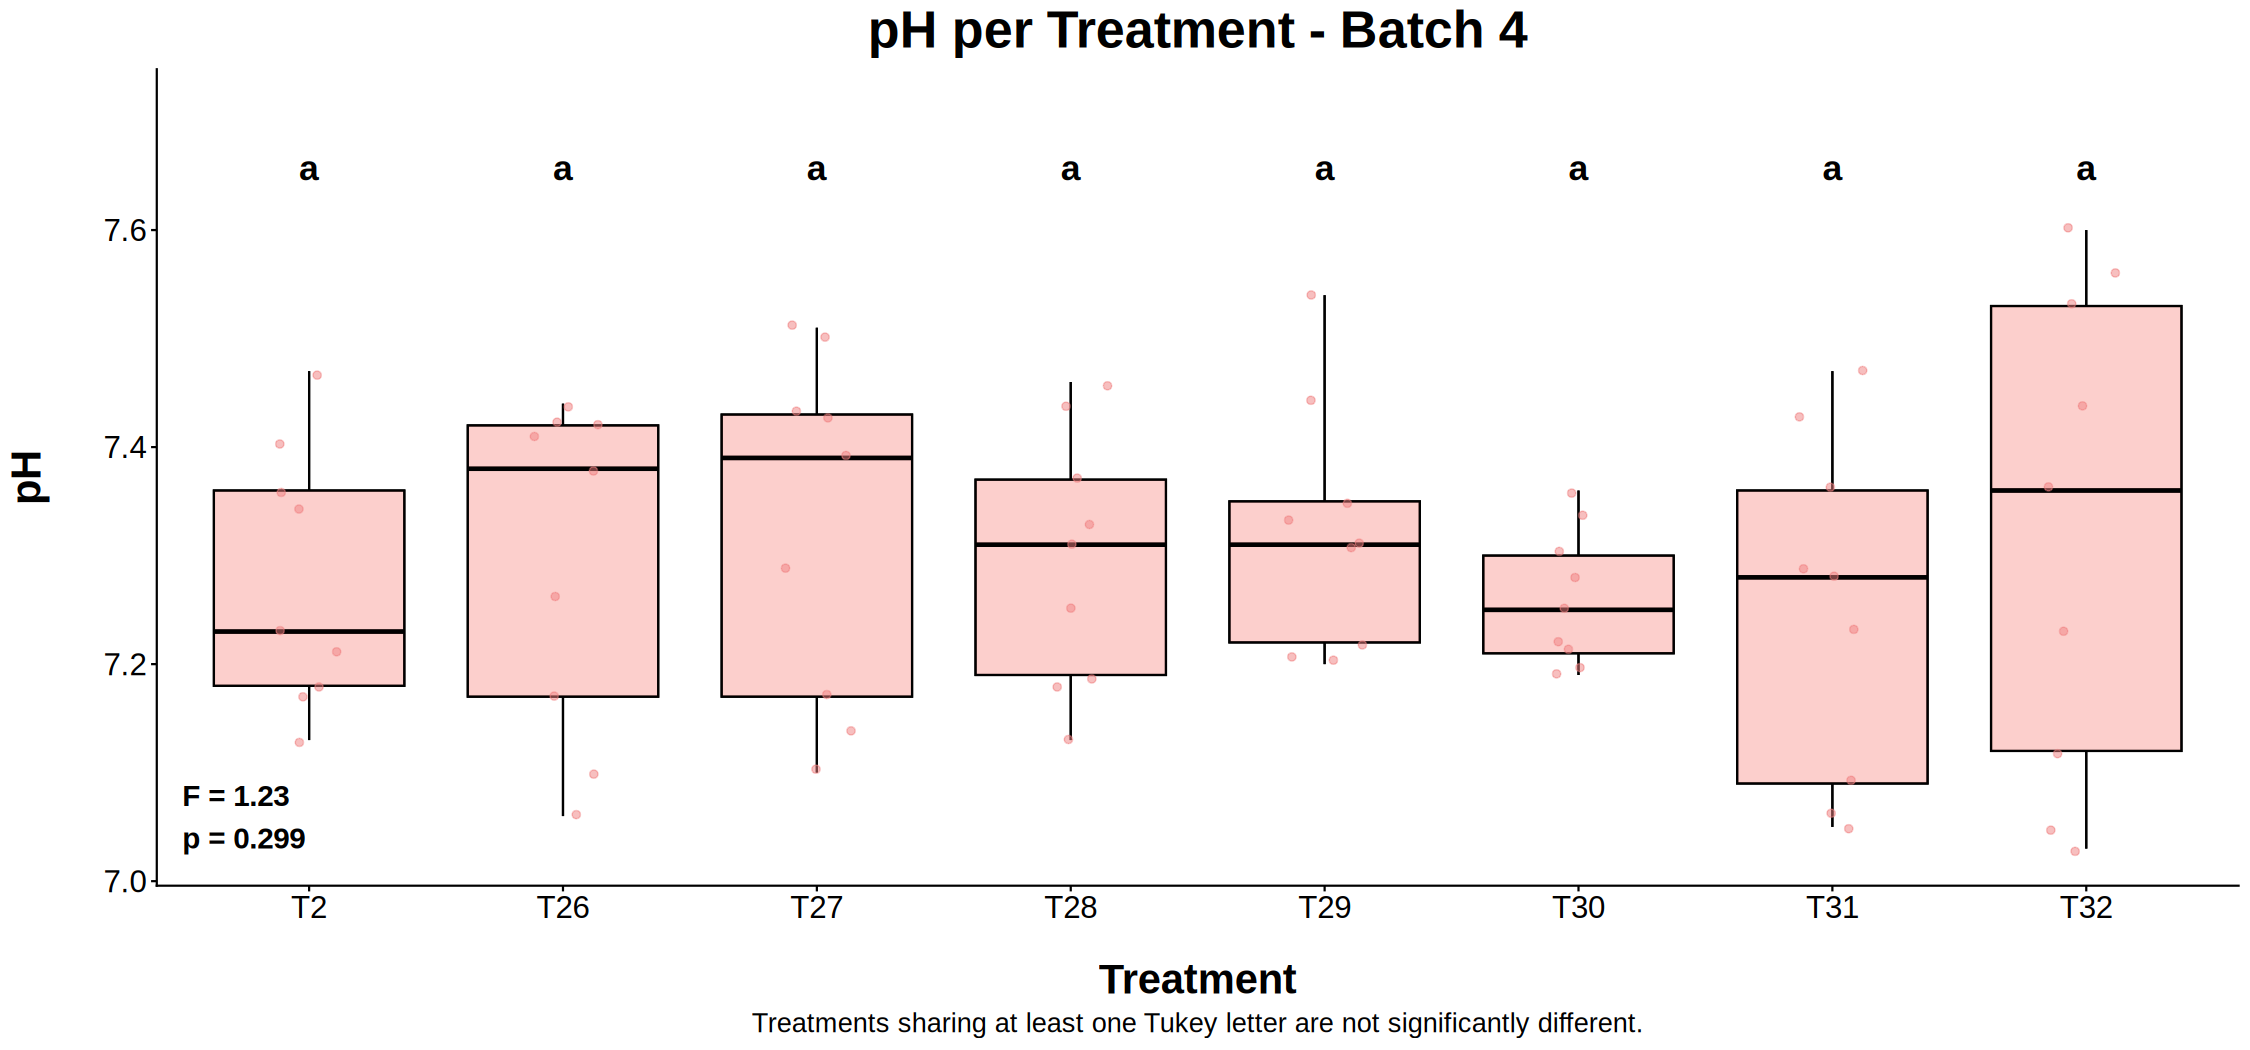

In [2370]:
result_batch_4_pH <- plot_anova_treatment(
  data = batch_4,
  variable = "pH",
  title = "pH per Treatment - Batch 4",
  y_label = "pH"
)

# 6.0 Averaged data

## 6.1 Batch 1

In [2371]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"

In [2372]:
batch_1_table <- batch_1 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_1_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T3,56.66,64.78,288.49,7.29
T4,51.32,68.29,193.50,7.26
T5,55.33,67.10,106.86,7.28
T6,58.67,63.98,146.22,7.28
T7,57.77,64.22,130.52,7.29
T8,54.86,65.67,190.84,7.25
T9,54.62,64.02,233.16,7.28
T10,54.59,66.14,175.02,7.26


## 6.2 Batch 2

In [2373]:
batch_2_table <- batch_2 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_2_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T17,49.21,68.63,111.28,7.28
T18,44.56,68.52,120.70,7.26
T19,49.07,69.28,127.45,7.19
T20,47.32,69.99,106.49,7.19
T21,44.89,66.23,81.19,7.27
T22,48.20,68.97,22.36,7.32
T23,37.82,66.42,16.64,7.28
T24,52.16,69.80,52.23,7.32


## 6.3 Batch 3

In [2374]:
batch_3_table <- batch_3 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_3_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T17,49.21,68.63,111.28,7.28
T18,44.56,68.52,120.70,7.26
T19,49.07,69.28,127.45,7.19
T20,47.32,69.99,106.49,7.19
T21,44.89,66.23,81.19,7.27
T22,48.20,68.97,22.36,7.32
T23,37.82,66.42,16.64,7.28
T24,52.16,69.80,52.23,7.32


## 6.4 Batch 4

In [2375]:
batch_4_table <- batch_4 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_4_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T26,48.33,69.66,40.16,7.30
T27,25.58,67.89,56.35,7.33
T28,48.30,68.30,138.12,7.30
T29,50.78,66.76,127.15,7.32
T30,44.59,65.46,147.45,7.26
T31,53.60,64.20,114.06,7.25
T32,33.61,65.04,189.51,7.32


# 8.0 All treatments comparison

In [2382]:
df2 <- df %>% filter(!Treatment %in% c("T34", "T35", "T36"))

## 8.1 TDDM %

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: TDDM (%) per Treatment - All Treatments 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq NumDF DenDF F_value p_value
1 Treatment 2362.668 71.596 33    265   7.24    <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    3.0990   1.7604 
2 Residual 9.8892   3.1447 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 49.439 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9722   p = <0.001
  -> Normality is rejected (p <= 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(33, 267) = 0.6763   p = 0.912
  -> Homogeneity of variances is not rejected (p > 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T0 77.900           a
        T1 60.533           b
        T2 66.822          cd
        T3 64.778         bcd
        

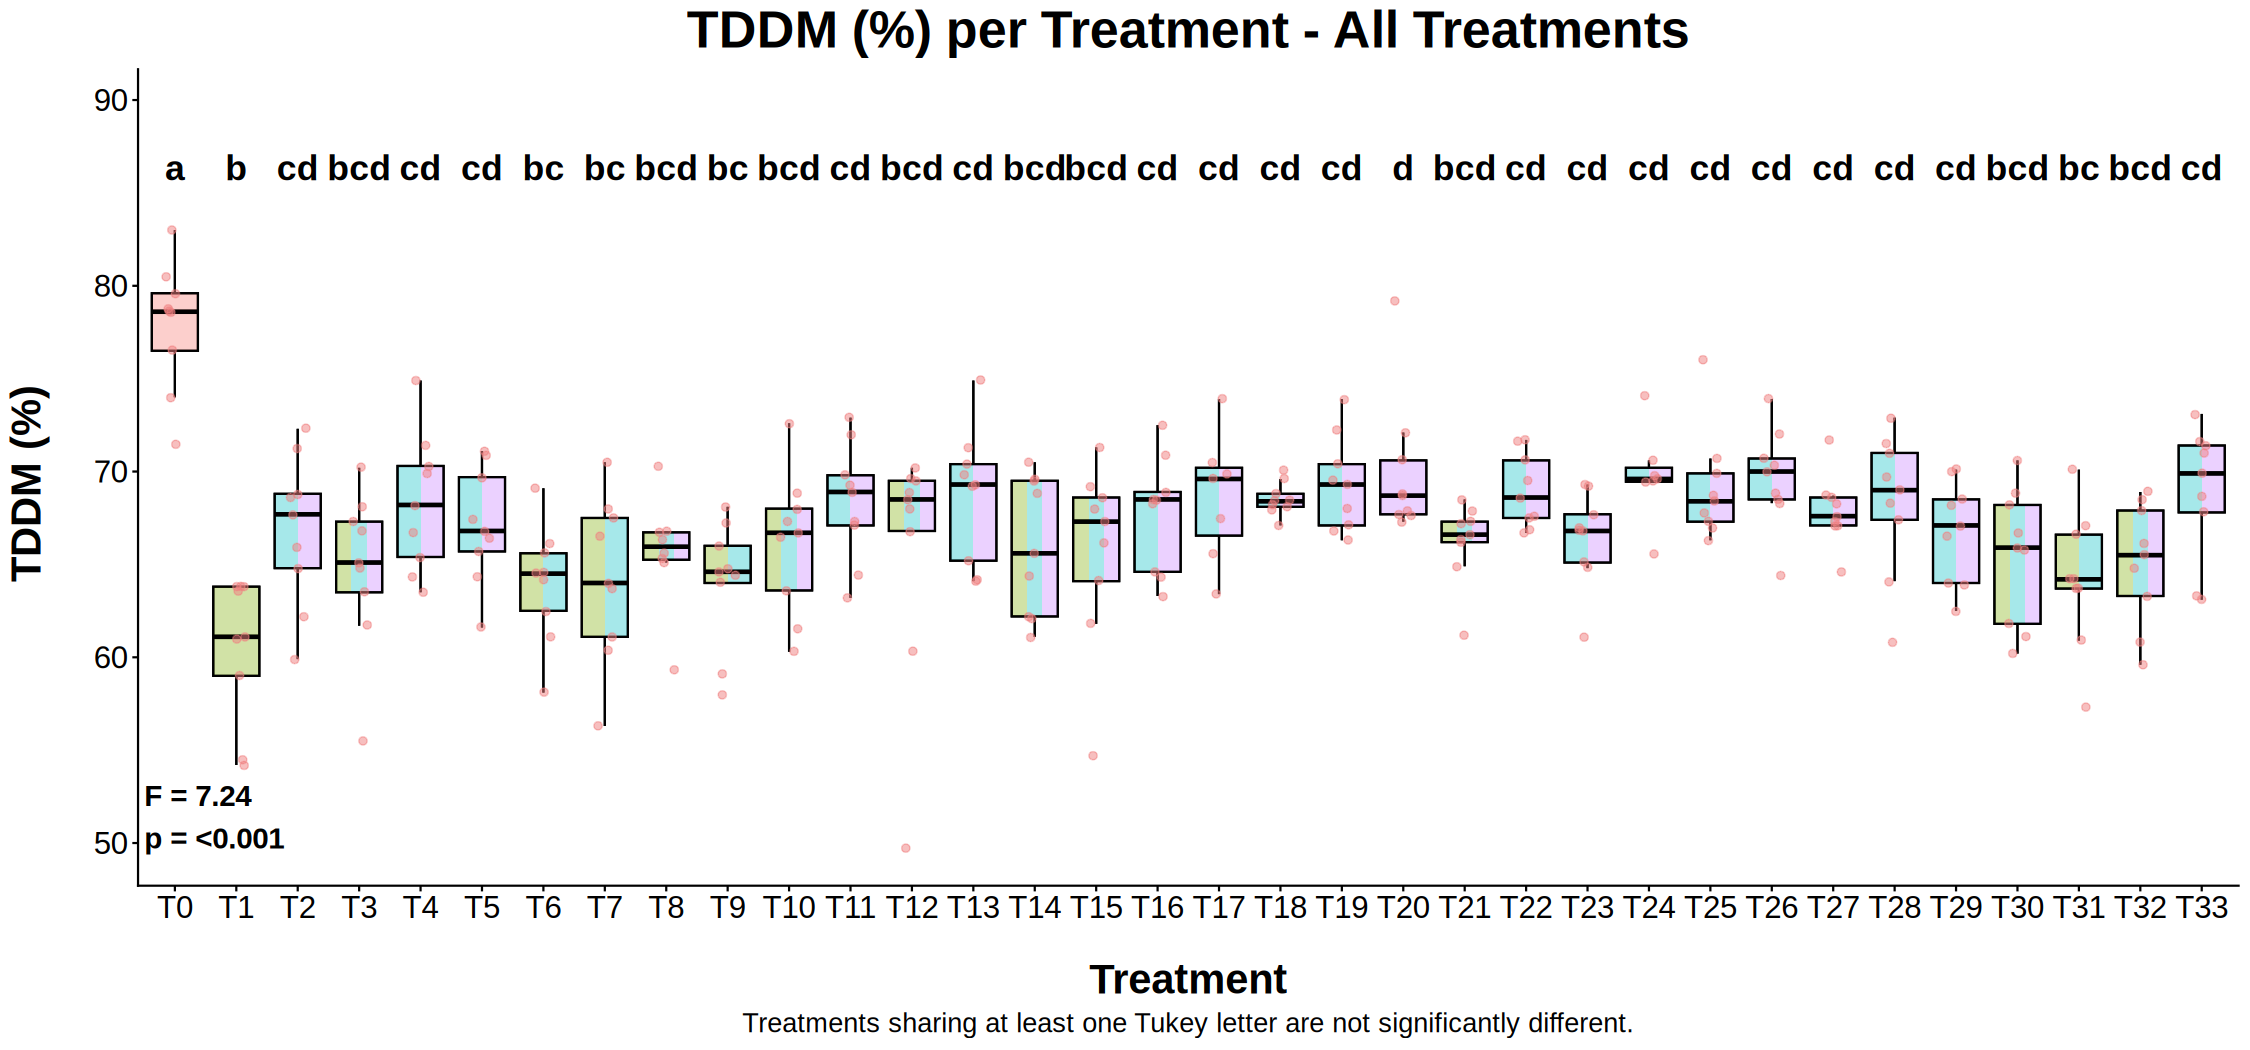

In [2383]:
result_all_tddm <- plot_anova_treatment(
  data = df2,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - All Treatments",
  y_label = "TDDM (%) "
)

## 8.2 Methane intensity

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Methane Intensity per Treatment - All Treatments 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq    MeanSq   NumDF DenDF F_value p_value
1 Treatment 15110.51 457.8941 33    265   20.954  <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    13.6141  3.6897 
2 Residual 21.8527  4.6747 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 94.237 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9804   p = <0.001
  -> Normality is rejected (p <= 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(33, 267) = 1.9027   p = 0.00309
  -> Homogeneity of variances is rejected (p <= 0.05)

--- TUKEY GROUPS ---

 Treatment   Mean Tukey_Group
        T0 57.356         abc
        T1 47.000         def
        T2 56.344       abcgh
        T3 56.656        a

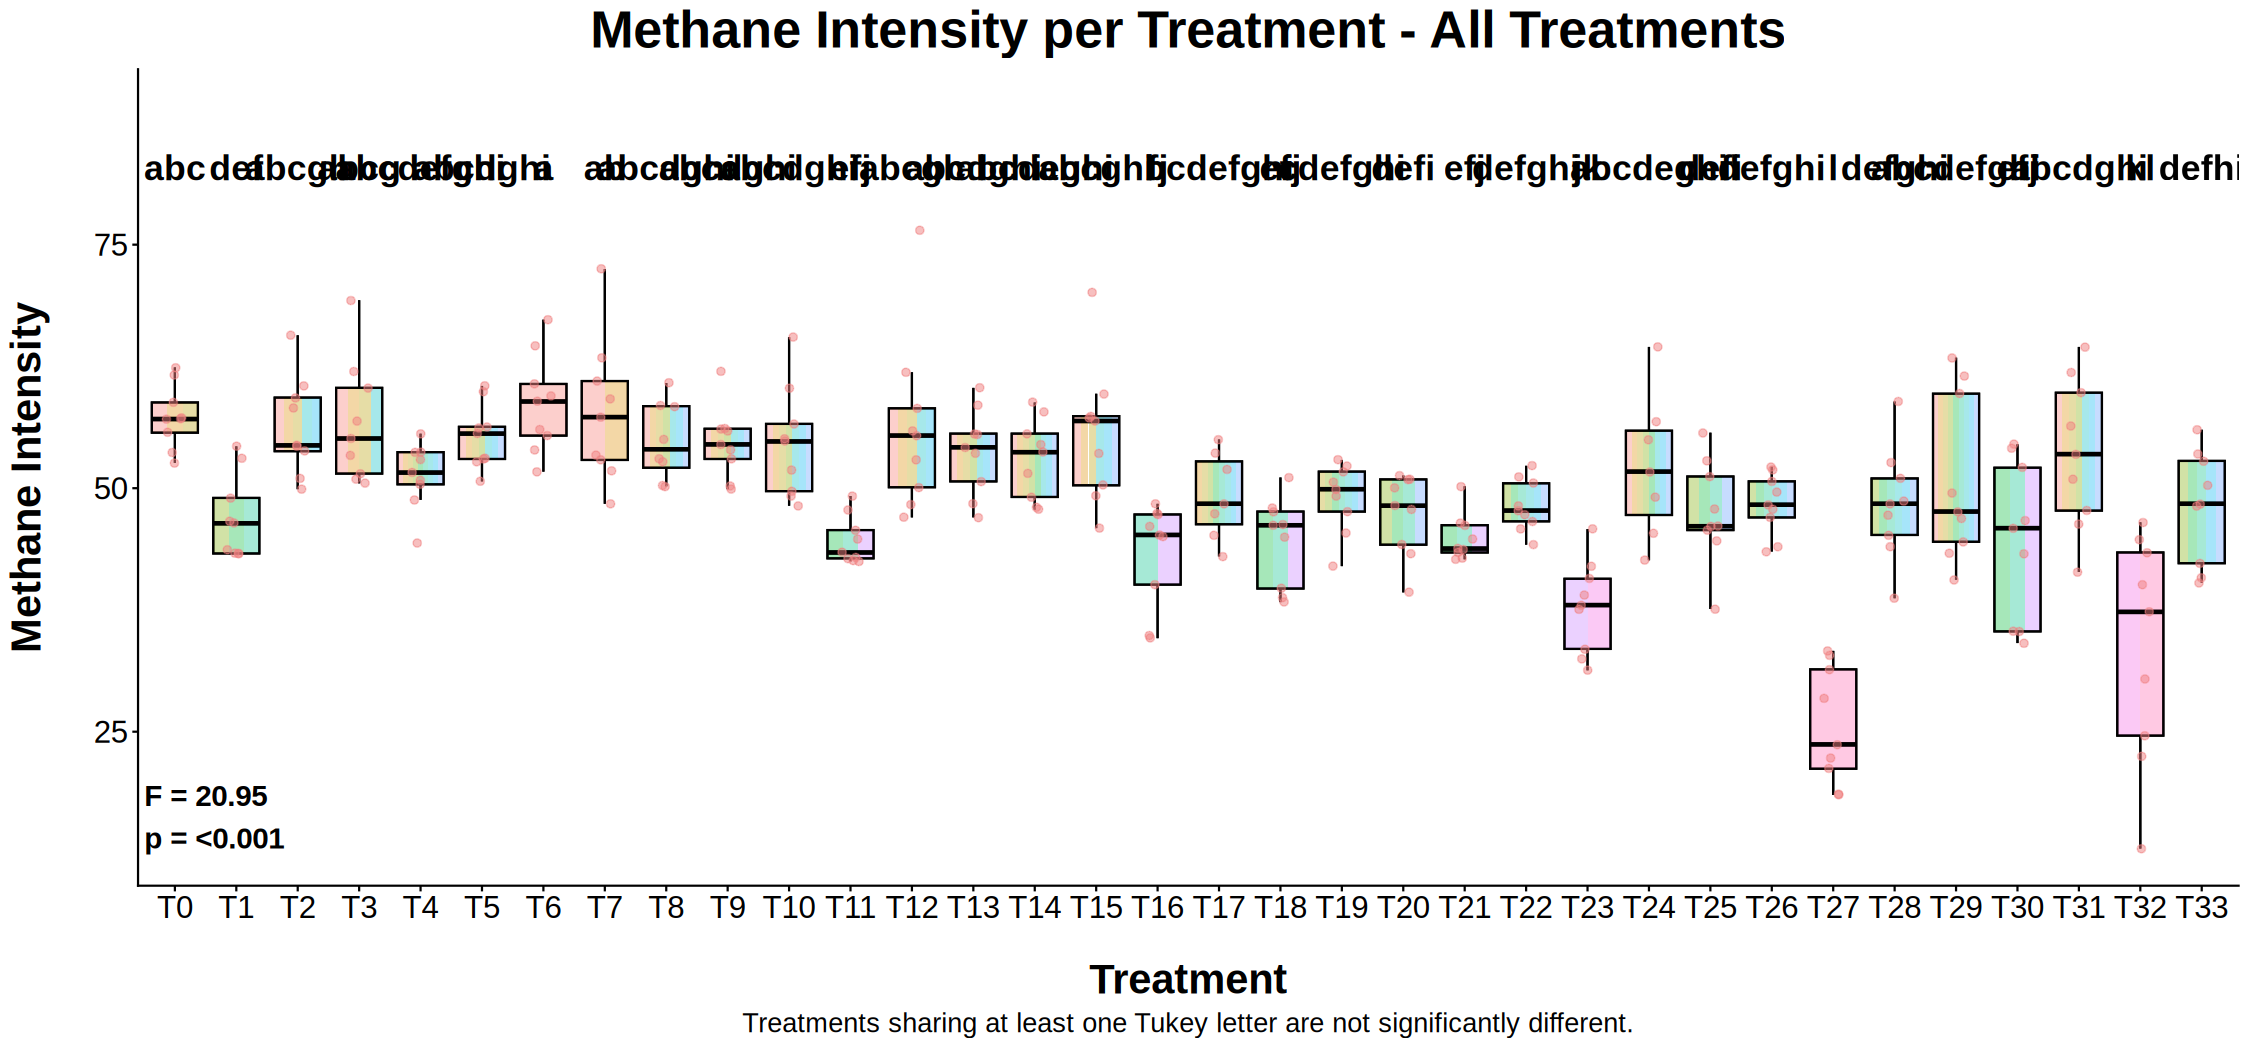

In [2384]:
result_all_methane_intensity <- plot_anova_treatment(
  data = df2,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - All Treatments",
  y_label = "Methane Intensity"
)

## 8.3 Ammonium

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: Ammonium per Treatment - All Treatments 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq   MeanSq   NumDF DenDF F_value p_value
1 Treatment 1087757 32962.34 33    268   2.838   <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance  Std_Dev 
1 Batch     2422.206  49.2159
2 Residual 11616.474 107.7797

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT    Df p_value
1 (1 | Batch) 32.861 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9944   p = 0.325
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(33, 270) = 1.5175   p = 0.0399
  -> Homogeneity of variances is rejected (p <= 0.05)

--- TUKEY GROUPS ---

 Treatment    Mean Tukey_Group
        T0  56.975          ab
        T1  97.864         abc
        T2 121.842         abc
        T3 288.486        

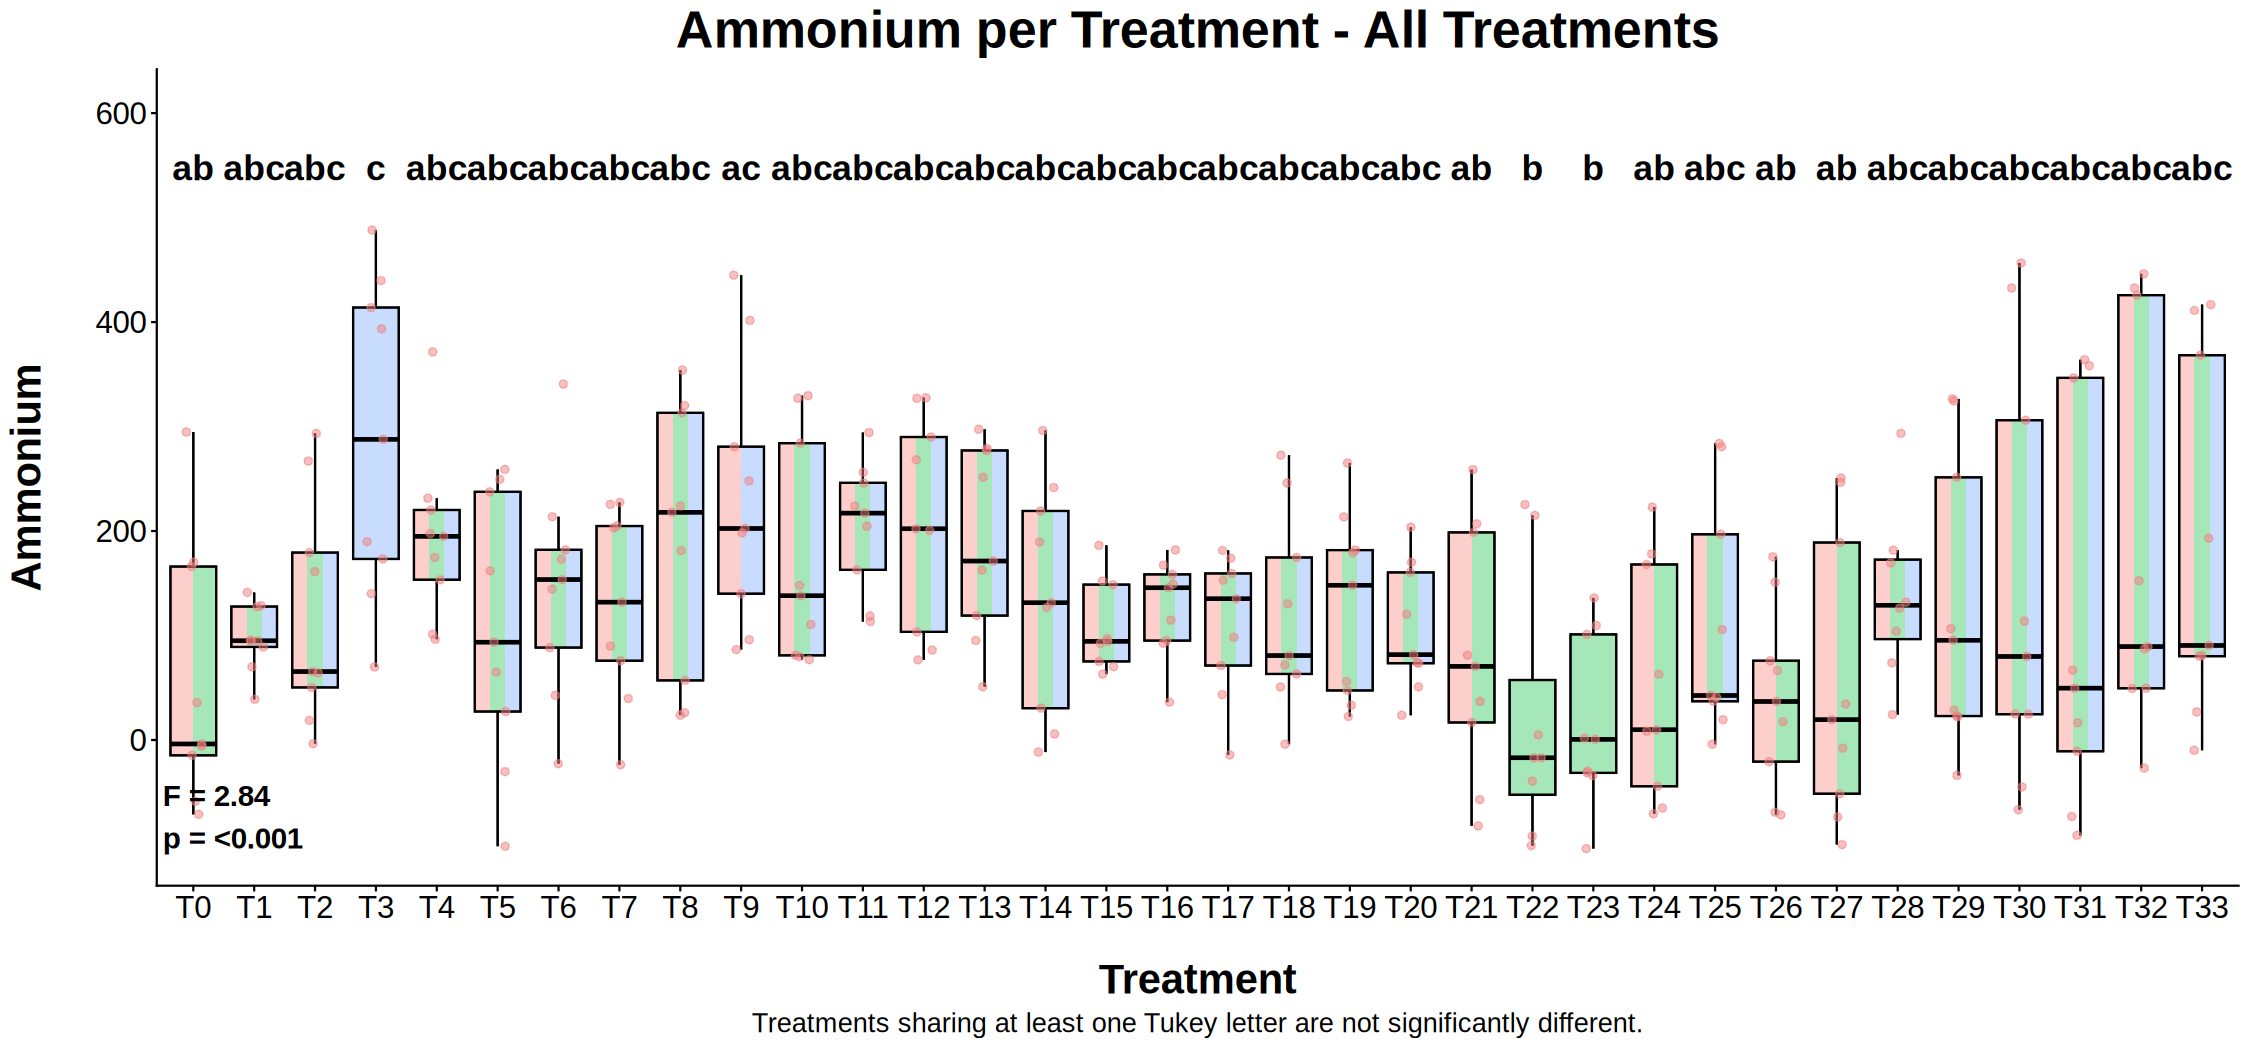

In [2385]:
result_all_ammonium <- plot_anova_treatment(
  data = df2,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - All Treatments",
  y_label = "Ammonium"
)

## 8.4 pH

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons




ANALYSIS: pH per Treatment - All Treatments 

--- ANOVA (Satterthwaite) - Fixed Effects ---

  Effect    SumSq  MeanSq NumDF DenDF F_value p_value
1 Treatment 0.6731 0.0204 33    270   2.719   <0.001 
  -> Treatment effect is significant (p <= 0.05)

--- RANDOM EFFECTS (Variance Components) ---

  Group    Variance Std_Dev
1 Batch    0.0093   0.0967 
2 Residual 0.0075   0.0866 

--- RANDOM EFFECT SIGNIFICANCE (Likelihood Ratio Test) ---

  Term        LRT     Df p_value
1 (1 | Batch) 169.812 1  <0.001 
  -> Random effect (Batch) is significant (p <= 0.05)

--- NORMALITY OF RESIDUALS (Shapiro-Wilk) ---

  W = 0.9938   p = 0.249
  -> Normality is not rejected (p > 0.05)

--- HOMOGENEITY OF VARIANCES (Levene) ---

  F(33, 272) = 1.7343   p = 0.00989
  -> Homogeneity of variances is rejected (p <= 0.05)

--- TUKEY GROUPS ---

 Treatment  Mean Tukey_Group
        T0 7.293         abc
        T1 7.440           a
        T2 7.277          bc
        T3 7.292         abc
        T4 7.259    

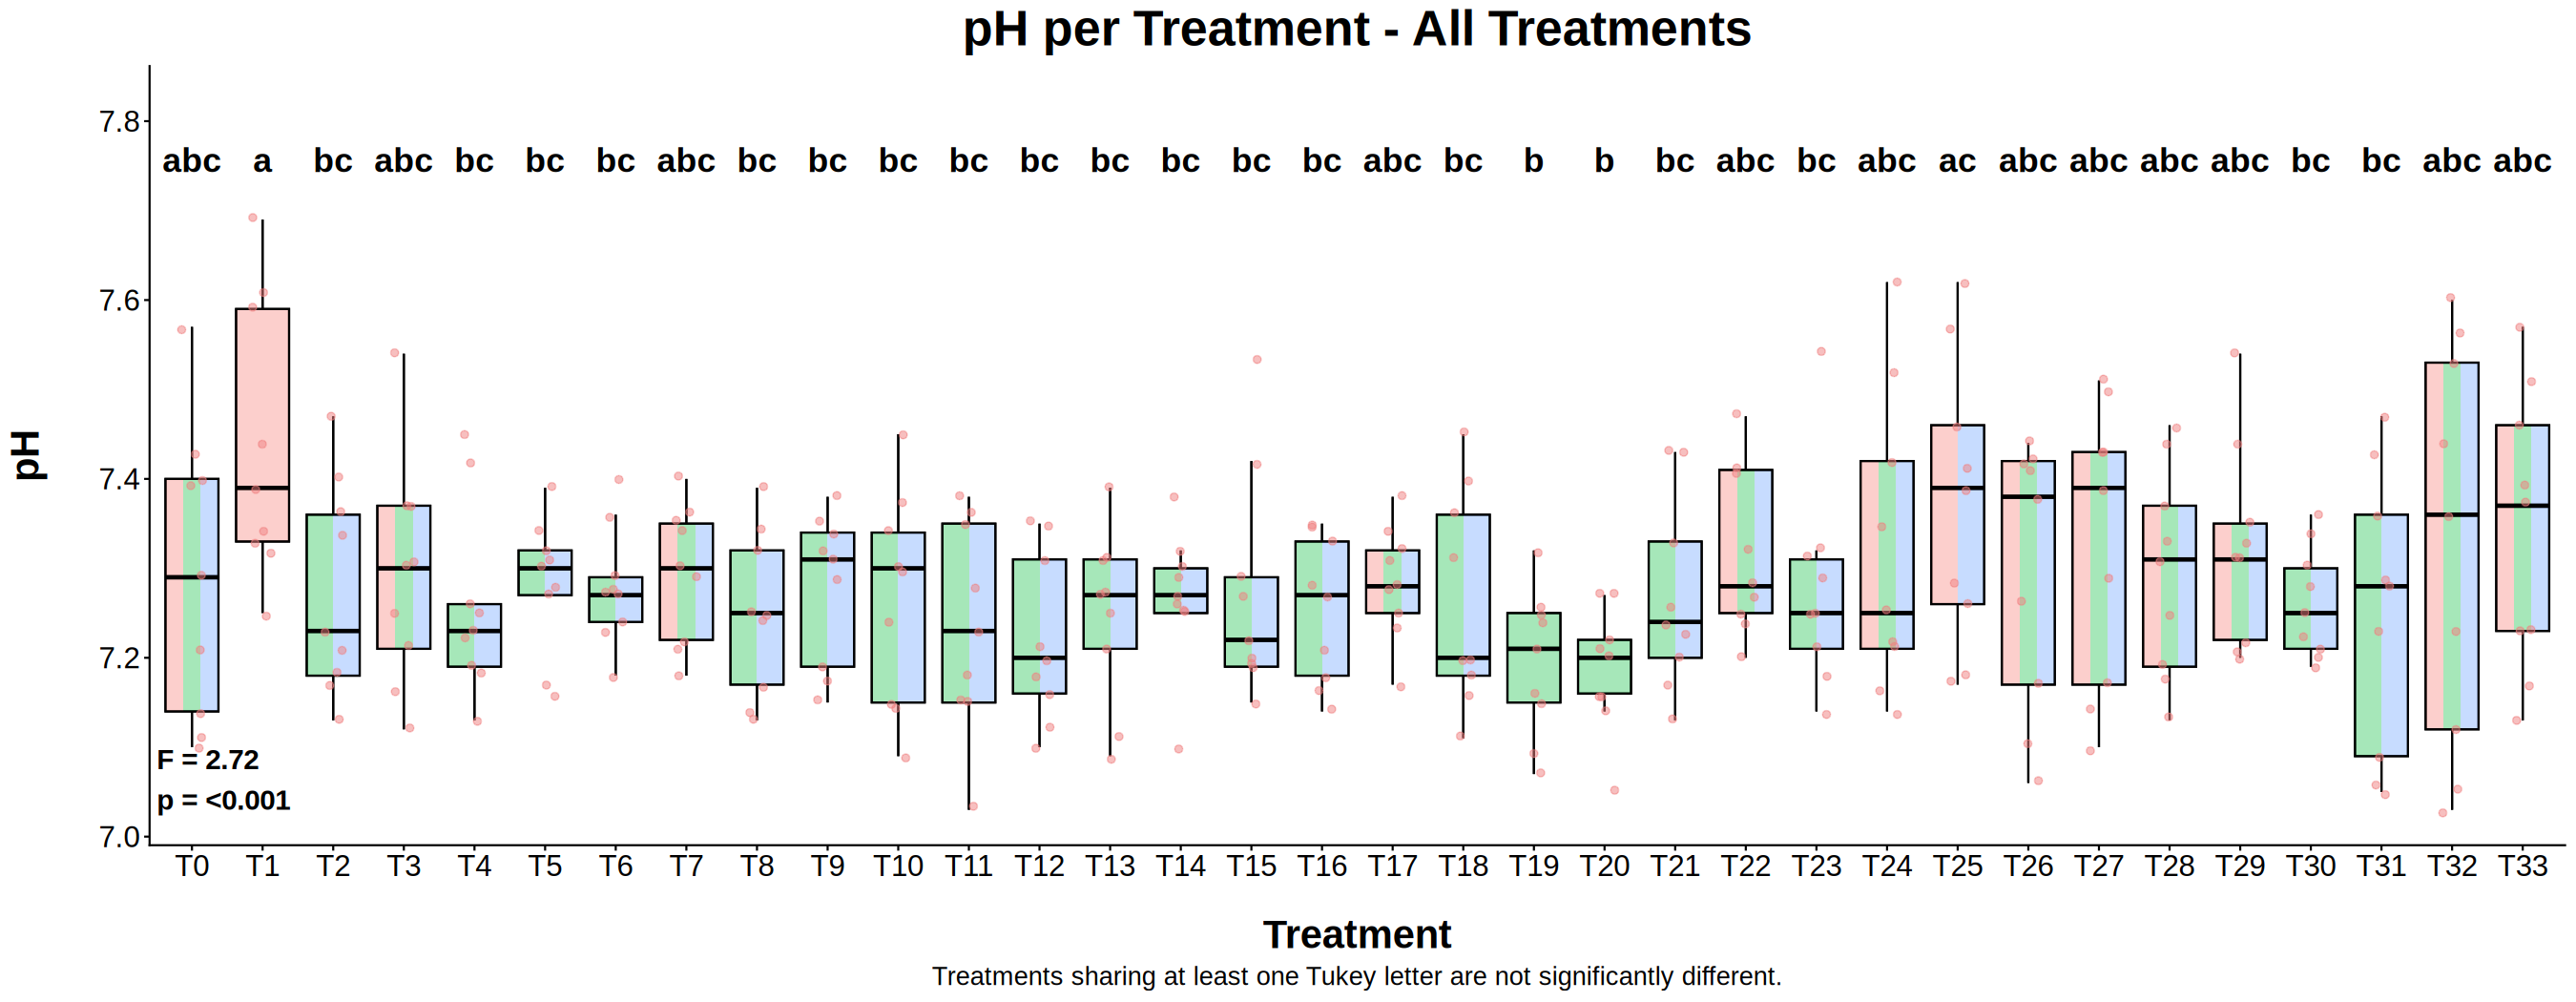

In [2326]:
result_all_pH <- plot_anova_treatment(
  data = df2,
  variable = "pH",
  title = "pH per Treatment - All Treatments",
  y_label = "pH"
)

## 8.5 Averages

In [2327]:
all_treatments <- df2 %>% group_by(Treatment) %>%
  summarise(
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
all_treatments

Treatment,TDDM_average,Methane_intensity_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T0,77.90,57.36,56.98,7.29
T1,60.53,47.00,97.86,7.44
T2,66.82,56.34,121.84,7.28
T3,64.78,56.66,288.49,7.29
T4,68.29,51.32,193.50,7.26
T5,67.10,55.33,106.86,7.28
T6,63.98,58.67,146.22,7.28
T7,64.22,57.77,130.52,7.29
T8,65.67,54.86,190.84,7.25


# 9.0 Scatterplots

### 9.0.1 Plot function

In [2328]:
plot_methane_tddm <- function(
  data,
  title = "Methane Intensity vs TDDM %"
) {
  options(repr.plot.width = 12, repr.plot.height = 12, repr.plot.res = 150)
  ggplot(data, aes(x = TDDM_average, y = Methane_intensity_average)) +

    geom_point(
      color = "red",
      size = 3
    ) +

    geom_text(
      aes(label = Treatment),
      vjust = -0.8,
      size = 5
    ) +

    labs(
      title = title,
      x = "TDDM %",
      y = "Methane Intensity"
    ) +

    theme_minimal() +



    theme(
      axis.title.x = element_text(
        size = 17,
        face = "bold"
      ),
      axis.title.y = element_text(
        size = 17,
        face = "bold"
      ),
      axis.text.x = element_text(
        size = 17
      ),
      axis.text.y = element_text(
        size = 17
      ),
      plot.title = element_text(
        size = 20,
        face = "bold",
        hjust = 0.5
      )
    )
}

## 9.1 Batch 1

In [2329]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"

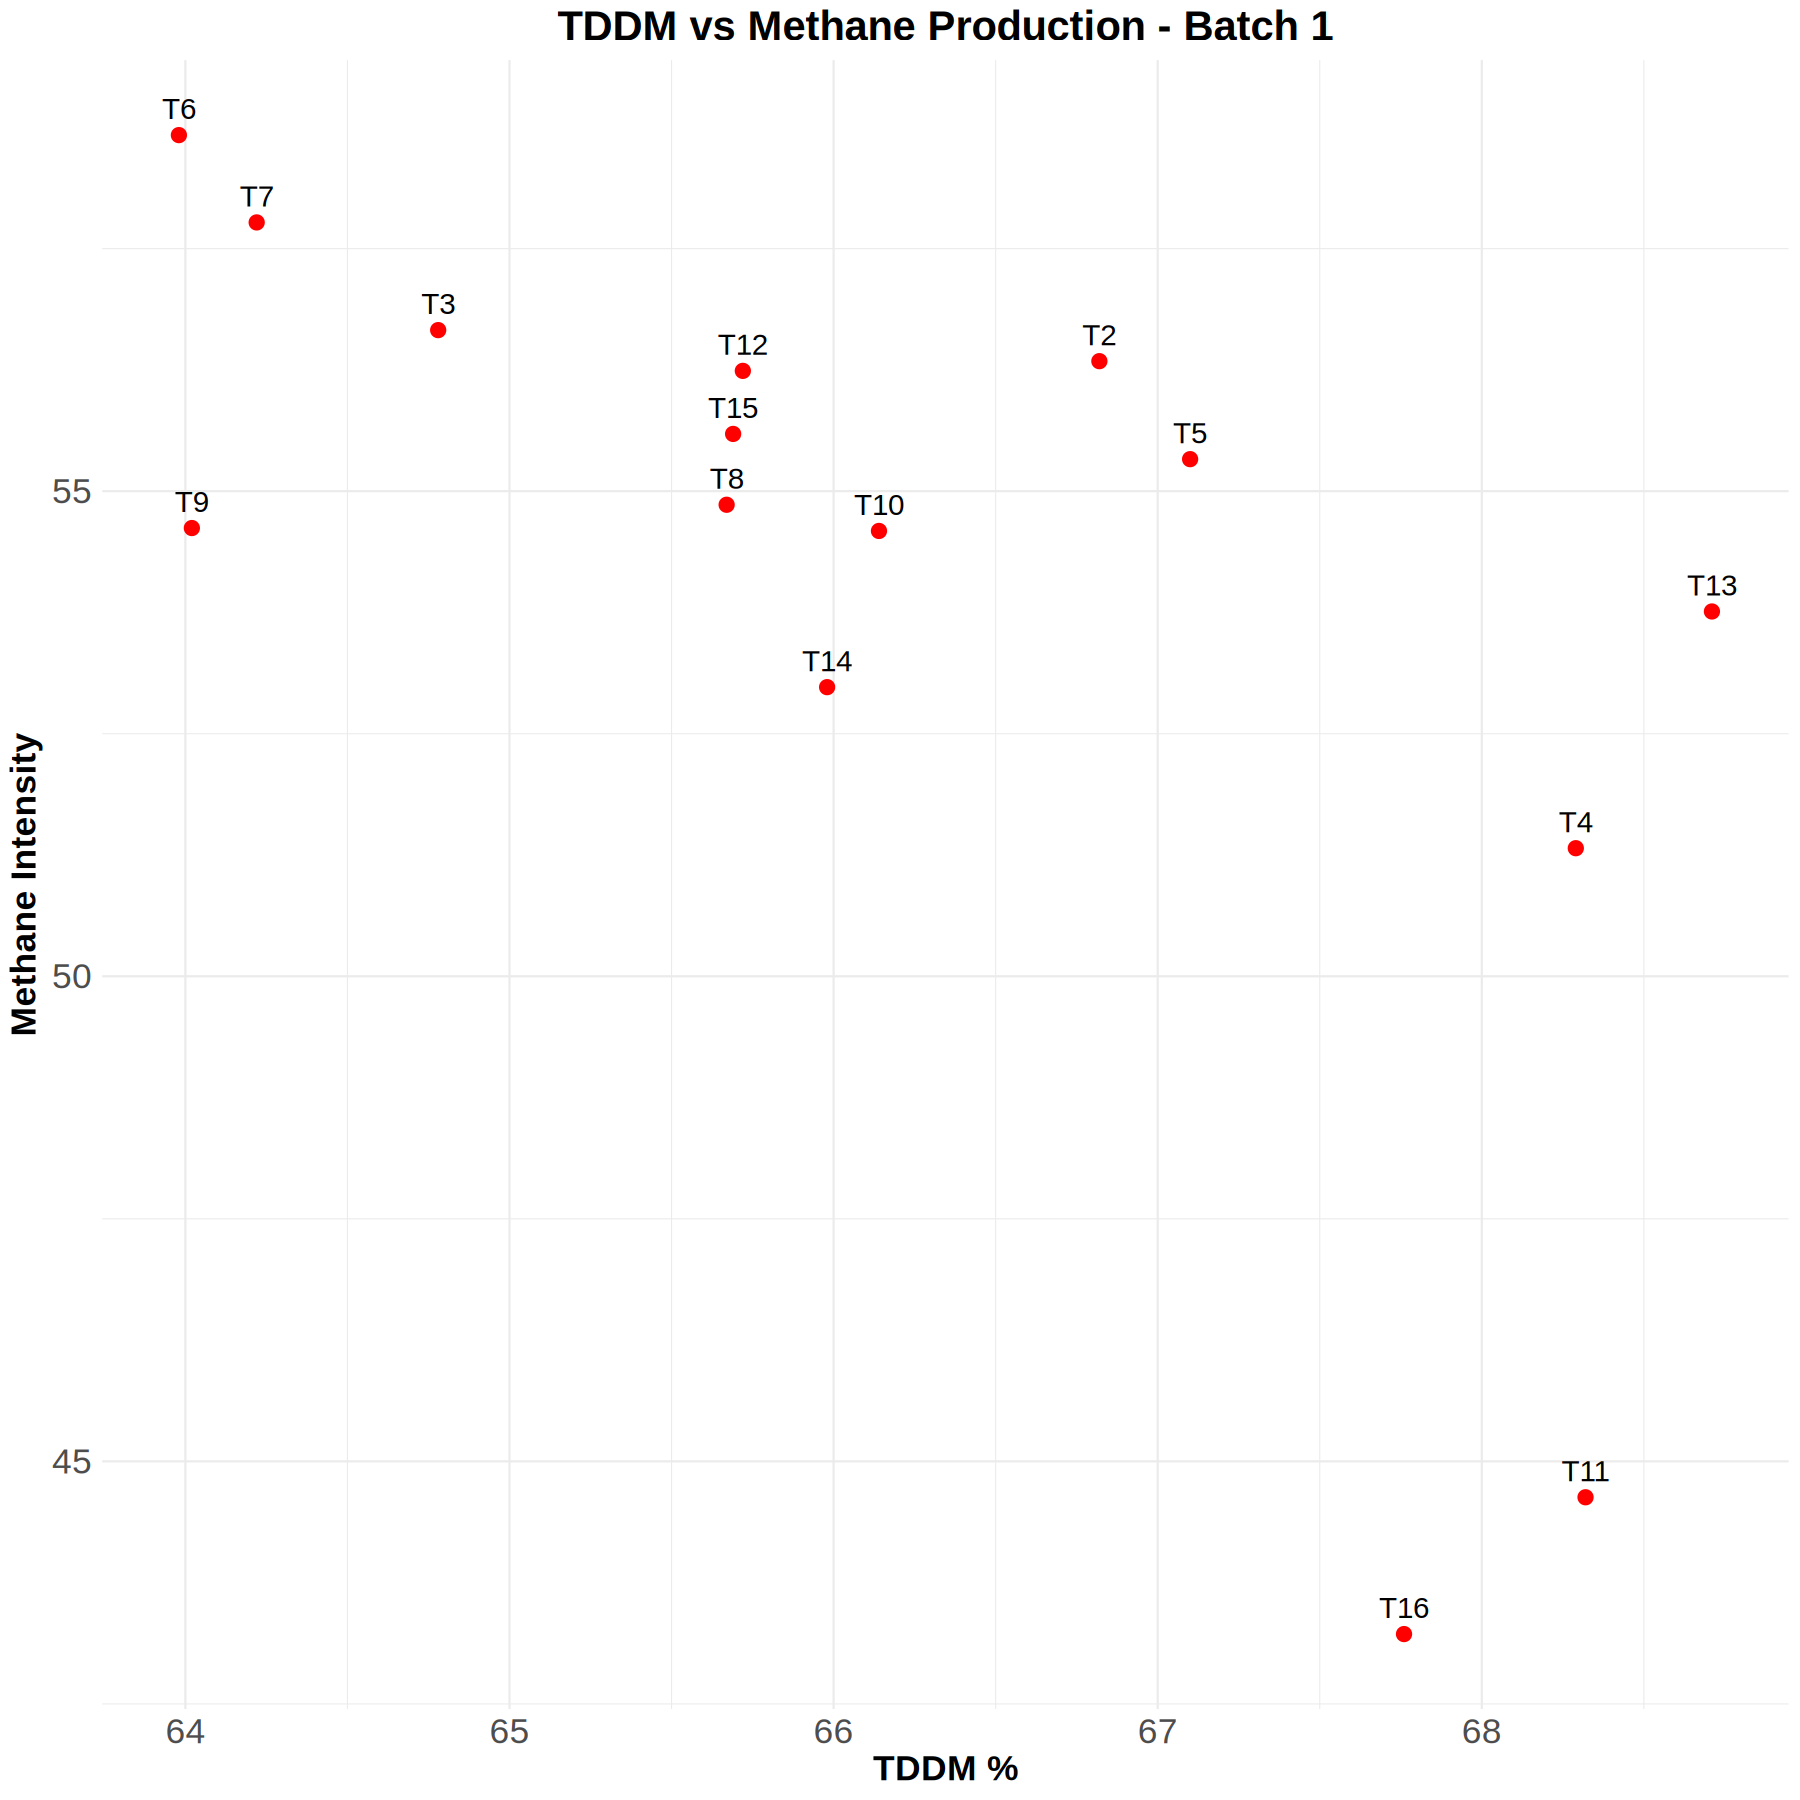

In [2330]:
plot_methane_tddm(batch_1_table, title = "TDDM vs Methane Production - Batch 1")

## 9.2 Batch 2

In [2331]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"

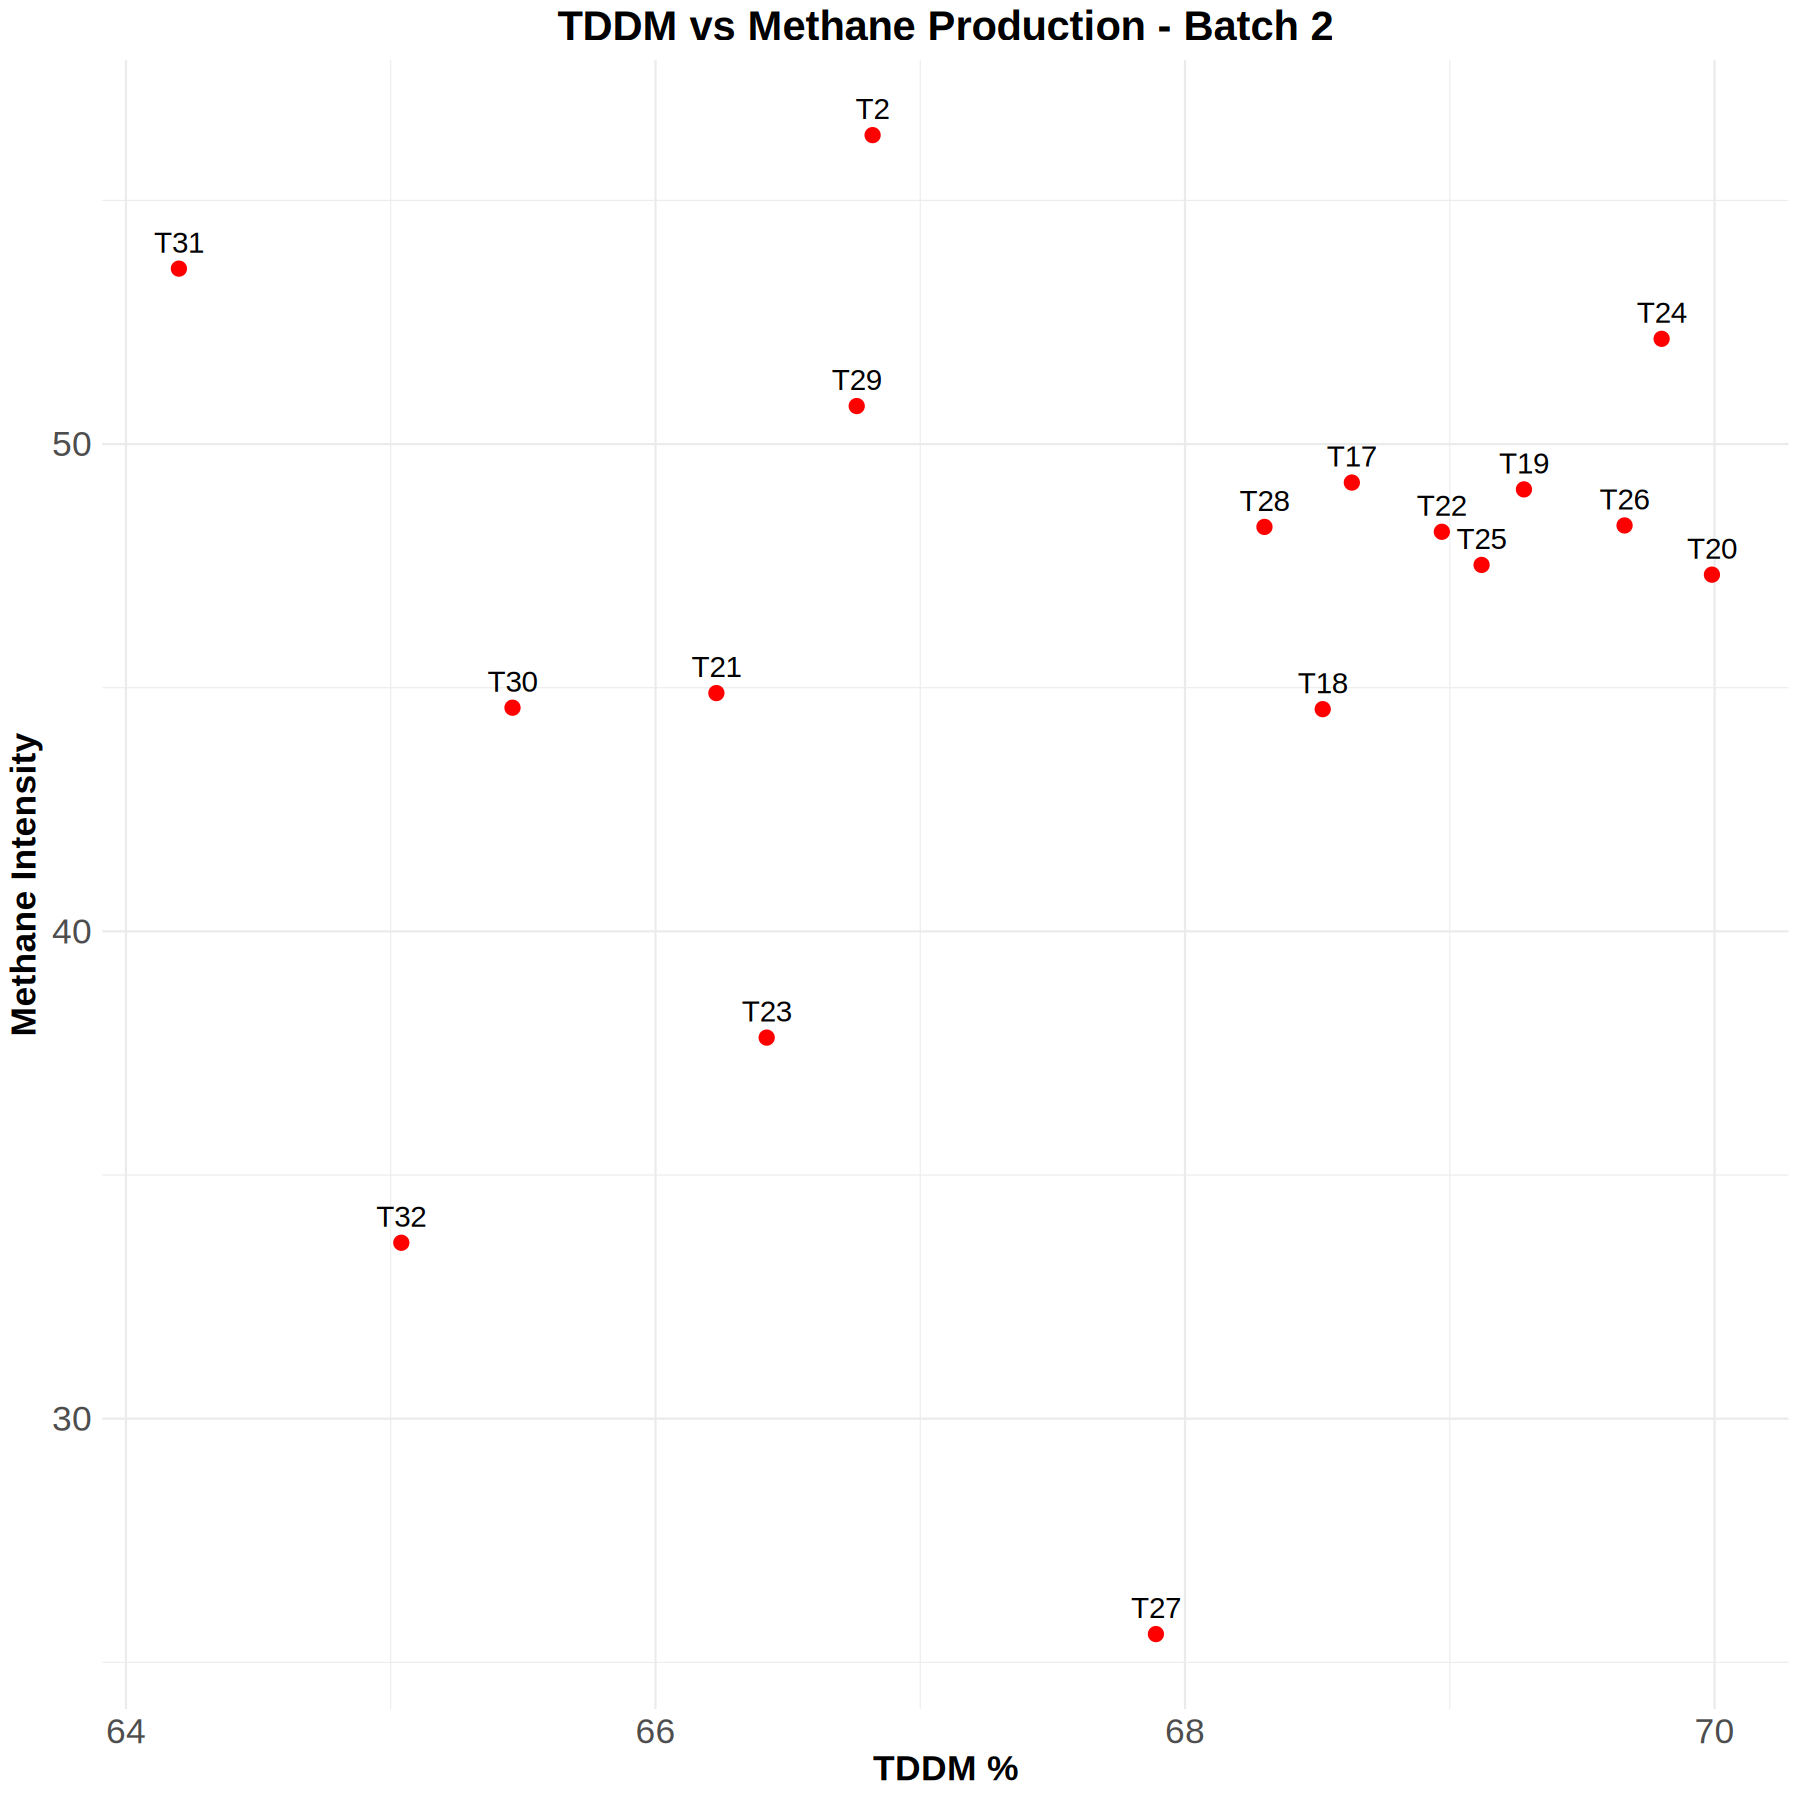

In [2332]:
plot_methane_tddm(batch_2_table, title = "TDDM vs Methane Production - Batch 2")

## 9.3 Batch 3

In [2333]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"

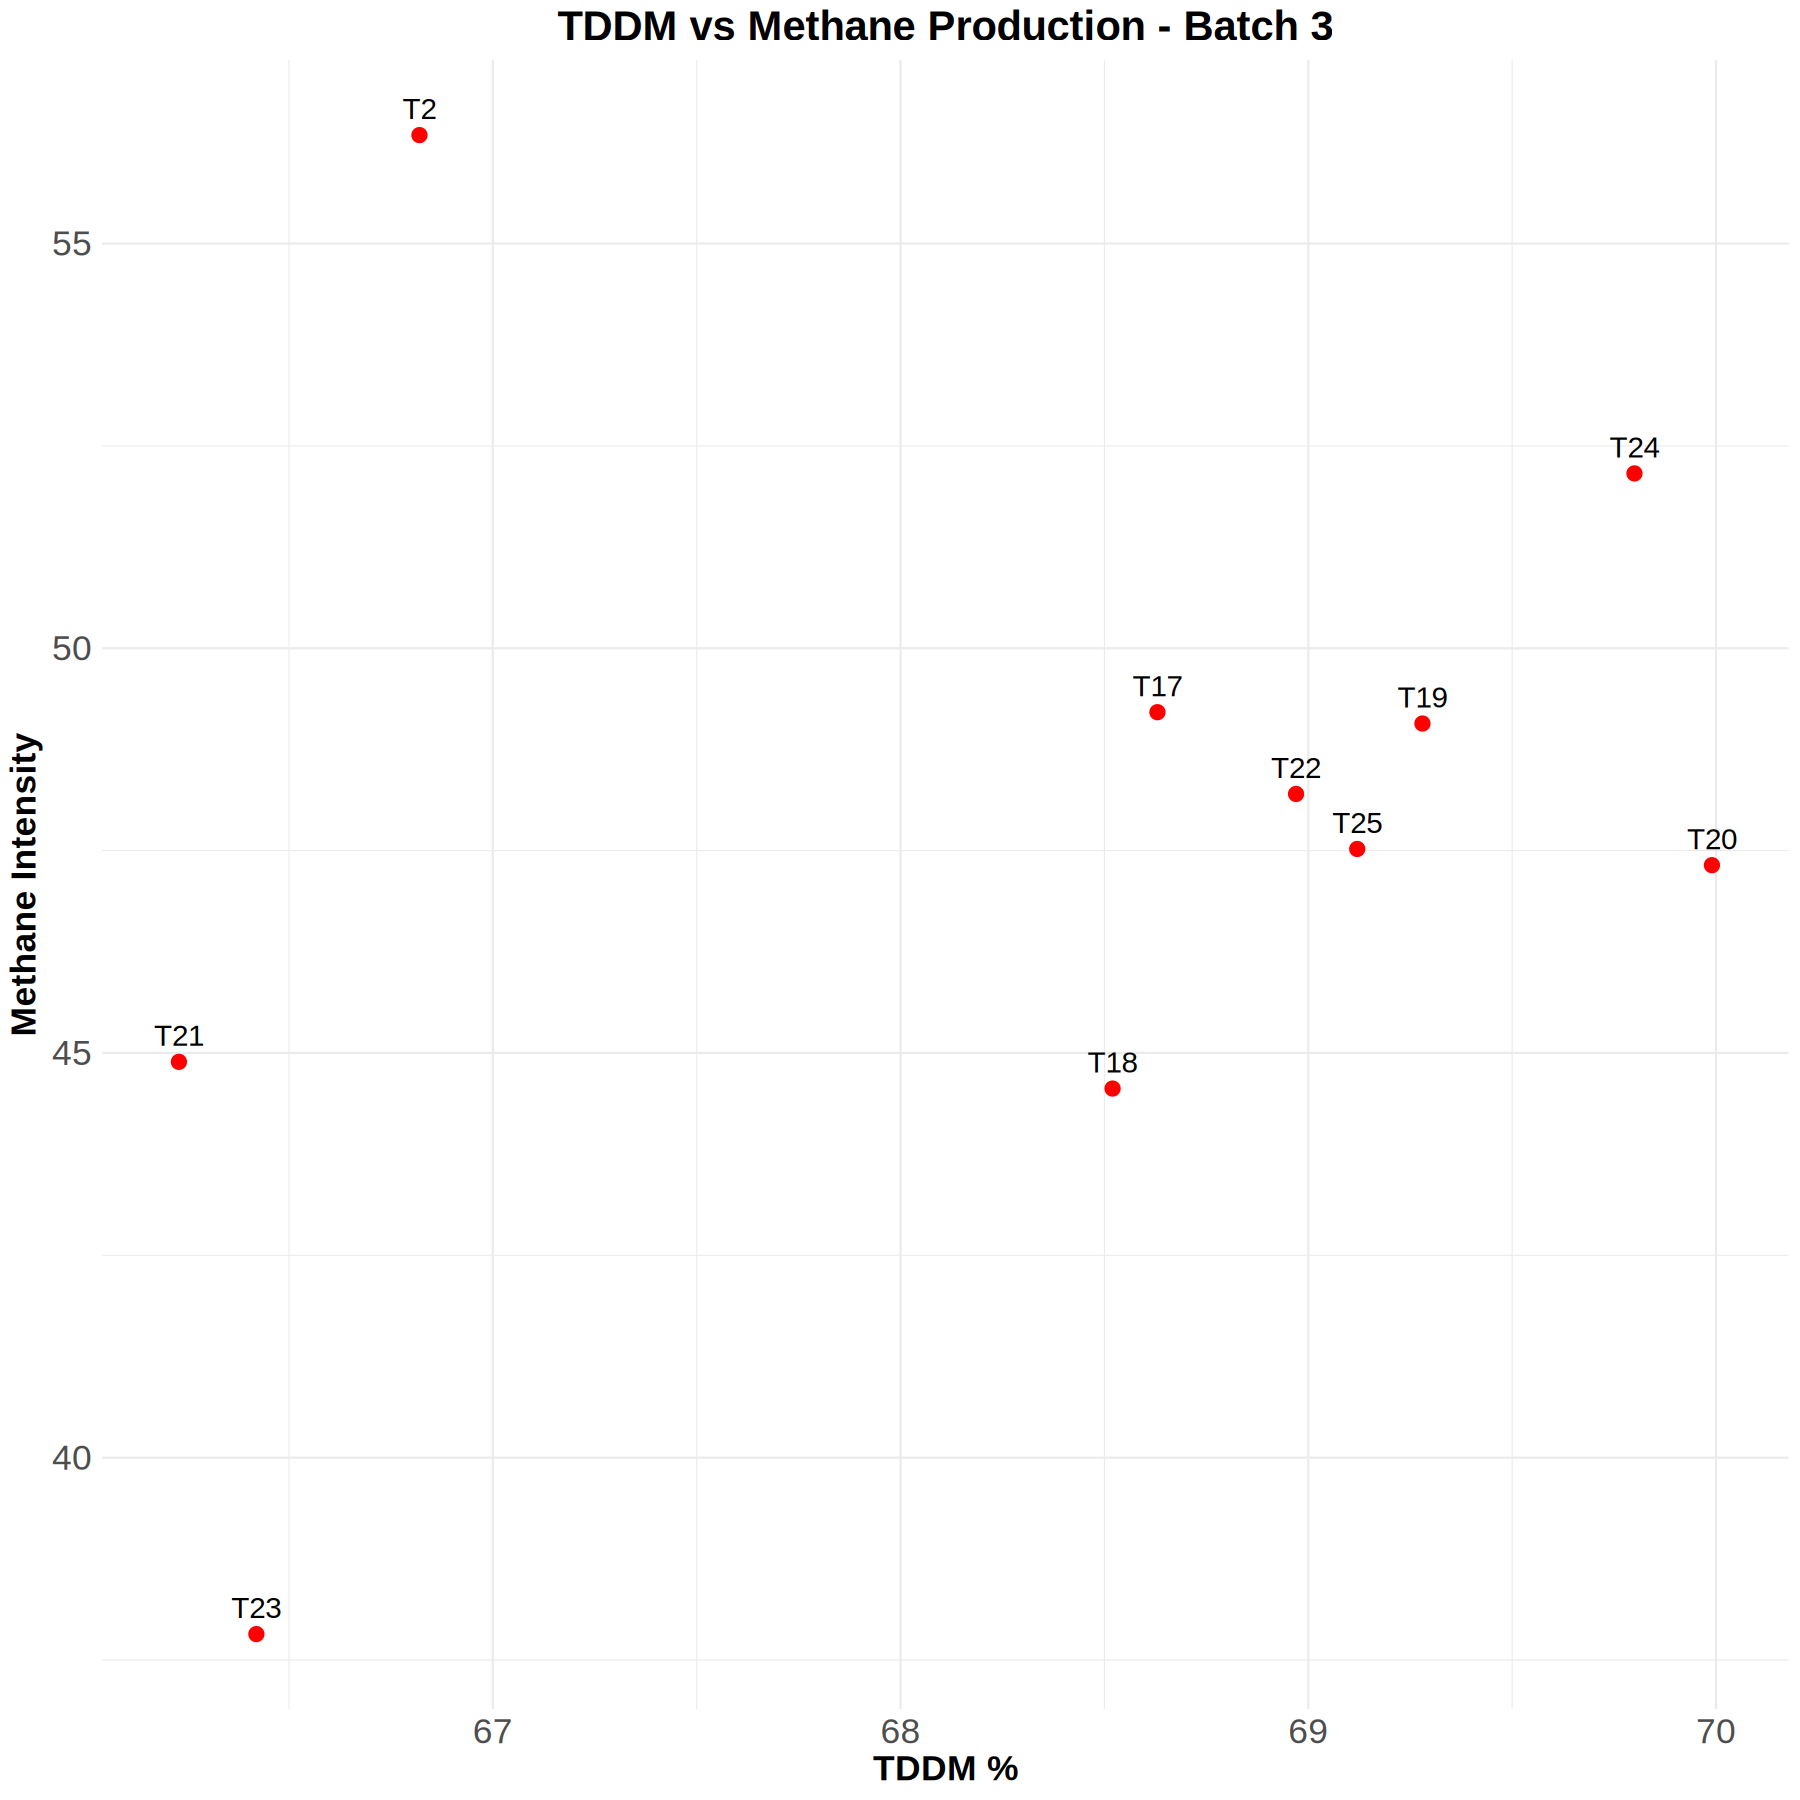

In [2334]:
plot_methane_tddm(batch_3_table, title = "TDDM vs Methane Production - Batch 3")

## 9.4 Batch 4

In [2335]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"

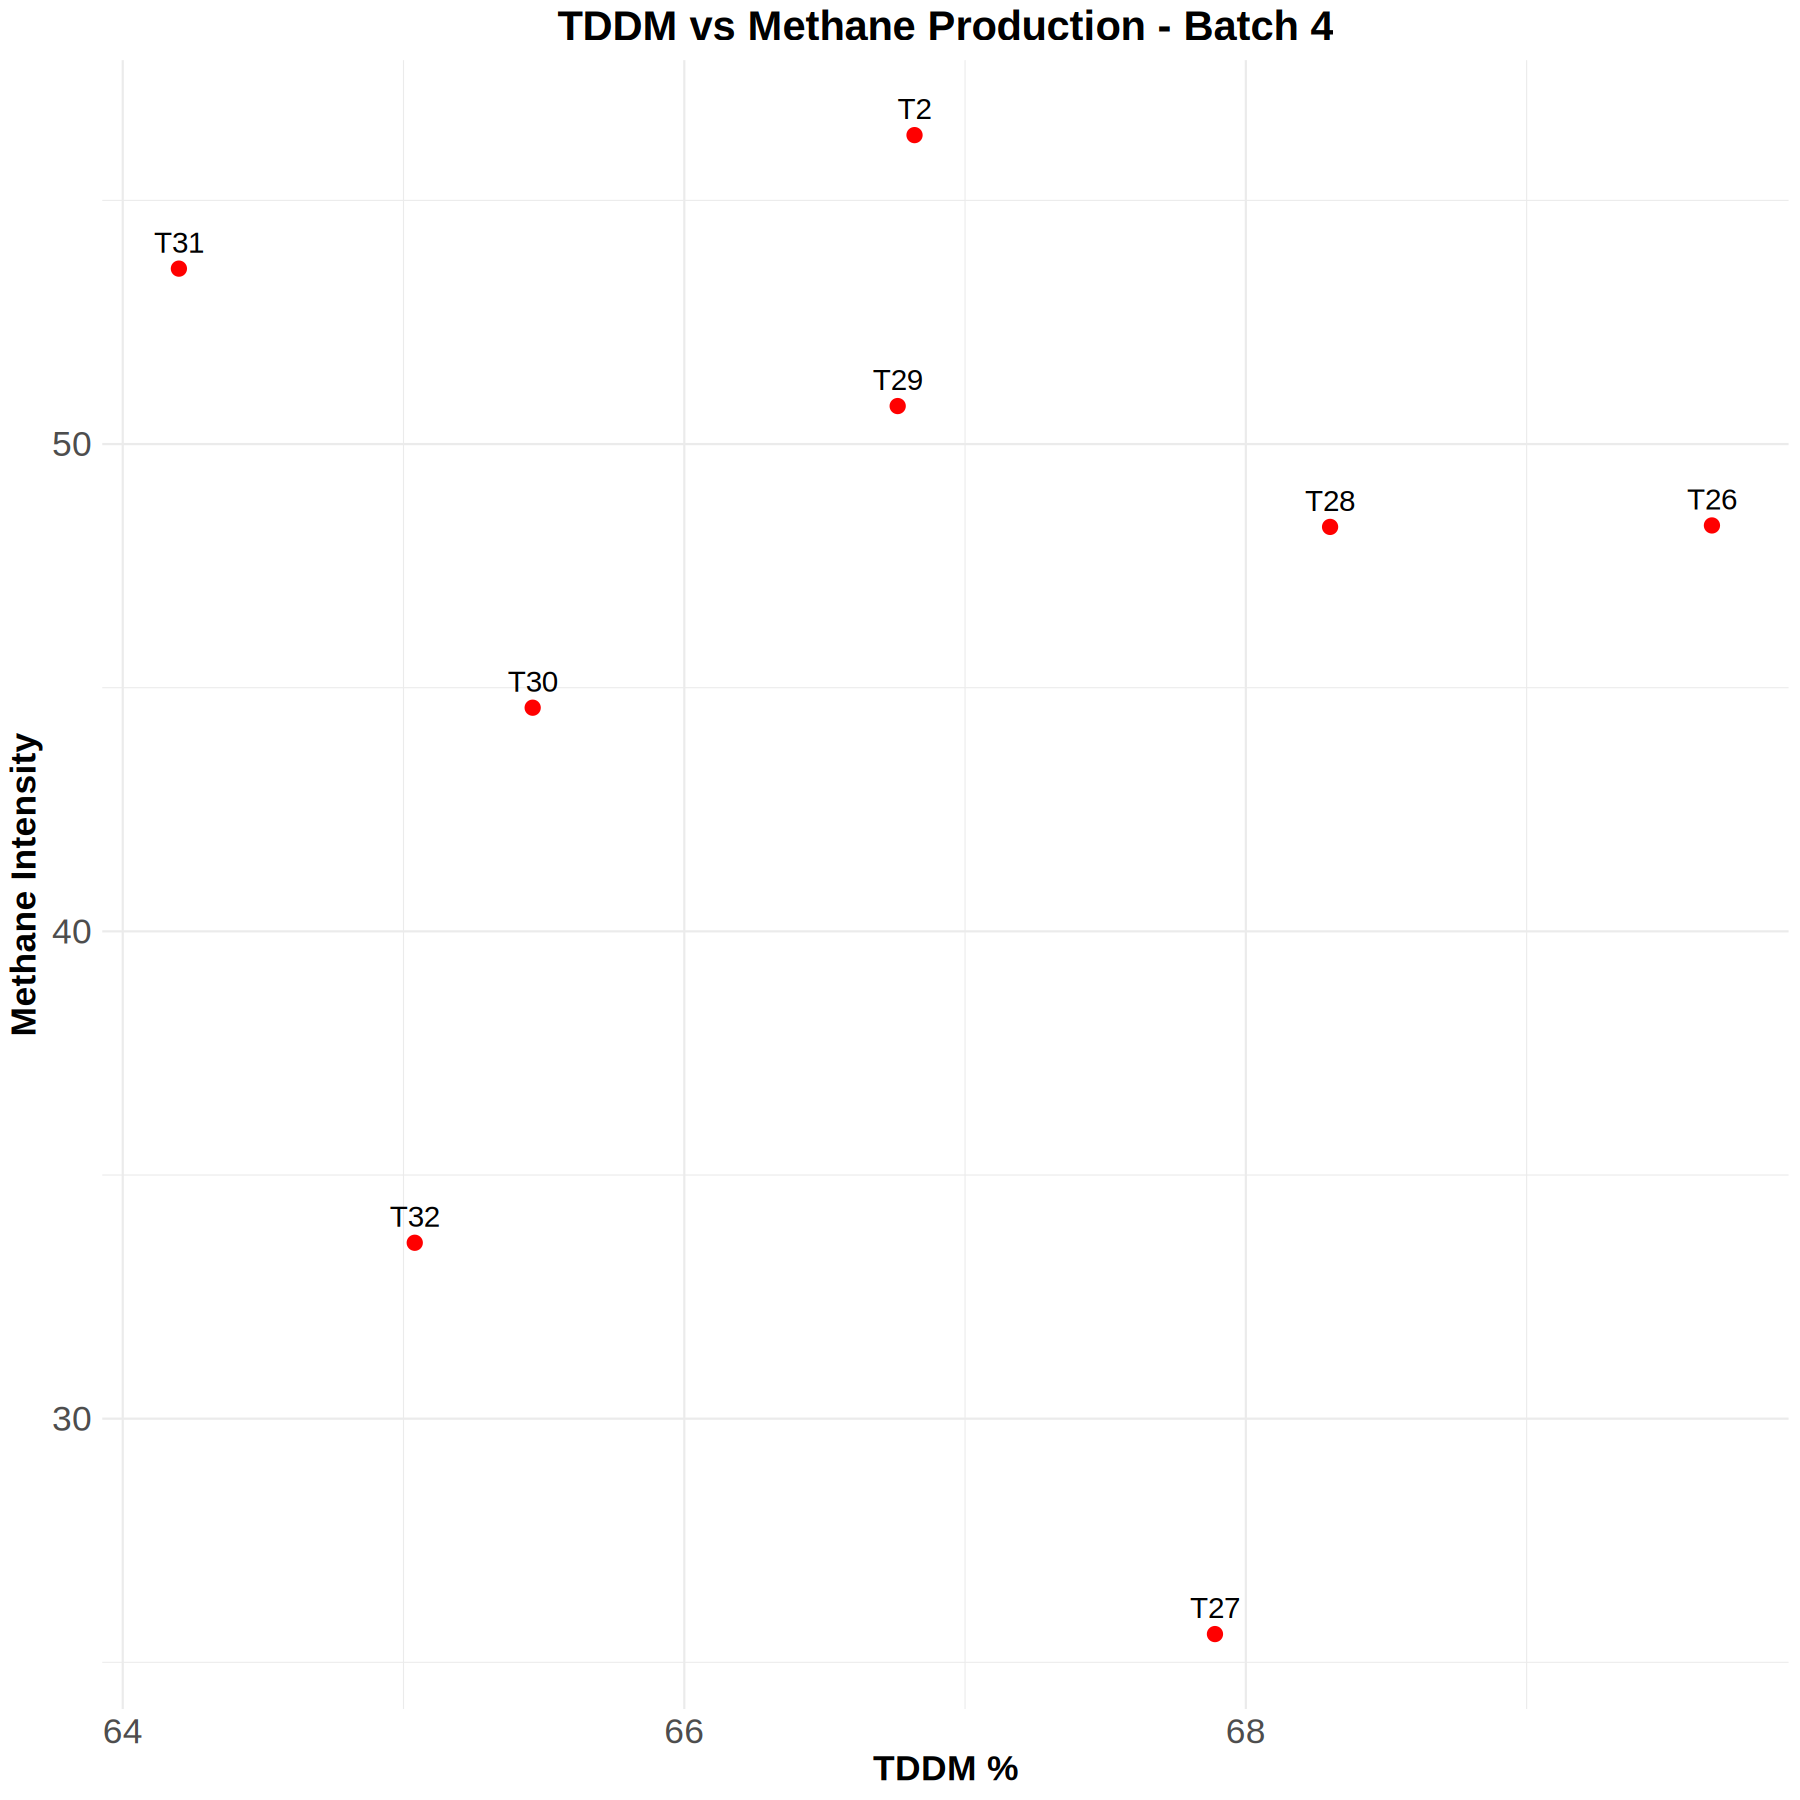

In [2336]:
plot_methane_tddm(batch_4_table, title = "TDDM vs Methane Production - Batch 4")

## 9.5 All treatments

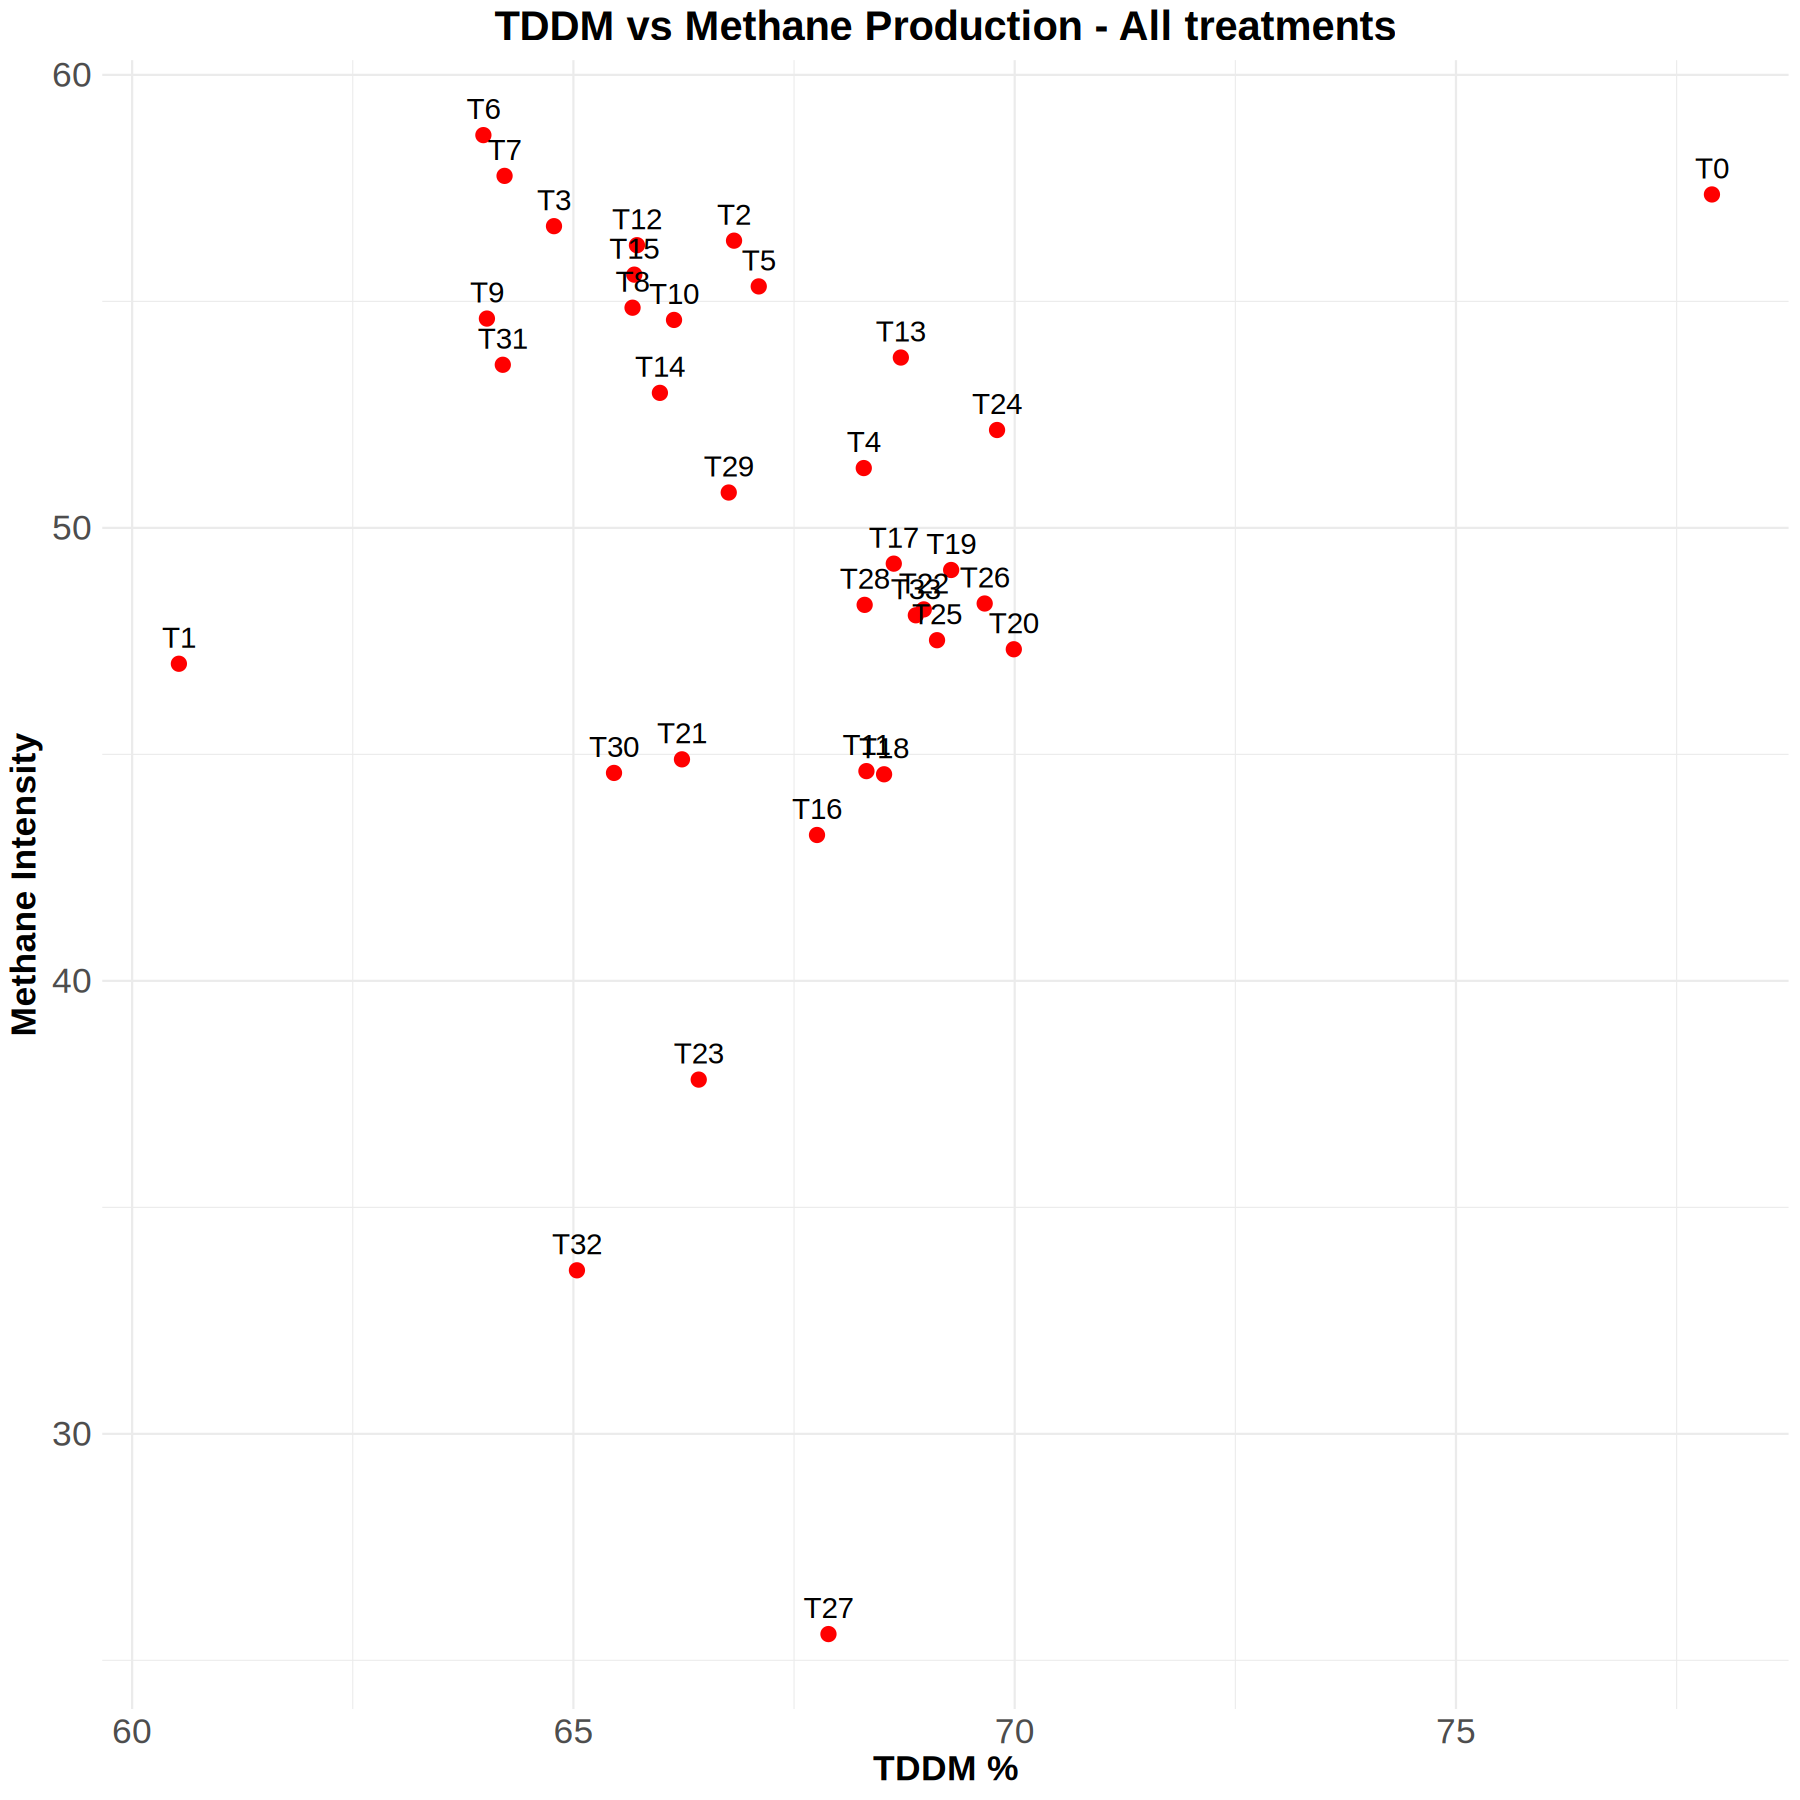

In [2337]:
plot_methane_tddm(all_treatments, title = "TDDM vs Methane Production - All treatments")